<font size="5">**Introduzione a Python per il Machine Learning (con *pandas*, *numpy* e *scikit-learn*)**</font><br>

> (c) 2025 Antonio Piemontese

Come prima cosa, **rileviamo l'ambiente di esecuzione del notebook** (Jupyter oppure Google Colab: la cella imposta una variabile booleana `IN_COLAB` che sarà testata da alcune celle del notebook (in particolare quelle di visualizzazione di immagini) per personalizzarne il comportamento a seconda dell'ambiente di esecuzione dell'ambiente rilevato.

In [1]:
# impostazione del TOGGLE BINARIO:
try:
    import google.colab                      # package disponibile SOLO in Google Colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("Siamo in Colab:", IN_COLAB)


# IMPORT dei package necessari per la VISUALIZZAZIONE delle IMMAGINI (necessari sia in JN che in Colab):
from IPython.display import Image, display   # import dei package di incorporamento e visualizzazione immagine (una tantum)
                                             # Image e display sono entrambi necessari a Jupyter Notebook
                                             # Google Colab utilizza solo Image
import os                                    # necessario a Google Colab per vedere da una cella codice
                                             # i contenuti del 'content'

Siamo in Colab: False


# Cosa è un *jupyter notebook*
Un *quaderno* con **codice** (celle) e **note** (scritte nel [linguaggio markdown](https://en.wikipedia.org/wiki/Markdown) che è [WYSIWYM](https://en.wikipedia.org/wiki/WYSIWYM) e non [WYSIWYG](https://en.wikipedia.org/wiki/WYSIWYG)).<br>
Le celle sono eseguibili anche **singolarmente** (ancorchè la memoria sia **condivisa**), spesso intervallate da celle di note di spiegazione ed approfondimento.<br>
Il suffisso è **.ipynb** (**I**nteractive **PY**thon **N**oteBook), **non .py** (il codice python classico). Jupyter Notebook (*ipynb*) è **un formato generale**, utilizzato da molti ambienti di sviluppo (vedi più avanti)<br>
I jupyter notebook sono gestiti dalle **notebook interface** - ad esempio Jupyter Notebook, Google Colab, Jupyter Lab, R Markdown, Visual Studio Code, ecc - che NON sono [IDE](https://it.wikipedia.org/wiki/Ambiente_di_sviluppo_integrato) come spyder o pycharm (per Python).<br>
Le celle di codice eseguibili individualmente, intervallate da celle di testo, sono molto **utili per la didattica**, perché suddividono il programma in blocchi.<br>
I principali notebook (Jupyter e Google Colab) funzionano con **3 linguaggi**: Python, R e Julia.

Il concetto di "notebook" è generale - ad esempio anche il linguaggio R ha i suoi notebook, detti 'R Markdown'. Si veda [qui](https://www.databricks.com/it/glossary/jupyter-notebook) per una descrizione terza dei notebook Jupyter. Vedi qui sotto per una valutazione di chatGPT:


**Markdown vs LaTeX**<br>
La differenza principale sta nell’approccio e nell’obiettivo. Markdown è un **linguaggio di formattazione leggero**, pensato per essere semplice, intuitivo e facilmente leggibile anche in formato testo. È ideale per **documentazione online**, note o semplici articoli. LaTeX, invece, è un sistema di composizione tipografica **molto più potente e complesso**, progettato per la creazione di documenti scientifici, tesi, articoli accademici o libri, offrendo un **controllo molto fine sulla tipografia e la struttura**.

NB. Se, in una cella testo (cioè, markdown) di un jupyter notebook si vuole scrivere una **formula matematica** si può usare la **sintassi LaTeX (molto potente) tramite $$**. In questo caso Markdown rimane il linguaggio di base, ma la formula è resa grazie all’uso di LaTeX (Markdown infatti non gestisce direttamente le formule).


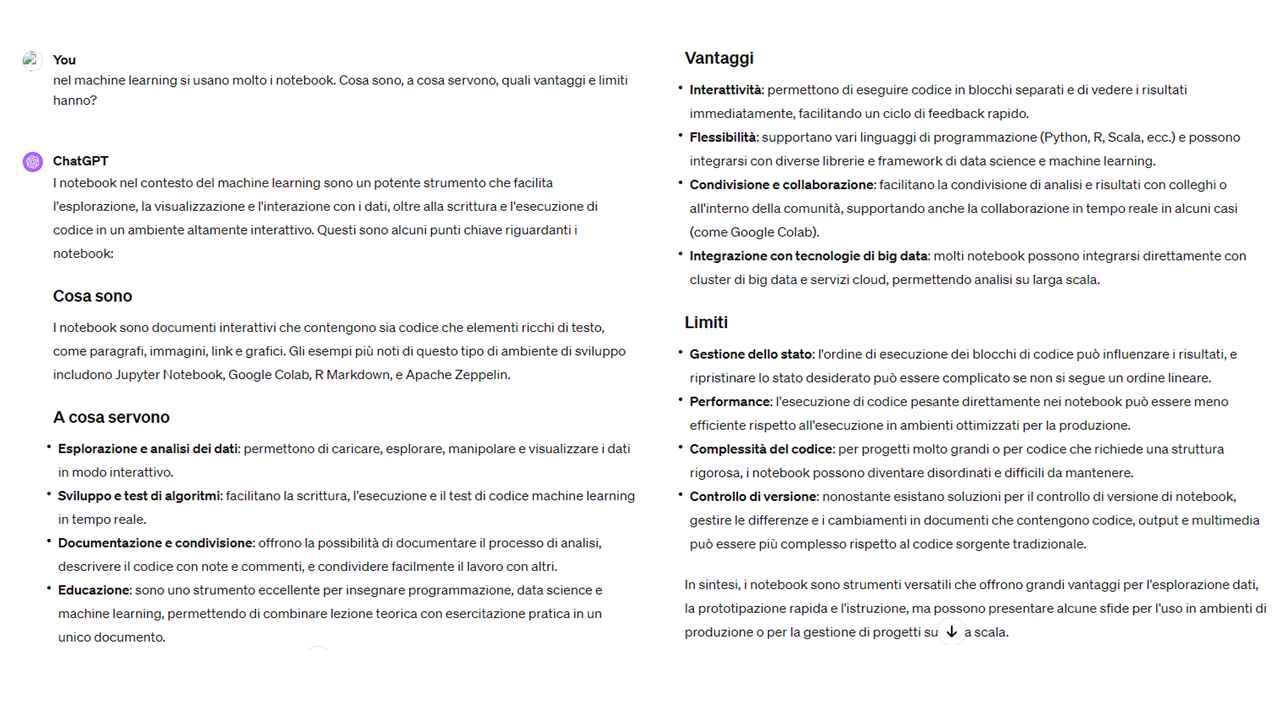

In [ ]:
# if one-line, cioè la normale IF che richiede diverse righe è qui compattata in una riga sola.
# il codice associato al ramo if vero è riportato ad inizio riga (un aspetto particolare che può confondere)
Image('/content/notebook_definition_chatGPT.png') if IN_COLAB else display(Image(filename='notebook_definition_chatGPT.png'))

# Ambienti di sviluppo ed esecuzione di notebook Python

Come detto prima, un "notebook Jupyter" è solo **un formato di file standard (`.ipynb`)**, che può essere <u>editato in diversi ambienti di sviluppo software</u>:
* Anaconda / Jupyter Notebook o Jupyter Lab
* Visual Studio Code (VSC) o Cursor (un fork di VSC)
* Google Colab (in questo caso è eseguito sulla VM di Google)
* altri

Per un ottimo esame di questi ambienti vedi [qui](https://github.com/rasbt/LLMs-from-scratch/tree/main/setup) (e poi scrolla in giù).

## Installazione di Anaconda

Scaricare *l'installer* di **Anaconda Individual Edition** adatta alla propria macchina (32 o 64 bit).<br>
Installare Anaconda in una directory il cui path non contenga spazi o caratteri unicode.<br>
Avviare Anaconda/Jupyter con **Anaconda Navigator** oppure l'**Anaconda Prompt**, entrambi disponibili dal menù.<br>
[In Windows, non confondere l'Anaconda Prompt con il terminale di sistema del DOS. Il primo riconosce le variabili di ambiente di Windows, e quindi anche i *path*; il secondo, no, perchè appunto è a livello DOS, sottostante a Windows]

> E' possibile avviare i vari terminali anche da Anaconda *Environments* -- icona play di *base (root)*, in questo modo:
![](terminali_anaconda.png)
>
Per Windows, vedi [qui](https://docs.anaconda.com/anaconda/install/windows/).<br>
Per Mac, vedi [qui](https://docs.anaconda.com/anaconda/install/mac-os/).<br>

**Troubleshooting**: se al lancio Anaconda Navigator non parte vedi questi utili video (a me ha funzionato il metodo 3 del terzo video):<br>
[Why Anaconda Navigator is not opening in PC ? Python | Anaconda |](https://www.youtube.com/watch?v=mrBB5UZIT9g)<br>
[Fixing the Anaconda Doesn't Launch Problem](https://www.youtube.com/watch?v=dVgI8Wk9Jqs)<br>
[How to Fix Anaconda Navigator Not Opening - Solve Anaconda Navigator Not Launching or Working](https://www.youtube.com/watch?v=ZI6tDpWvO1o)<br>

[Questa](https://docs.anaconda.com/free/troubleshooting/) è la pagina ufficiale di Anaconda per il troubleshooting.<br>
[Questo](https://stackoverflow.com/questions/46335789/anaconda-navigator-wont-launch-windows-10) è un post *stackoverflow* con molti suggerimenti.<br>
[Questa](https://docs.anaconda.com/free/navigator/getting-started/) è la pagina ufficiale di Anaconda per il lancio di Anaconda Navigator.

**Eliminare la directory `.anaconda`**, in genere sotto `C:\%userprofile%`dedicata ad uso esclusivo di Anaconda Navigator.

## De-installazione e re-installazione di Anaconda

**Può capitare di dover disinstallare e reinstallare Anaconda**. Ecco i motivi più comuni, spiegati in modo pratico:

**🔧 1. Installazione corrotta**<br>
Quando succede:
- Interruzione durante l’installazione (es. crash, mancanza di spazio)
- Aggiornamenti di sistema che mandano in tilt i percorsi

Sintomi:
- Jupyter Notebook non si apre
- L’Anaconda Prompt dà errori strani
- Alcuni pacchetti risultano installati ma non funzionano

**♻️ 2. Troppi ambienti, troppa confusione**<br>
Quando succede:
- Hai creato decine di ambienti virtuali (magari duplicati)
- Non sai più dove sono i pacchetti né quale ambiente è attivo

Soluzione rapida:
- Un bel reset, reinstalli tutto da zero e riparti pulito.

**🚫 3. Conflitti tra pacchetti**<br>
Quando succede:
- Usi pip dentro conda, oppure installi versioni incompatibili
- Si verificano errori tipo PackageNotInstalledError o DLL load failed

Tipico scenario:<br>
`conda install tensorflow`<br>
`pip install keras==2.4`

Boom 💥! E le cose non funzionano più.

**🧪 4. Cambio di versione**<br>
Quando succede:
- Vuoi passare a una versione specifica di Anaconda (es. 2023.09) per compatibilità con un progetto
- Oppure preferisci una versione più leggera, tipo Miniconda

**💣 5. Problemi con R, Jupyter o estensioni**<br>
Quando succede:
- Anaconda installa ambienti legati a R (es. r-miniconda) anche se non ti servono
- Jupyter Lab/Notebook non mostra le estensioni, o non trovi più il “Variable Inspector”

**<u>🧼 Come fare una reinstallazione pulita?</u>**
- Disinstalla Anaconda da “Aggiungi/Rimuovi Programmi”
- Elimina manualmente le cartelle:
    * C:\Users\<NomeUtente>\anaconda3
    * C:\Users\<NomeUtente>\.anaconda
    * C:\Users\<NomeUtente>\.conda
    * (facoltativo) C:\Users\<NomeUtente>\.condarc e AppData\Local\Continuum
- Riavvia il PC
- Scarica e reinstalla Anaconda dal sito ufficiale

## La versione di Jupyter Notebook
L'installazione di Anaconda rende disponibile la **versione 7** di Jupyter Notebook, che può essere de-installata tramite la rotella in alto a destra del riquadro di Jupyter Notebook nell'Anaconda Navigator (per installarne un'altra).

La versione 7 di Jupyter Notebook ha introdotto diversi **cambiamenti strutturali e tecnologici**:
- Jupyter Notebook 7 è una **completa riscrittura** che usa lo <u>stesso frontend di JupyterLab</u>
- Jupyter 6 carica l'intero notebook .ipynb in blocco e costruisce il DOM per ogni cella subito. Jupyter 7 invece ha un approccio **più incrementale** e intelligente: visualizza prima l’interfaccia e poi costruisce le celle man mano.
- Jupyter 7 gestisce meglio anche i notebook con **molti output o grandi oggetti salvati nelle celle (Out[n])**.
- Jupyter 7 gestisce meglio **i plugin** (tipo `itables`, `ipywidgets`, `matplotlib interactive`), perchè li carica in modo più efficiente grazie al nuovo sistema di estensioni “federate” (stile JupyterLab).

Le estensioni di Jupyter Notebook 6 non sono più disponibili, ma le tre principali (TOC, Variable Inspector e Execute Time) sono disponili così:
- TOC è ora nel menù `View`
- il comando magic **`%whos`** mostra nome, tipo, valore e dimensione delle variabili
- `conda install jupyterlab_execute_time` --> riavvio di Jupyter Notebook (ora è attivo per ogni cella)


## Alternative ad Anaconda
Sebbene Anaconda sia la piattaforma consigliata per lo sviluppo in Python (ad esempio perchè ha molti package pre-installati), essa tuttavia richiede circa 5GB di disco e diversi minuti di tempo.<br>

### Jupyter Notebook standalone

In alternativa ad Anaconda, che include molte IDE tra cui anche Jupyter Notebook, potete scaricare **Jupyter Notebook** STAND-ALONE da [questo indirizzo](https://jupyter.org/). Scaricate *Jupyter Notebook* e NON *JupyterLab*, un prodotto più avanzato ma anche meno facile da usare (vedi più avanti). Consigliabile la versione **6.5.4** di Jupyter Notebook (anzichè l'ultima e cioè la 7), che potete installare da [qui](https://jupyter.org/install) sostituendo al comando *pip install notebook* (riportato nel sito), che appunto installa l'ultima versione, il comando *pip install notebook==6.5.4*.<br>

La *Table of Contents* è disponibile anche nella versione 7 di Jupyter Notebook dal menù `View`.

### Visual Studio code (VSC)

Se NON avete la possibilità di installare software ed ambienti di svilupppo in locale (cioè sul vostro PC), potete usare altre [IDE](https://it.wikipedia.org/wiki/Ambiente_di_sviluppo_integrato) già disponibili sul PC, ad esempio [VS code](https://code.visualstudio.com/).<br>

VS Code è **complementare** più che alternativo a Jupyter Notebook. Infatti:
- si usa in progetti complessi di produzione (JN si usa per notebook didattici o esemplificativi)
- permette di lavorare su parecchi file insieme (JN si usa in genere su un singolo notebook)
- ha funzioni di debugging e test (JN ha poche funzioni di debug)
- è una **IDE completa**, con terminale, browser interattivo, ecc (JN serve a commentare ed eseguire un notebook)

VSC offre funzioni in più ed in meno (rispetto a Jupyter); a novembre 2025:
- `IFrame` non legge i file PDF
- la search legge le celle markdown renderizzate e non WYSIWYM (ad esempio NON trova `.png`) 

Qui sotto il **workflow** di VSC con file in formato **jupyter notebook** (*ipynb*):<br>
![](architettura_jupyter_notebooks.png)

### Google Colab

Un'ottima soluzione, la migliore secondo me quando non è possibile fare installazioni locali, è usare [Google Colab](https://colab.research.google.com/?hl=it) che offre un ambiente "notebook" (cioè con celle di codice e celle markdown, con testo, immagini, audio, video, PDF, url, ecc) **sul cloud**.

Con **Google Colab** potete <u>aprire direttamente</u> i notebook *.ipynb* ed eseguire le varie celle di codice in cloud, cioè usando le risorse hardware su cloud messe a disposizione da Google. Essendo una url **non** richiede download ed installazioni di software.<br>
Inoltre, Google Colab permette di eseguire il codice anche su GPU in cloud, se non ne avete una in locale, gratuitamente fino a 12 ore.<br>
L'unico **requisito** per usare Google Colab è la disponibilità di un **account Google**.

> Per maggiori dettagli su Google Colab e per un confronto con Jupyter Notebook si veda il notebook ***Google Colab - Introduzione***.

### Jupyter Notebook nel cloud
Oltre a Google Colab, esistono altri strumenti per eseguire notebook Jupyter sul cloud. Ecco una [lista](https://www.linkedin.com/pulse/8-easy-ways-run-your-jupyter-notebook-cloud-2023-update-metti/).<br>
Da inizio 2023 è disponibile anche [il cloud Anaconda](https://www.anaconda.com/blog/code-in-the-cloud-with-anaconda-for-free).

### Jupyter Lab
Jupyter Lab è un ambiente di sviluppo (IDE) più avanzato di Jupyter Notebook, che è tuttavia più semplice da usare, e dunque consigliabile.<br>
Vedi [questo confronto](https://stackoverflow.com/questions/50982686/what-is-the-difference-between-jupyter-notebook-and-jupyterlab).

### Anaconda vs Miniconda vs conda
Allargando il discorso dalle IDE / notebook interface alle **distribuzioni**, ne sono disponibili diverse (oltre ad Anaconda):
![](anaconda_miniconda_conda.png)
https://www.dataschool.io/conda-vs-anaconda-vs-miniconda/

# I principali package python per la Data Science

**GESTIONE DATI**:<br>
- **numpy** (np): abbreviazione di *NUMerical PYthon*, libreria per il calcolo numerico e scientifico; contiene molte funzioni matematiche di alto livello per l'algebra lineare (ad es. prodotti scalari tra vettore e matrice); contiene un generatore di numeri pseudo-casuali; permette di creare array multi-dimensionali con operazioni vettorizzate; nato nel 2006 dall'unione di due precedenti package numerici; si appoggia a veloci librerie C e Fortran ([BLAS](https://en.wikipedia.org/wiki/Basic_Linear_Algebra_Subprograms) e [LAPACK](https://en.wikipedia.org/wiki/LAPACK)); è considerato la versione Python di Matlab;
- **scipy** (sp): abbreviazione di *SCIentific PYthon*, libreria che estende numpy con 60+ funzioni statistiche e matematiche; permette la gestione di matrici sparse;
- **pandas** (pd): libreria per importare, gestire e manipolare i [**data frame**](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html) in vari formati (serie, dataframe, ecc); per visualizzare i dati in vari modi; per estrarre una parte dei dati, unire due dataset; contiene anche alcune funzioni statistiche di base; **è costruito sopra numpy**; i due oggetti principali di *pandas* sono: il *data.frame* e le *series*; i dataframe pandas seguono la filosofia [*tidy*](https://www.wikidata.org/wiki/Q28456014); infine, rende disponibili alcuni <u>plot di base</u>, non avanzati come quelli resi disponibili da matplotlib e seaborn ma molto più facile da ottenere;
- **plotly.express**: per creare grafici interattivi molto utili

**GRAFICA (PLOT)**<br>
- **matplotlib** (plt): libreria per creare grafici a partire dei dati; pandas, che fornisce solo i plot di base, e seaborn, che fornisce molti plot avanzati, sono dei wrapper di matplotlib, che permette
un controllo più fine; non è di utilizzo immediato perchè ha una sua sintassi non banale; non è oggetto di questo corso, che comunque includerà alcuni suoi utilizzi.
- **seaborn** (sn): una libreria grafica avanzata, costruita sopra matplotlib

**ACCESSO DATABASE**:<br>
- **pyodbc**, **pymssql**, **psycopg**, **psycopg2-binary**, **SQLite**, **sqlalchemy**
- la funzione `read_sql` di Pandas

**AI GENERATIVA**
- **openai**

**BIG DATA**
- **cudf**
- **pyspark**

**MACHINE LEARNING** (su dati tabellari)
- **scikit-learn**: la libreria (di package) più importante per la Exploratory Data Analysis ([EDA](EDA.png)) e **ML predittivo** (ed anche **descrittivo**); si importano i vari moduli via via che servono; comunque, una prima EDA è fattibile anche solo con pandas (e matplotlib).
- **statsmodels**

**DEEP LEARNING** (su dati non strutturati: testo, immagini, video, audio/voce, 3D)
- **PyTorch**, **TensorFlow**, **keras**

## Differenze principali tra dataframe di pandas ed array di numpy
- i primi sono eterogeni, le seconde no
- i primi hanno 2 dimensioni, le seconde 0,1,2,3, possibili dimensioni
  
![](df_vs_array.png)

> In sintesi, i due mattoni di base sono *numpy* e *matplotlib*; gli altri package sono costruiti sopra di essi.

[Le 10 librerie di Python per la Data Science](10_most_important_python_libraries_for_DS.png).<br>
Le librerie *tensorflow*, *keras*, *PyTorch* e *Theano* servono a costruire reti neurali efficienti e veloci (*deep learning*).

# Controllo versioni dei package installati da Anaconda
Verifica dalla scheda "Environments" di Anaconda Navigator, oppure da Jupyter Notebook. <br>
Vedi anche [questo post](https://stackoverflow.com/questions/20180543/how-do-i-check-the-versions-of-python-modules) e [quest'altro](https://stackoverflow.com/questions/710609/checking-a-python-module-version-at-runtime).

## Python

Check della versione python installata (identica in Linux o Win10):<br>
Da un anaconda prompt: `python --version`<br>
In Jupyter:

In [8]:
import sys
print(sys.version)  # 'sys.version' provides a string containing the version number of the Python interpreter plus additional
                    # information on the build number and compiler used.

3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]


Per l'ultima versione di Python, vedi [qui](https://www.python.org/downloads/).<br>
A luglio 2025 l'ultima versione disponibile è la 3.13.5.

In genere le VM di Google Colab NON installano l'ultima versione di Python. E' infatti bene utilizzare **la penultima o la terzultima** perchè alcuni importanti package / librerie sono "portati" sulla nuova versione di Python solo mesi dopo la sua uscita. Il caso classico è `PyTorch`.

## Scikit-learn
Anaconda contiene anche la libreria di Machine Learning `scikit-learn`, **l'ambiente virtuale, no**.

In [12]:
# A maggio 2024 l'ultima è la 1.4.2.
# A maggio 2025 l'ultima è la 1.6.1.
import sklearn
print(sklearn.__version__)

1.7.1


> Non è possibile verificare la versione installata di uno specifico stimatore di `scikit-learn`, come ad esempio `RandomForestClassifier`, perchè non esiste. Si può verificare la versione di tutto `scikit-learn`!

## Package Python

**Installare** un package (in vari modi: da Anaconda o con `pip`) vs **Importare** (tramite `import`) un package (cioè caricarlo in memoria): due operazioni da fare entrambe in sequenza (a meno che il package non sia già stato installato).<br>
Quindi, l'installazione (di un package) si fa una tantum, mentre l'importazione deve essere ri-eseguita ad ogni esecuzione del notebook.<br>
In genere l'import di TUTTI i package utilizzati dal notebook è fatta all'inizio del notebook stesso, cioè in una delle prime celle.<br>
L'elenco ufficiale di tutti i package python disponibili è sul sito [*PyPI*](https://pypi.org/).

Per controllare la versione del package installata fare così:

In [30]:
if IN_COLAB:
  !pip show pandas
else:
  !conda list numpy

# packages in environment at C:\Users\Utente\anaconda3:
#
# Name                     Version          Build            Channel
numpy                      2.1.3            py313he6dc315_0
numpy-base                 2.1.3            py313h6011491_0
numpydoc                   1.7.0            py313haa95532_0


In alternativa, anche il tab `Environments` di Anaconda riporta la versione del package installata in quell'ambiente.

NB. Anaconda installa la versione **1.26.4** di `numpy`. L'ultima versione di `numpy` (a maggio 2025) è la 2.0.0, che può essere installata da terminale nel solito modo, e cioè:<br>
`pip install numpy --upgrade`<br>
Il comando funziona, tuttavia segnala l'importante messaggio:<br>
*pandas 2.1.4 requires numpy<2,>=1.22.4; python_version < "3.11", but you have numpy 2.2.6 which is incompatible.*<br>
Dopo questo comando, pandas NON risulta più installato, come si può verificare con `conda list pandas` o da `Enviromennts` di Anaconda.<br>
Se controlliamo la versione di python installata da Anaconda è **ORA** la **3.10.10**.
> Cioè conda ha impostato un ambiente COERENTE (python 3.10.10, pandas 2.1.4 e numpy 1.26.4).
> Ma è meglio quello originale.

Per ripristinare l'ambiente originale, fare (da terminale):<br>
`pip uninstall numpy`<br>
`pip install numpy==1.26.4`<br>
Anche pandas risulta ora correttamente installato.

> Per verificare le versioni dei package installate non usare `importlib_metadata`(od altri comandi differenti da quelli prima mostrati) perchè spesso non mostrano metadati aggiornati, si confondono di ambiente o con altri package con nome simile.

# Note su Python
"Python ha spodestato JavaScript come linguaggio più presente su GitHub, ed il merito è tutto dell’AI.<br>
Il [recente report](https://github.blog/news-insights/octoverse/octoverse-2024/) pubblicato da GitHub non lascia spazio a dubbi, già dal titolo: Python è il linguaggio più usato sul più grande portale Git di sorgenti del mondo. Non è cosa da poco, poiché dalla testa della classifica ha scalzato niente meno che JavaScript."<br>
*Raoul Scarazzini* - 8 Novembre 2024.


![](python_overcomes_javascript.png)

Il nome *python* non  deriva dal serpente, ma dalla serie *monty python* della quale l'inventore di Python [Guido van Rossum](https://it.wikipedia.org/wiki/Guido_van_Rossum) era appassionato.

## Python2 vs Python3
Python3, anche chiamato Py3k o Python3000, è stato rilasciato nel 2008.<br>
Vediamo alcune differenze:

In [ ]:
# in python2 'print' era un'istruzione, in python3 è una funzione, e quindi obbligatoriamente con le parentesi tonde.
print("abc")

In [ ]:
# in python3:
3/2     # --> 1.5, mentre in python2 il risultato era 1, e solo 3./2 dava risultato 1.5
3.//2.  # sia con python3 che python2 il risultato è 1 (cioè, con arrotondamento)

In [ ]:
# il check della versione di Python si può fare da anaconda prompt con: 'python -V'
# se la versione installata risulta la 3, si può allora verificare la (eventuale) con-presenza di python2 con: 'python2 - V'.

> Comunque ormai nel Machine Learning si usa solo più Python3.

## La struttura di un programma Python (dal corso Python base)
![](python_structure.png)

## L'allocazione della memoria in Python

Si consideri la seguente tassonomia dei linguaggi rispetto alle due dimensioni *statica* vs *dinamica* e *forte* vs *debole*:
![](weak_strong_typing.png)

**Asse orizzontale: Static ↔ Dynamic**

  * **Static (a destra)**: i tipi sono assegnati **a tempo di compilazione** (es. `int x = 5;`)
  * **Dynamic (a sinistra)**: i tipi sono assegnati **a tempo di esecuzione** (es. `x = 5`)


**Asse verticale: Weak ↔ Strong**

  * **Weak (in basso)**: il linguaggio è **tollerante** e fa **conversioni automatiche tra tipi diversi**, anche quando non ha senso
  * **Strong (in alto)**: il linguaggio **rispetta i tipi** e non consente operazioni tra tipi incompatibili

Dove si trova Python?

Python è posizionato nel **quadrante in alto a sinistra**, cioè:

| Caratteristica | Significato                                                               |
| -------------- | ------------------------------------------------------------------------- |
| **Dinamico**   | Non c’è dichiarazione esplicita dei tipi; Python capisce i tipi a runtime |
| **Forte**      | Non puoi sommare una stringa con un numero o mescolare tipi a caso        |



**Esempi**

```python
x = "5" + "2"     # OK: stringhe concatenate → "52"
x = "5" + 2       # ❌ TypeError: can't concat str and int
```

Questa è **tipizzazione forte**: Python ti obbliga a gestire tu le conversioni (`str(2)`).

**Confronto con altri linguaggi nel diagramma**

| Linguaggio     | Posizione         | Commento                                            |
| -------------- | ----------------- | --------------------------------------------------- |
| **JavaScript** | Debole + Dinamico | Somma `"5" + 1` dà `"51"`, converte implicitamente  |
| **Java**       | Statica + Forte   | Obbliga a dichiarare i tipi, li fa rispettare       |
| **C**          | Statica + Debole  | Fa molte conversioni implicite (es. `int` ↔ `char`) |
| **Ruby**       | Dinamico + Forte  | Simile a Python: tipi a runtime ma coerenti         |

**In sintesi**

* Python è **dinamico**: i tipi si assegnano a runtime, senza dichiararli.
* Python è **fortemente tipizzato**: non fa coercizioni implicite “pericolose”.


In [ ]:
# Poichè dunque le variabili Python sono puntatori ad oggetti di memoria, dobbiamo distinguere tra variabili che puntano allo
# STESSO oggetto e variabili che puntano ad oggetti DIFFERENTI ma UGUALI.
# Un esempio:
a = [1,2]
b = a       # cioè, b punta alla stessa locazione di memoria di a
c = [1,2]
b.append(3) # metodo che aggiunge un elemento alla lista
print("a =",a)
print("b =",b)
print("c =",c)

In [ ]:
# Python ha un "counter of pointers" ed un "garbage collector", e cancella automaticamente dalla memoria gli oggetti
# che non sono puntati da nessuna variabile. Nella precedente figura, dopo la terza assegnazione, i primi due puntatori
# sono cancellati automaticamente.

In [ ]:
# Al contrario, in R (od in C) si otterrebbe:
# a = [1,2]
# b = [1,2,3]
# c = [1,2]

L'esecuzione di una cella di tipo codice esegue ovviamente tutte le righe della cella MA visualizza solo **l'ultimo output richiesto**. Per ottenere la visualizzazione di TUTTI gli output richiesti utilizzare la funzione `print()`.

In [ ]:
# senza la print è visualizzato solo b:
a = 10
a
b = 20
b

In [ ]:
# ad essere precisi l'ultima print non è indispensabile, ad esempio:
a = 10
print(a)
b = 20
print(b)
c = 30
c

In [ ]:
# con le print, invece, visualizza sia a che b:
a = 10
print(a)
b = 20
print(b)

## Interpretazione / Compilazione e Tipizzazione
Da Wikipedia IT ("python"):<br>
1.<br>
Il controllo dei tipi è forte (strong typing) e viene eseguito in runtime (dynamic typing): una variabile è un contenitore a cui viene associata un'etichetta (il nome) che può essere associata a diversi contenitori anche di tipo diverso durante il suo tempo di vita. Fa parte di Python un sistema garbage collector per liberazione e recupero automatico della memoria di lavoro.<br>
2.<br>
Sebbene Python venga in genere considerato un linguaggio interpretato, in realtà il codice sorgente non viene convertito direttamente in linguaggio macchina. Infatti passa prima da una fase di pre-compilazione in `bytecode`, che viene quasi sempre riutilizzato dopo la prima esecuzione del programma, evitando così di reinterpretare ogni volta il sorgente e migliorando le prestazioni. Inoltre è possibile distribuire programmi Python direttamente in bytecode, saltando totalmente la fase di interpretazione da parte dell'utilizzatore finale e ottenendo programmi Python a sorgente chiuso.<br>
3.<br>
Se paragonato ai linguaggi compilati statically typed, come ad esempio il C, la velocità di esecuzione non è uno dei punti di forza di Python, specie nel calcolo matematico. Inoltre, il programma si basa unicamente su un core, ed il multi-threading è presente al solo livello astratto.<br>
4.<br>
Essendo Python a tipizzazione dinamica, tutte le variabili sono in realtà puntatori a oggetto. Per esempio se a una variabile è assegnato un valore numerico intero, subito dopo può essere assegnata una stringa o una lista. Gli oggetti sono invece dotati di tipo.<br>
5.<br>
Python prevede un moderato controllo dei tipi al momento dell'esecuzione, ovvero runtime.<br>
6.<br>
Per la natura fortemente imprevedibile, i linguaggi a tipizzazione dinamica sono spesso anche interpretati, in quanto l'interprete costituisce un ambiente di esecuzione sicuro, in grado di assecondare tutti i cambiamenti di tipo delle variabili.


In [ ]:
a = 3
print(type(a))
a = "pippo"
type(a)

**Come funziona Python?** [[qui](https://www.linkedin.com/feed/update/urn:li:activity:7145187971619631104?utm_source=share&utm_medium=member_desktop) l'animazione]<br>
![](how_python_works.png)

## OOP

**Nota sulla OOP**:
* un linguaggio ad oggetti non fornisce (solo) delle *funzioni* ma fornisce delle *classi* con dei *metodi*
* una classe è una collezione di oggetti (istanze della classe)
* i metodi della classe sono gli unici abilitati a lavorare sugli oggetti
* ogni oggetto (di una certa classe) è istanziato (cioè creato) tramite un metodo particolare detto 'costruttore' (in Python si chiama 'initiator', in altri linguaggi 'new').

In generale, *metodi* e *funzioni* in python sono cose diverse: per semplicità diciamo che un metodo è una funzione che è
strettamente collegata con un oggetto di una classe (ad es. un dataframe pandas, oppure una lista) e che ha accesso ai
suoi dati; una funzione (ad esempio, 'print' oppure 'type'), deve invece avere specificati i dati sui quali agire tramite i suoi argomenti in parentesi.<br>

Attenzione: sia i metodi delle classi che le funzioni usano le () per specificare gli argomenti in input.<br>

**Esempi tipici di classe**:
* nelle applicazioni business (a prescindere dal linguaggio di programmazione utilizzato, Python, C++, Java, ecc) un tipico esempio di classe è il **Cliente** con i suoi metodi associati (ad es. crea_cliente, cancella_cliente, modifica_cliente, bonifico_cliente, saldo_cliente, ecc). I dati del cliente <u>non</u> sono accedibili direttamente da qualsiasi programma purchè ovviamente ne abbia i privilegi di accesso (ad esempio la classica tabella Oracle o SQLServer), ma sono accedibili SOLO dai metodi della classe. Il singolo cliente Mario Rossi è "creato" (cioè istanziato) tramite il metodo costruttore della classe Clienti. A questo punto questo nuovo oggetto (o istanza) Mario Rossi "eredita" tutti i metodi della classe "Cliente" (sopra elencati). L'oggetto Cliente è detto in genere un **business object**. Altri esempi tipici di oggetti di business sono: ordine, fattura, prodotto, magazzino, conto corrente, bancomat, ecc. In genere le classi di business sono definite dall'analista o dallo **sviluppatore**.
* nello specifico del **Machine Learning** le classi sono tipicamente di <u>due tipi</u> (ma non solo): **dati** ed **algoritmi di Machine Learning**:<br>
    - dati (in corsivo il termine Python): numeri interi (*int*), numeri reali (*float64*), dataframe (*DataFrame*), liste (*list*), ecc. Quindi, ad esempio, un dataframe (un oggetto pandas) è creato con il suo metodo costruttore (pd.DataFrame()) e poi viene manipolato tramite i metodi della classe 'DataFrame';
    - algoritmi di Machine Learning (in corsivo il termine Python): regressione lineare (LinearRegression). Quando vogliamo usare un algoritmo dobbiamo prima creare un oggetto di quella classe e poi applicare all'oggetto i suoi metodi. Quindi, nell'esempio della Regressione, lo schema di utilizzo sarà il seguente: 1. creazione di un oggetto della classe LinearRegression (tramite il metodo costruttore), 2. fit (cioè adattamento) dell'oggetto sui dati di training, 3. predict sui dati di test, ecc
    - questi oggetti sono ***tecnici*** (non di business) e sono in genere **definiti da un package python**

In generale, le classi/metodi possono essere definite in vari modi:
*  dal linguaggio di programmazione (es. integer, floating, ecc)
*  dalla libreria (es <u>data-frame</u> di pandas)
*  dallo sviluppatore (i business objects)

NB. Nel Machine Learning si usano i primi due tipi di classi/oggetti (non i business objects)

In [ ]:
a = 10
print(type(a))      # una funzione con gli argomenti
a.bit_count()       # un metodo della classe 'int' alla quale appartiene l'oggetto 'a'
                    # l'elenco dei metodi di classe si ottiene con nome-oggetto.<tab>

**I 4 pilastri della OOP** (secondo *ByteByteGo*)<br>
![](OOP_4_Pillars.png)<br>
Vedi [qui](https://substackcdn.com/image/fetch/f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2F24d5e5a7-87e4-4f03-94a0-c6bcd9078c78_1280x1585.gif?utm_source=substack&utm_medium=email) l'immagine animata.

**Nota di Awi Chawla sulla OOP in Python**<br>
Here's how you actually do OOP in Python 🧩

(I don't know why courses don't teach this)

Consider that all instance-level attributes of a class must always be positive.

Having getters and setters can help us achieve this.

But the biggest issue is that these methods scale with the total attributes.
↳ If the class has one attribute → there will be one setter and one getter.
↳ If the class has five attributes → there will be five setters and five getters.

Imagine how this class implementation would look like with 10 such methods.

There's so much redundancy!

Also, validation checks defined in the setters must be defined in the __init__ method as well. This is done to ensure proper initialization.

More redundancy!

Python Descriptors is one of the finest solutions here.

Descriptors are objects with methods (like __get__, __set__, etc.) used to manage access and validate attributes of another class.

So, one descriptor object is assigned to only one attribute of another class.

A typical Descriptor class is implemented with just three methods (shown in the code below):

1) The __set_name__ method: Invoked when the descriptor is assigned to an attribute.
2) The __set__ method: Invoked when the attribute is assigned a new value. We can define the custom checks here.
3) The __get__ method: Invoked when the attribute is accessed.

Done!

This addresses both issues we discussed earlier:
↳ It reduces the redundancy as the same class implementation is used across attributes.
↳ The init stage can also ensure proper initialization, without explicit checks.

Moreover, the class implementation is much more cleaner because it's no longer overloaded with getters and setters.

I find descriptors to be massively helpful in reducing code redundancy and making the entire implementation much more elegant.

If you want to try them out, find a Jupyter notebook here to get started: https://lnkd.in/gTqUtHna.

![](OOP.png)

## Alcune tipiche difficoltà (concettuali) della OOP (*Object-Oriented Programming*)

### [copiato vs. assegnato](https://medium.com/@thawsitt/assignment-vs-shallow-copy-vs-deep-copy-in-python-f70c2f0ebd86)<br>

### [l'argomento inplace di pandas](https://stackoverflow.com/questions/43893457/understanding-inplace-true)<br>
l'argomento `inplace=True` è sconsigliato da Avi Chawla perchè fa comunque una copia del dataframe e dunque NON è più veloce.<br>
![](inplace.png)<br>

Per un elenco (completo?) di metodi di *pandas* che forniscono l'argomento `inplace`, vedi anche [questa chat](https://chatgpt.com/share/670e3152-9a00-8012-9e45-7d829116e027)<br>
Con `inplace = False` (il default), l'ambito (lo scope) dell'operazione è **la singola riga**, che può essere un comando di visualizzazione oppure una sequenza in cascata di metodi.<br>
Con `inplace = True` l'operazione è invece **persistente in memoria** (<> da "persistente" su disco - vedi più avanti)

In [ ]:
from IPython.display import IFrame
IFrame("A Misconception About Pandas Inplace - by Avi Chawla.pdf", width=1000, height=1000)

### Altro

In [ ]:
print(a, "\n", "stringa")    # una funzione che utilizza l'argomento passatole

In [ ]:
display("stringa")    # una funzione che utilizza l'argomento passatole

le funzioni `print` e `display` visualizzano le variabili o stringhe elencate in parentesi sullo standard output, in genere il monitor.

In [ ]:
import numpy as np
np.square(4)          # una funzione che utilizza l'argomento passatole

Creiamo un oggetto della classe 'dataframe' per elencazione dei valori e dei data-type relativi. Normalmente, il dataframe è letto dal file CSV.

In [ ]:
import pandas as pd
df = pd.DataFrame({'lab':['A', 'B', 'C'], 'val':[10, 30, 20]})  # il metodo initiator che CREA l'oggetto di classe dataframe
                                                                # attenzione all'uso delle PARENTESI:
                                                                # - le () delimitano gli argomenti del metodo (o della funzione)
                                                                # - le [] delimitano un elenco di valori oppure fanno subsetting
                                                                # - le {} delimitano il dictionary (la definizione di metadati)

df                                                              # è una istanza (oggetto) della classe dataframe

In [ ]:
type(df)          # verifica della classe (dataframe)

In [ ]:
df.head(2)        # un metodo

## La statistica con Python (modulo *Statistics*)
Vedi [questo articolo](https://www.kdnuggets.com/mastering-pythons-built-in-statistics-module)

## 7 usi dell'underscore in Python

In [ ]:
from IPython.display import IFrame
IFrame("7 uses of underscore in python.pdf", width=600, height=600)

Per il punto 7 vedi [magic methods](https://realpython.com/python-magic-methods/).

## Le rappresentazioni delle stringhe
![](string_rep.png)

## Controllo dei package installati (per sicurezza)
![](pip-audit.png)

In [ ]:
!pip install pip-audit     # ! re-indirizza il codice della linea di codice alla shell

In [ ]:
!pip-audit   # può richiedere anche qualche minuto

Vedi [qui](https://pypi.org/project/pip-audit/) per info.

# Jupyter Notebook
Jupyter Notebook è una [IDE](https://it.wikipedia.org/wiki/Ambiente_di_sviluppo_integrato) semplice ed intuitiva, differente da **Jupyter Lab**, che è più avanzata.

## Installazione

L'installazione migliore di Jupyter Notebook è quella con **Anaconda**. Installa tutto (Python, Jupyter Notebook, i package di Python principali (circa 600), ecc) in modo completo ed ordinato.<br>
L'installazione di Anaconda mette a disposizione anche un *prompt Anaconda*, visibile nella lista delle app di Windows, dal quale si possono eseguire i comandi `pip` di installazione dei package mancanti ad Anaconda. Per la differenza tra prompt Anaconda e terminale DOS in Windows (attivabile digitando 'cmd' dall'icona starte di Windows), vedi [qui](https://stackoverflow.com/questions/37993175/difference-between-command-prompt-and-anaconda-prompt), in sintesi:<br>
*Anaconda command prompt is just like command prompt, but it makes sure that you are able to use anaconda and conda commands from the prompt, **without having to change directories or your path.***

Altrimenti si può installare Jupyter Notebook <u>indipendentemente da Anaconda</u>, in questo modo:
* installare prima `pip` (il [gestore dei package Python](https://pypi.org/project/pip/)),
* poi installare *python* in [questo modo su Windows](https://phoenixnap.com/kb/how-to-install-python-3-windows)
e poi installare *jupyter* con il `pip`. Il `pip` è attivabile da una finestra terminale di Windows. In caso di problemi di autorizzazione, eseguire il comando `pip` con al termine `--user` (installa nella directory locale dell'utente, senza sporcare l'installazione globale di Python)
* a questo punto è possibile installare `Jupyter Notebook` con il comando `pip install jupyter --user`
* attenzione: per "vedere" python e pip, occorre aggiungere alle "variabili di ambiente" di Windows di tipo "sistema" il path di Python, in questo modo:
![](env_var.png)

Vedi [qui](https://www.squash.io/how-to-fix-no-module-named-pip-error/#:~:text=Reasons%20for%20the%20Error,-The%20'No%20module&text=Pip%20not%20installed%3A%20If%20pip,No%20module%20named%20pip'%20error.) per una spiegazione del perchè NON si "vede" il `pip`.

[Questa](https://docs.jupyter.org/en/latest/install/notebook-classic.html) è una guida alla installazione di **Jupyter Notebook** su Windows.

## Migrazione a Jupyter Notebook 7??
Con Jupyter Notebook7 non si possono più usare le utilissime *nb extensions* ed i link sono pallidi, cioè poco visibili.
Si veda in proposito [questo post](https://jupyter-notebook.readthedocs.io/en/latest/migrate_to_notebook7.html).<br>
Per il momento mi pare consigliabile rimanere a Jupyter 6.5.4.

Una **versione specifica** di Jupyter Notebook si può installare in questo modo: `pip install notebook==6.5.4`.<br>
Oppure dalla finestra di *environment* di Anaconda, come mostrato qui sotto:

![](anaconda_environment.png)

## Il funzionamento del *kernel*
Ogni notebook jupyter ha un **kernel** associato, che è il lato back-end che esegue il codice.<br>
Il notebook ed il relativo kernel sono disaccoppiati, nel senso che l'uno può essere attivo senza l'altro.<br>
Le celle di tipo *markdown* possono essere eseguite anche se il kernel del notebook non è attivo. Al contrario, l'esecuzione di una cella di tipo codice è possibile solo se il kernel è attivo.<br>
Il kernel si attiva / disattiva dal tab *kernel* (nel menù in alto del notebook), oppure anche dal menù di Jupyter.<br>
Se si esegue una cella codice (con shift+enter) ed il kernel del notebook non è attivo, le parentesi quadre della cella in esecuzione contengono per tempo indefinito un asterisco e quindi non si otterrà mai l'output della cella sinchè non si riattivi il kernel.

## Celle markdown
Fare doppio click sulla cella per vedere ed editare il markdown sottostante. Fare MAIUSC+invio per eseguire la cella. Nel caso di celle di tipo markdown, l'esecuzione significa il rendering,

- indice di primo livello:
- indice di secondo livello

**punti elenco**: '-' oppure asterisco per ogni punto
* a
* b
* ecc

**testo in maiuscolo**

*testo in corsivo*

***testo in maiuscolo corsivo***

<u>testo sottolineato</u>

[nome-link](link) (url, path-name immagine, ecc)
![](link) (immagine)

> evidenza a sx

**toggle tipo cella**:
* code --> markdown: esc+m
* markdown --> code: esc+y

`testo evidenziato`<br>  
Nota: il back-tick si scrive con alt+96

**immagini**<br>
![](immagine_prova.png)                     # dimensioni non regolabili<br>
<img src="immagine_prova.png" width="600">  # dimensioni regolabili (post so: 41598916)<br>
<img src=”imagename/url” width=”XXX” height=”XXX”><br>
<svg.png width = "200" height = "500" >

**Equazioni** con operatori matematici, lettere greche ed altri simboli: si possono inserire nel testo di una cella markdown dentro $$ in [questo modo](https://rpruim.github.io/s341/S19/from-class/MathinRmd.html).

## Temi, font e size dei caratteri
[utile link - "method two"](https://towardsdatascience.com/7-essential-tips-for-writing-with-jupyter-notebook-60972a1a8901#4f95)<br>
[VS code](https://code.visualstudio.com/download)

View > Toggle Line Numbers (comodo)

In [ ]:
df

In [ ]:
b = 300

## Inserimento di PDF
Da [questo utile post](https://stackoverflow.com/questions/19470099/view-pdf-image-in-an-ipython-notebook.)

In [ ]:
from IPython.display import IFrame
IFrame("Python Tips about Indentation.pdf", width=1000, height=1000)

##  Estensioni di Jupyter Notebook
Ce ne sono molte, le principali sono: Table Of Contents, Variable Inspection, Execute Time, ecc.<br><br>
Le **estensioni di Jupyter Notebook** (*nbextensions*) sono moduli JavaScript che possiamo utilizzare per migliorare la funzionalità di Notebook. Le estensioni modificano essenzialmente l'interfaccia utente di Jupyter per abilitare funzionalità più potenti.<br>

Per **installarle** eseguire la seguente procedura:
* chiudere i notebook aperti, chiudere anche Jupyter Notebook ed Anaconda Navigator (se aperti)<br>
* dal menù di Windows aprire un prompt Anaconda<br>
* dal prompt Anaconda (oppure, in subordine, anche da un semplice prompt DOS dei comandi) precauzionalmente verificare la versione di Jupyter installata sul PC o server con il seguente comando: *jupyter --version*. Nel caso la procedura di installazione descritta nei passi successivi non funzioni, utilizzare la versione di Jupyter installata per il troubleshooting.<br>
* dal prompt Anaconda digitare uno dopo l'altro questi due comandi, facendo attenzione alla loro sintassi:<br>
    * *pip install jupyter_contrib_nbextensions*<br>
    * *pip install jupyter_nbextensions_configurator*<br>
(Il secondo comando può anche essere inutile perchè ormai è compreso nel primo.)<br>

    Al termine di ognuna delle due precedenti installazioni (pip è la utility di installazione) verificare l'esito finale. L'esito di ognuna delle due installazioni deve essere "successo" oppure "requisito già soddisfatto"
(cioè modulo già installato precedentemente).

* sempre dal prompt Anaconda digitare:
    * *jupyter nbextensions_configurator enable*<br>
Al termine verificare che l'esito sia l'abilitazione.
* a questo punto attivare Anaconda Navigator e poi Jupyter. Nel deskop di Jupyter dovrebbe ora esserci in alto il nuovo quarto tab "Nbextensions"<br>
* da questo tab abilitare le estensioni che si desidera, ad esempio il TOC. Il TOC aperto è visualizzato a sinistra, ma è flottante e si può spostare in qualsiasi parte dello screen. Attenzione: le voci del TOC sono attive (funzionanti) solo se le rispettive celle markdown che le definiscono <br>
sono in quel momento in command mode (blu).
<br><br>

Vedi anche qui [da questo post di stackoverflow](https://stackoverflow.com/questions/21151450/how-can-i-add-a-table-of-contents-to-a-jupyter-jupyterlab-notebook):<br>
![](nbextensions_handling.png)
<br><br>

Una <u>soluzione alternativa</u>, che a volte funziona, è la **disattivazione e disinstallazione** delle estensioni (seguita poi dalla installazione ed attivazione come descritto sopra), fattibile in questo modo (sempre da prompt Anaconda):<br>
*jupyter nbextensions_configurator disable<br>
pip uninstall jupyter_nbextensions_configurator<br>
pip uninstall jupyter_contrib_nbextensions*
<br><br>

Una <u>terza</u> possibile soluzione, che a volte funziona, è descritta in [questo video](https://www.youtube.com/watch?v=7xAJNewv8Gs), e [qui](soluzione_linda.png) riassunta. Questa soluzione ha due comandi in più (rispetto a quella precedente) ed è utile quando l'utente **non è l'amministratore del sistema**.<br><br>

Una <u>quarta</u> soluzione è la seguente:<br>
in Windows impostare il parametro Path delle variabili di ambiente per l’account utente e inserire il percorso del pacchetto NBEXTENSIONS. In questo modo:<br>
![](sol_nb_ext_2.png)
![](sol_nb_ext.png)
<br><br>


Una <u>quinta</u> soluzione alternativa è la seguente:<br>
pip install https://github.com/ipython-contrib/jupyter_contrib_nbextensions/tarball/master
jupyter contrib nbextension install --user
<br><br>

L'<u>extrema ratio</u> è disinstallare e re-installare Anaconda oppure Jupyter (se installati tempo fa).<br><br>

**Nota per chi NON ha installato Anaconda ma solo Jupyter (e quindi NON ha il prompt Anaconda)**:<br>
Eseguire i precedenti comandi del tipo `pip install / uninstall xxxx` <u>direttamente da una cella di tipo codice</u>.

Vedi anche questi post:<br>
[Come creare una TOC in Jupyter](https://stackoverflow.com/questions/21151450/how-can-i-add-a-table-of-contents-to-a-jupyter-jupyterlab-notebook) <br>
[Cos'è JupyterLab](https://stackoverflow.com/questions/50982686/what-is-the-difference-between-jupyter-notebook-and-jupyterlab) <br>
[Come installare le jupyter_contrib_nbextensions](https://jupyter-contrib-nbextensions.readthedocs.io/en/latest/install.html) <br>
[Come installare PIP in Windows](https://phoenixnap.com/kb/install-pip-windows) <br>
[Come installare PIP in Linux](https://www.tecmint.com/install-pip-in-linux/) <br>

## Help in Jupyter
* 'dir()' shows the possible object, method and function calls available to that object.
* 'help()' function for imported modules
* tab completion
* **'shift + tab' dentro le parentesi di una funzione** (non di un metodo!) fornisce la documentazione dei suoi argomenti
* nome_modulo? help on the imported module
* nome_variabile? fornisce info sulla variable
* help on-line: https://jupyter.readthedocs.io/en/latest/

[Come avere aiuto in Jupyter](https://problemsolvingwithpython.com/02-Jupyter-Notebooks/02.07-Getting-Help-in-a-Jupyter-Notebook/)

In [ ]:
help(pd.DataFrame)

In [ ]:
df?

## Navigare su e giù nel notebook
**Se le nb extensions sono installate** si possono usare i consueti tasti: *home* o l'equivalente freccia verso l'alto a sx (inizio nb), <br>
*end* (fine nb), *page down*, *page up*.

## Installazione di package
In Anaconda Navigator la maggior parte dei package sono già installati (tutti per questo corso). <br>
L'installazione si può fare da terminale IPython o da Jupyter Notebook con la funzione pip, ad esempio:
python -m pip install numpy <br>
[Installing Python Packages from a Jupyter Notebook](https://jakevdp.github.io/blog/2017/12/05/installing-python-packages-from-jupyter/)

## Output celle in Jupyter

In [ ]:
# Output di cella
a = 5
b = 10
# print(a)
b # --> solo l'ultimo output è riportato sotto la cella (a meno che si usi la 'print').
  #     Nelle altre celle si può usare 'print'(nome_oggetto) o semplicemente nome_oggetto.

Se l'esecuzione di una cella precedentemente eseguita richiede ha richiesto parecchio tempo, con il comando  `Out[numero-output]` si ottiene il precedente output SENZA rieseguire la cella.

In [ ]:
Out[18]

## Restart & Clear Output
All'apertura di un notebook esistente, jupyter visualizza tutti gli output della sessione precedente. Ciò in alcuni casi è comodo: il notebook può essere letto ed analizzato senza doverlo rieseguire. In altri casi, invece, ciò può essere fuorviante, ad esempio se si apre per la prima volta un notebook creato da un'altra persona od anche da noi su un altro PC. In questi casi, infatti, è bene rieseguire il codice su *questo* PC, per **verificarne la corretta esecuzione**.<br>
Si fa così:
* dal menù del notebook (da non confondere con il menù di Jupyter) premere *kernel*
* premere quindi *Restart & Clear Output*.

## Numerazione celle
Dopo l'esecuzione di una cella, Jupyter riporta tra parentesi quadre il numero di esecuzione e di output <u>all'interno della sessione</u>.Tale numerazione <u>non</u> segue l'ordine sequenziale del notebook, ma appunto quello di esecuzione e di display. Questi ultimi possono differire in quanto molte celle non hanno output e dunque la loro esecuzione incrementa solo il contatore di esecuzione.<br>
Se il kernel non è attivo, in parentesi quadra è riportato un asterisco, che ricorda appunto la <u>non</u> esecuzione.

##  I comandi "magic"
Per interagire con il sistema operativo. Sono comandi di Jupyter, non di Python.

In [ ]:
%quickref   # IPython -- An enhanced Interactive Python - Quick Reference Card

In [ ]:
# lista dei comandi "magic"
%lsmagic

In [ ]:
# print working directory (pwd), cioè la directory corrente, normalmente è quella del notebook
%pwd

> Per **cambiare velocemente** la directory corrente, vedi [questa mia chat](https://chatgpt.com/share/f99a5686-ae36-416d-b210-3721b326ef59) in `chatGPTo` (la seconda domanda, prima soluzione) e cioè:
> * in **Windows Explorer** selezionare la directory desiderata
> * fare click sulla barra di Explorer per selezionare l'intero *path* della directory selezionata
> * premere *cmd* + invio.<br>

> Attenzione: il terminale così aperto è ms-dos, non un prompt anaconda

In [ ]:
# list files & subdirectories in directory (l'equivalente del comando DOS 'dir')
%ls

In [ ]:
# list just subdirectories
%ddir

In [ ]:
%whos # la lista delle variabili; è come il variable inspector ma non è aggiornata in tempo reale.

In [ ]:
%timeit for _ in range(1000): True

In [ ]:
type(range(10))

In [ ]:
# Se invece:
df[['sepal length']].unique()   # --> errore!!

In [ ]:
%timeit a = 100

Da so 29280470:<br><br>
**%timeit** is an ipython magic function, which can be used to time a particular piece of code (A single execution statement, or a single method).<br><br>
From the docs:<br>
%timeit<br>
Time execution of a Python statement or expression<br>
Usage, in line mode:<br>
    %timeit [-n<N> -r<R> [-t|-c] -q -p<P> -o] statement<br>
To use it, for example if we want to find out whether using xrange is any faster than using range, you can simply do:<br>

In [1]: %timeit for _ in range(1000): True<br>
10000 loops, best of 3: 37.8 µs per loop<br>

In [2]: %timeit for _ in xrange(1000): True<br>
10000 loops, best of 3: 29.6 µs per loop<br>
And you will get the timings for them.<br>

The major advantage of %timeit are:<br>
* that you don't have to import timeit.timeit from the standard library, and run the code multiple times to figure out which is the better approach.
* %timeit will automatically calculate number of runs required for your code based on a total of 2 seconds execution window.

You can also make use of current console variables without passing the whole code snippet as in case of timeit.timeit to built the variable that is built in an another environment that timeit works.

In [ ]:
list(range(10)) # per avere la lista di valori di un range

Alternativamente ([stackoverflow](https://stackoverflow.com/questions/32565829/simple-way-to-measure-cell-execution-time-in-ipython-notebook)):

In [ ]:
import time
start = time.time()
"the code you want to test stays here"
end = time.time()
print(end - start)

In [ ]:
# oppure:
import time
start_time = time.time()
c=3 # il codice
print("--- %s seconds ---" % (time.time() - start_time))

**Il comando magic %store**
![](magic_store.png)

In [ ]:
d = {'col1': [1, 2, 3], 'col2': [4, 5, 6]}   # dizionario
df = pd.DataFrame(data=d)
df

Chiusura del kernel.

In [ ]:
df

In [ ]:
%store -r df

In [ ]:
df

## Trovare una stringa nel notebook
- `ctrl+F` funziona nel **browser** (Win10-Chrome) e quindi anche in **Jupyter Notebook**, e consente di cercare anche nelle celle markdown, ma solo nella versione renderizzata (cioè dopo aver eseguito la cella). Se una cella è compressa o in modalità modifica, può non essere inclusa nei risultati. `ctrl+F` esegue la ricerca anche sugli **output** delle celle. `ctrl-G` per avanzare nella sequenza.
- in Jupyter Notebook si può usare il menù: *Edit --> Find and Replace* e poi vedere i risultati facendo click sulla barra verticale
- in Jupyter Lab c’è una funzione integrata chiamata "Trova nel notebook" che cerca in tutte le celle, incluse quelle Markdown
- un'ultima soluzione è un editor di testo/codice come VSCode

Vedi anche [qui, ](https://stackoverflow.com/questions/35119831/ipython-notebook-keyboard-shortcut-search-for-text)
[ e qui](https://towardsdatascience.com/jupyter-notebook-extensions-517fa69d2231)

Ecco **l'ottima risposta in merito di chatGPT**:<br>
✅ Option 1: Simple Find (Ctrl + F or Cmd + F)
This works in the browser, and it does search Markdown cells, but only the rendered version (what you see after running the cell).<br>
So if a cell is collapsed or in edit mode, it might not match your search.<br>
✅ Option 2: Command Palette (Cmd + Shift + P / Ctrl + Shift + P)<br>
You can use commands like “Find and Replace” from the Command Palette.<br>
Works better if you're editing Markdown cells and need to search inside them.<br>
✅ Option 3: Find and Replace Extension (JupyterLab or via plugin)<br>
In JupyterLab, there's a built-in "Find in Notebook" feature that searches across all cells, including Markdown.<br>
In classic Jupyter Notebook, you might need to install an extension for better find-and-replace across cells.<br>
✅ Option 4: Search in the .ipynb file directly<br>
If you're desperate:<br>
Open the notebook (.ipynb) in a text/code editor (like VSCode).<br>
Search in raw JSON. Markdown cells are labeled with "cell_type": "markdown".




## Impostare la directory di default di Jupyter Notebook
Vedi [questo articolo](https://saturncloud.io/blog/how-to-change-jupyter-notebook-default-folder/).<br>
Attenzione: al passo 7, cancellare # e spazio iniziali (non solo #).

## La gestione delle variabili

In [ ]:
%whos # la lista (stesse info del 'variable inspector' ma non dinamico)

In [ ]:
a = 1
%whos

In [ ]:
# del nome_variabile
del a

In [ ]:
%whos

Lo scope (l'ambito) delle variabili è (al massimo) il solo notebook aperto, cioè a meno di funzioni che definiscono variabili solo locali.<br>
Le variabili definite in altri notebook non sono qui visibili.

## Chiudere Jupyter Notebook
dalla homepage di Jupyter:
* 'logout' chiude i kernel aperti;
* 'quit' chiude <u>anche</u> i notebook aperti

**dal singolo notebook** (il caso più frequente):
* chiusura finestra browser --> lascia il kernel attivo (lo si può chiudere dalla homepage di Jupyter --> tab "Running")
* 'logout'                  --> chiude anche il kernel. Alla prossima riapertura è richiesta la pwd od un token casuale (**sconsigliato**)

NB. I comandi di Jupyter NON agiscono (non possono agire) sulle finestre del browser.

Vedi anche so 10162707.

https://stackoverflow.com/questions/10162707/how-to-close-ipython-notebook-properly

## Il  Variable Inspector
Attivazione:
* passo 1: chiudere jupyter notebook.
* passo 2: da anaconda prompt:
    * 'pip install jupyter_contrib_nbextensions' (se nbextensions NON ancora installate).
    * riattivare jupyter notebook.
* passo 3: dal tab 'Nbextensions' della Home Page di Jupyter Notebook, che vi dovrebbe ora essere comparso in alto:
    * fare check sul box 'Variable Inspector'
    * e poi attivarlo con 'enable'.

<br>

[Link a StackOverflow utile](https://stackoverflow.com/questions/37718907/variable-explorer-in-jupyter-notebook)<br>

Il Variable Inspector permette anche di cancellare un oggetto (tramite la x iniziale sulla riga dell'oggetto stesso), come comoda alternativa alla funzione *del(oggetto)* da una cella di tipo *code*.<br>

Gli oggetti del Variable Inspector possono anche essere ordinati. L'ordinamento dei nomi riporta prima i nomi in maiuscolo (ordinati) e poi in minuscolo (ordinati).<br>

Con il comando magico %whos si ottiene la stessa lista di variabili, con le stesse informazioni, ma non aggiornata dinamicamente.

## Gestione dei percorsi dei file
Tramite il package `os`, che gestisce l'interazione con il sottostante sistema operativo, ed in particolare la sua funzione `path`.

## Funzionamento cross-notebook
copy & paste di celle (intere) tra notebook non funziona. il copy&paste dal codice della cella in edit mode, invece, è a livello di sistema <br>
operativo, e dunque funziona anche tra differenti notebook.<br>
**le variabili sono locali al singolo nb** (perchè ogni notebook ha il suo proprio kernel)<br>
la ricerca di stringhe su vari notebook è forse fattibile da Anaconda prompt o da JupyterLab (so 60906285).

## Persistenza degli oggetti in memoria

Gli oggetti creati in memoria persistono alla chiusura del notebook (perchè dentro il kernel), purchè non si esca anche da Jupyter oppure si esca dal notebook ma si chiuda il kernel.<br>
La memoria è verificabile con il *Variable Inspector*.<br><br>
Ciò può essere fonte di problemi. Supponiamo che un notebook esegua in questo ordine le due seguenti celle:

In [ ]:
a=1

In [ ]:
b=1

Supponiamo poi che, in un secondo momento, per errore si inserisca una terza cella *axb* tra le due, cioè nella seguente sequenza:

In [ ]:
a=1

In [ ]:
a*b  # funziona, perchè 'b' era stata definita prima.

In [ ]:
b=1

Se si esce dal notebook, dopo averlo salvato ovviamente, si rientra e si eseguono le celle nell'ordine, tutto funziona (perchè la variabile *b* è ancora in memoria). Se invece si esce da Jupyter e poi si rientra, si apre il file e si eseguono le celle in ordine, la cella *axb* dà giustamente errore!<br>
Cioè, se la sequenza delle celle non è corretta, il notebook può apparentemente funzionare anche dopo la sua chiusura e riapertuura (grazie alla persistenza in memoria delle variabili allocate). Ci accorgeremo dell'errore del notebook, con sorpresa, solo dopo aver chiuso e riattivato Jupyter!<br>
Ciò vale per tutti gli oggetti *python*, ad esempio anche con le funzioni (definite PRIMA di essere usate?).

Alcune volte, inoltre, l'output delle celle sembra persistere in memoria anche se Jupyter è chiuso e riavviato. Tali oggetti non sono visibili nel Variable Inspector, che non elenca nessun oggetto in questi casi, tuttavia le celle non sono eseguite! Cioè non ci si rende  conto dell'ordine errato delle celle sino a chè non si spegne e riavvia il computer!

## Ingrandire il size del font nelle celle titolo (*headings*)
Vedi [questo video](https://www.youtube.com/watch?v=Oh8vvPbmLCM) interessante.

## Come fare *undo* di una cella cancellata per errore
Dal menù `Edit` --> `Undo Delete Cells`. Vedi anche [questo articolo](https://saturncloud.io/blog/jupyter-notebook-undo-delete-cell/#:~:text=Jupyter%20Notebook%20provides%20a%20keyboard,deleted%20cell%20will%20be%20restored.).

## Scrivere formule LaTek con chatGPT:

LateX permette di scrivere formula molte chiare, tuttavia la sua sintassi non è banale. Vediamo un esempio:
$a = b$

![](latek.png)

$\sigma_f^2 = \left(\frac{\partial f}{\partial x}\right)^2 \sigma_x^2 + \left(\frac{\partial f}{\partial y}\right)^2 \sigma_y^2 + \cdots$


La formula LateX creata da chatGPT leggendo questa immagine (estratta dalla voce *error back propagation* di Wikipedia EN:<br>
![](latek2.png)

$\frac{\partial C}{\partial a^L} =
\frac{\partial C}{\partial a^L} \cdot
\frac{\partial a^L}{\partial z^L} \cdot
\frac{\partial z^L}{\partial a^{L-1}} \cdot
\frac{\partial a^{L-1}}{\partial z^{L-1}} \cdot
\ldots \cdot
\frac{\partial a^1}{\partial z^1} \cdot
\frac{\partial z^1}{\partial x}
$

## Esecuzioni particolari dei notebook

### Attivazioni ed importazioni
Da questo bel [post](https://saturncloud.io/blog/how-to-import-jupyter-notebooks-to-another-jupyter-notebook/).

Per **eseguire** un altro notebook <u>all'interno del notebook corrente</u>: semplicemente digitare `%run` seguito dal *filepath* del notebook da importare. Usiamo come esempio il breve notebook `numpy-generazione-dati-casuali.ipynb` contenuto nella directory corrente di questo notebook.

In [ ]:
%run numpy-generazione-dati-casuali.ipynb   # includere nel pathname anche il sufffisso 'ipynb'

<u>Punti di attenzione</u>:
* sono visualizzati nel notebook chiamante solo gli output visualizzati nel notebook chiamato con `print`, `display`, `matplotlib` - vedi [questa chat di `chatGPT`](https://chatgpt.com/share/7bedda57-352f-488d-ba88-397181c67a8f)
* il notebook è eseguito sino all'eventuale interruzione per errore (ovviamente)
* il nome del file da eseguire NON deve contenere spazi
* il comando `%run` esegue il codice dal notebook specificato nel notebook corrente. È quindi possibile utilizzare le funzioni e le variabili definite nel notebook importato come se fossero definite nel notebook corrente.
* il notebook eseguito non sarà in grado di accedere ad alcuna variabile o funzione definita nel notebook corrente. Se si ha bisogno di condividere variabili o funzioni tra notebook, si può utilizzare il modulo `import_ipynb`
* sembra, da [questo post](https://discourse.jupyter.org/t/jupyter-run-requires-notebook-to-be-previously-run/12250) che il il comando `%run` funzioni solo se il notebook chiamato è già stato eseguito almeno una volta.

Il modulo `import_ipynb` consente di **importare** un altro notebook Jupyter come modulo ed utilizzare il suo codice (nell'altro notebook). Per utilizzare il modulo `import_ipynb`, occorre prima installarlo utilizzando `pip`:

In [ ]:
!pip install import_ipynb

Usiamo il notebook `testing`che definisce la semplice funzione `total(x,y`):

In [ ]:
import import_ipynb
import testing                  # il nome del notebook da importare SENZA il suffisso ipynb!

Ora possiamo invocare la funzione lì definita:

In [ ]:
testing.total(5,6)

<u>Punti di attenzione</u>:
* assicurarsi di rimuovere l'estensione `.ipynb` dal nome del notebook poiché si sta già utilizzando `import_ipynb`.
* l'import del notebook permette di  di utilizzare le **sue funzioni e variabili** nel notebook corrente. Un vantaggio dell'utilizzo del modulo `import_ipynb` è quindi di poter **condividere** variabili e funzioni tra i notebook.

Tuttavia, esistono alcune limitazioni all'utilizzo del modulo `import_ipynb`. Ad esempio, se si modifica il notebook importato, si deve riavviare il kernel nel notebook corrente perchè le modifiche abbiano effetto.

<u>Errori comuni</u>:
* *percorso file errato*: ricontrollare il percorso del notebook, inclusa la distinzione tra maiuscole e minuscole e l'estensione (.ipynb)
* *problemi di autorizzazione*: verificare di disporre dell'autorizzazione per accedere al file del notebook.
* *riavvio del kernel*: ricordarsi di riavviare il kernel dopo aver modificato il notebook importato per vedere le modifiche riflesse.

**pro e contro**:
* `%run`: facile da eseguire e capire, ma non ha condivisione delle variabili e funzioni.
* `import_ipynb`: potente e flessibile, ma richiede un package esterno e il restart del kernel (in caso di modiiche).

> In realtà anche il comando `%run` rende disponibili le variabili/oggetti creati dal notebook chiamato all'interno del notebook chiamante. Così pure per le funzioni definite dal notebook chiamato.

### Deployment di un modello agli utenti
Vedi il notebook jupyter `Deployment di un modello di ML` per il **deployment** ed il notebook jupyter `get inference modelbit` per il suo uso lato utente.

### Esecuzione di un notebook Jupyter in background
Da [questo post](https://stackoverflow.com/questions/47331050/how-to-run-jupyter-notebook-in-the-background-no-need-to-keep-one-terminal-for) di stackoverflow (la quarta risposta).

## Ricerca stringhe in una directory di notebook

![](notebooks_grep.png)

## Stickyland
Stickyland is an open-source tool that lets you **break the linear presentation of a notebook**.
![](stickyland.png)
Non utilizzabile in Jupyter Notebook.

## Insidie di Jupyter Notebook

### Doppio save??
Attenzione: Jupyter **non ha controllo di versione preventivo (ma solo successivo)**. Pertanto:
* se aprite la versione A del notebook e la modificate (al tempo t0, senza fare save o checkpoint automatico!)
* e poi involontariamente (capita!) aprite una seconda versione B del <u>medesimo</u> notebook (sun altro tab del browser) e la modificate al tempo t1 (>t0)
* poi salvate la versione B
* ed infine (erroneamente) salvate la versione A, le modifiche fatte al tempo t1 sulla versione B sono perse perchè sovrascritte.

questa è una stringa di testo - modifica

### Cut & Paste dentro una cella??
Provate sulla cella di prova sottostante. Se selezionate Parte 2 e poi premete l'icona in alto a sinistra (le forbici) --> perdete l'intera cella. [Da *Edit* è comunque disponibile *Undo Delete Cells*.]<br>
Le icone del menù in alto lavorano sulle **celle intere**. Per lavorare con le parti di una cella usate i comandi del menu **tasto destro del mouse** oppure ctrl-c (copia), ctrl-y (incolla), ctrl-x (taglia e copia negli appunti), ecc.

Parte 1.

Parte 2.

### Testo in rosso

L'editor visualizza in rosso le variabili (ed i commenti) che non sono indentati secondo gli standard (4 spazi). Vedi [qui](https://stackoverflow.com/questions/35330872/why-are-some-variables-and-comments-in-my-ipython-notebook-red).

In [ ]:
fruits = ["apple", "banana", "cherry"]
for x in fruits:
    print(x)

### Celle inspiegabilmente non eseguibili
Nel 99% dei casi, se una cella di codice è eseguita e dà (inspiegabilmente?) errore, ciò è dovuto ad un errore di programmazione. In alcuni casi, tuttavia, la digitazione (non consapevole) dentro la cella di una qualche combinazione di caratteri (senza significato per Jupyter e non visualizzata nella cella stella!) può provocare problemi insolubili. Cioè l'interprete Python rileva la combinazione e dà errore (in genere di comprensione criptica). E non c'è modo nè di risolvere il problema e neanche di rilevarlo! In questi casi l'unico rimedio è creare una nuova cella e riscriverne il codice daccapo (non fare copia ed incolla di parti del codice della cella bacata!).

# Importanti package di Python
![](top_python_libraries.png)
![](third_party_python_libraries.png)

# Importanti metodi di python
![](python_methods.png)
![](python_methods2.png)

# Il primo approccio alla Data Science
![](datapizza_primo_approccio_DS.png)

# Importanti package di python per la Data Science
![](analytics_with_python.png)

![](top_8_python_libraries.png)


![](essential_libraries_for_DS.png)

![](python_libraries_for_DS.png)

# Python or Math?
![](python_or_math.png)
![](python_or_math2.png)

# pandas

Il nome "pandas" della libreria Python deriva da "**panel data**", un termine usato in econometria per indicare insiemi di dati strutturati multidimensionali.

Il creatore della libreria, Wes McKinney, ha scelto questo nome perché pandas è stata sviluppata inizialmente per lavorare in modo efficiente e intuitivo con dati tabellari e serie temporali, specialmente nel contesto dell’analisi finanziaria.

Quindi:
- **pandas = panel + data + s**

Non ha nulla a che vedere con l’animale 🐼 — anche se il logo è simpatico!

## Prerequisiti di installazione

> Per eseguire questa sezione occorre avere installato **nell'ambiente virtuale *myenv* (con conda)**: numpy, pandas, scipy, matplotlib e scikit-learn.
>
> conda risolve meglio del pip i conflitti<br>
> **!conda install -y nome_package** --> il flag *-y* forza la conferma<br>
> pip non richiede conferme interattive per installazioni base
>
> Se la cella rimane bloccata --> dal menu *Kernel*: *Interrupt Kernel*<br>
> Il kernel non viene riavviato<br>
> La memoria resta intatta (variabili, moduli, dataframe, ecc.).<br>
> Puoi continuare a lavorare da dove eri rimasto.<br>
>⚠️ Ma...<br>
> Se stavi facendo un’installazione (conda install, pip install, download pesanti), potresti lasciare il tuo ambiente in stato incompleto o incoerente.<br>
> Alcune operazioni possono non essere “interrompibili” (es. chiamate a C/C++, I/O nativi).

## La mindmap di *pandas* (Daily Dose of DS)
[Here’s](https://xmind.ai/share/ugVH30g4?xid=fYkwcv6H) a mind map we created that lists all Pandas methods grouped by operation types.<br>
It covers:
* I/O methods
* DataFrame creation methods
* DataFrame statistical info
* Renaming methods
* Plotting methods
* Time-series methods
* Grouping methods
* Pivot methods
* Categorical data methods
* and many more.

## Principali metodi di pandas

### Il dataset iris

Useremo il dataset [iris](https://en.wikipedia.org/wiki/Iris_flower_data_set), un famoso dataset, collezionato da Fisher, molto usato per imparare la Data Science e il Machine Learning.

> Questo sotto-capitolo tratta un formato dei dati particolare (il *bunch*). Può essere **saltato** purchè se ne eseguano **le prime tre celle** (di tipo codice). I sotto capitoli successivi, infatti, usano l'oggetto `iris`.

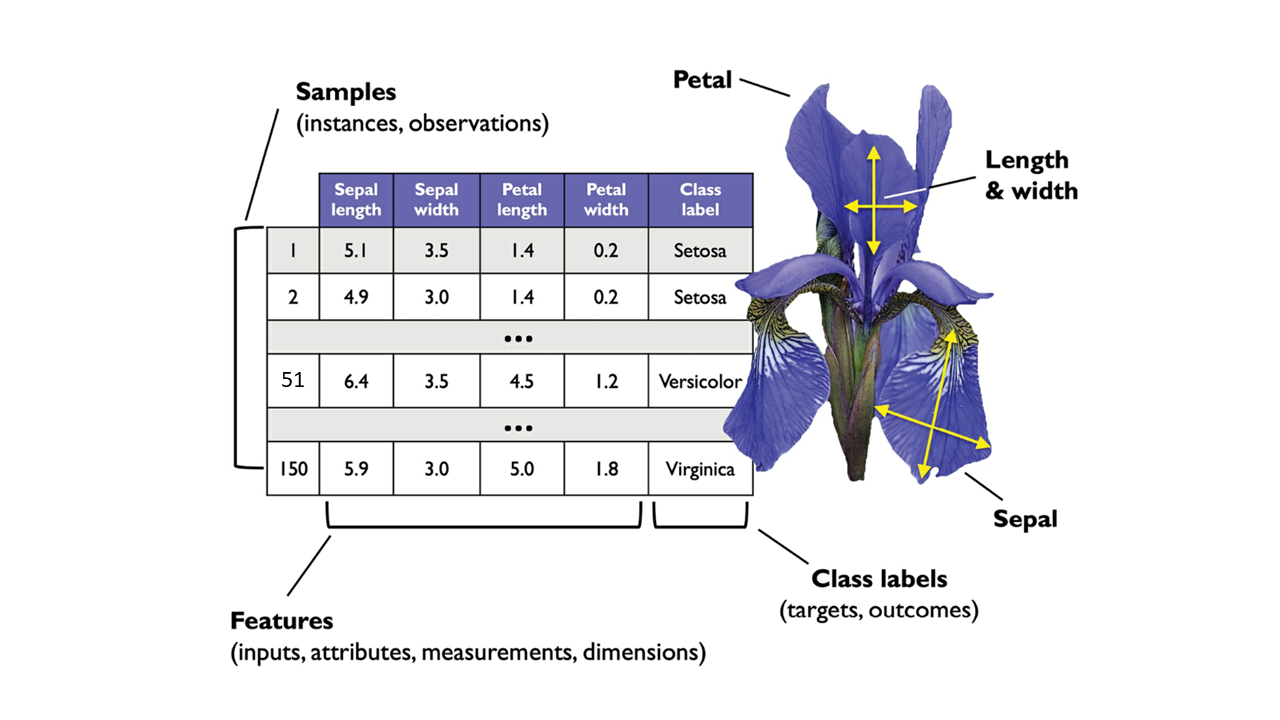

In [16]:
Image('iris.png') if IN_COLAB else display(Image(filename='iris.png'))

[Toy dataset forniti da scikit-learn](https://scikit-learn.org/stable/datasets/toy_dataset.html)<br>
[Lo storico dataset *Iris*](https://en.wikipedia.org/wiki/Iris_flower_data_set)

Se si lavora con un ambiente virtuale, installare scikit-learn con il comando:
```python
conda install scikit-learn
```

In [14]:
from sklearn import datasets             # importa i dataset giocattolo
                                         # sklearn is part of scikit-learn (so 46113732)
from sklearn.datasets import load_iris   # 'load_iris' è il loader del dataset iris, non il dataset

In [15]:
iris = load_iris() # è un oggetto scikit-learn di tipo 'Bunch', inclusivo di documentazione. Non è ancora un df pandas

In [19]:
# attenzione:
type(iris) # un bunch dataset (dati + descrizione)
           # 'type' fornisce la classe dell'oggetto.

sklearn.utils._bunch.Bunch

In [20]:
print(iris.data) # le variabili di previsione
                   # feature, predittori, variabili indipendenti, dimensioni, assi di analisi, colonne, attributi, proprietà

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

In [16]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [22]:
iris.target # i VALORI della variabile risposta (per ogni riga)
            # risposta, output, variabile dipendente, ecc

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [23]:
iris.target_names # i valori DISTINTI del target
                  # The classes are already converted to integer labels where 0=Iris-Setosa, 1=Iris-Versicolor,
                  # 2=Iris-Virginica. (PML notebook)

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [24]:
print(iris.target_names) # come sempre la funzione 'print' cambia (può cambiare) l'output.
                         # 'print' di python3 (funzione) è diversa da python2 (istruzione).

['setosa' 'versicolor' 'virginica']


In [25]:
print(iris.DESCR) # la descrizione inclusa nel dataset

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

Il formato `bunch` (dati + metadati)  in scikit-learn è usato:
- come formato dei dataset giocattolo (iris, wine, breast_cancer, ecc)
- ogni qualvolta vogliamo inserire NEL DATASET anche i metadati, in forma di una lunga descrizione con commenti, statistiche sul dataset, istruzioni di utilizzo.

E' poco usato, il dataframe di *pandas* è molto più comodo.

In [26]:
iris.filename

'iris.csv'

Noi vogliamo lavorare con oggetti pandas, non con oggetti *bunch*. Dobbiamo convertire il dataset iris in formato pandas, molto più comodo, in [questo modo](https://stackoverflow.com/questions/38105539/how-to-convert-a-scikit-learn-dataset-to-a-pandas-dataset):

In [27]:
import pandas as pd
import numpy as np

# il seguente codice NON è rappresentativo del caricamento dei dati a regime (nel corso) che avverrà da file csv o xlsx o da tabella SQL.
# iris è un dataset particolare, già incluso in scikit-learn, e non deve quindi essere letto da file csv.
# per i normali dataset, conviene averli in formato csv, che è particolarmente utile e caricabile in modo efficiente in Jupyter

df = pd.DataFrame(data= np.c_[iris['data'], iris['target']],               # il metodo 'DataFrame' crea il dataframe
                     columns= list(iris['feature_names']) + ['target'])



NB. L'importante, il punto di partenza per il resto del corso, è avere un dataframe (spesso chiamato `df`) contenente i dati da usare. Normalmente (non in questo caso) il dataset è stato caricato dentro il dataframe `df` tramite il metodo *pandas* `pd.read_csv` o la funzione pandas `read_sql`.<br>
Possiamo ora vedere **tutti i metodi applicabili al dataframe `df`**:

In [28]:
display(df)              # programmazione tradizionale: nome funzione(lista argomenti)
# display('\n')          # salta una riga (divide gli output delle due print)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


La funzione `display` visualizza il dataframe in formato HTML + CSS.

In [29]:
type(df)   # la funzione che mostra il tipo dati dell'oggetto 'df'

pandas.core.frame.DataFrame

> In python per capire la classe alla quale un oggetto appartiene si usa la funzione `type`.<br>
> `class` è una keyword riservata per **definire una classe**.

In [30]:
display(type(df))    # 2 funzioni in piping (in cascata)

# "print (nome-oggetto)" oppure "display (nome-oggetto)" permettono di visualizzare gli output sempre, anche se multipli
# nella stessa cella.
# se invece si chiede la visualizzazione di molti oggetti (nella stessa cella) SENZA usare il comando 'print' oppure 'display',
# Jupyter visualizza solo l'ULTIMO output.

pandas.core.frame.DataFrame

![](pandas_dataframe_rendering.png)
Vedi [qui](https://blog.dailydoseofds.com/p/sparklines-the-hidden-gem-of-data?utm_source=substack&utm_medium=email) per maggiori dettagli.

`display` vs `print`: vedi [qui](https://stackoverflow.com/questions/956969/difference-between-print-and-display)<br>
*The output of print() is often **unformatted** and lacks visual appeal.<br>
On the other hand, the display() function is typically used in data analysis and visualization to display data in **a more organized and aesthetically pleasing format**.*

Introduciamo ora i **tre concetti base della OOP: classi, oggetti (istanze) e metodi**:
- la classe `DataFrame` ha molti metodi per operare sui DataFrame
- `df` è un oggetto di classe `DataFrame` e quindi ne eredita tutti i metodi

In [31]:
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
5,5.4,3.9,1.7,0.4,0.0
6,4.6,3.4,1.4,0.3,0.0
7,5.0,3.4,1.5,0.2,0.0
8,4.4,2.9,1.4,0.2,0.0
9,4.9,3.1,1.5,0.1,0.0


> La cella precedente richiama il metodo `head()` della classe `DataFrame`. L'oggetto `df` appartiene alla classe `DataFrame` e dunque ne eredita i metodi. Il metodo ha poi i suoi argomenti di input tra parentesi.

Senza le parentesi il precedente metodo visualizza i dati nel formato python standard (anzichè nel formato Jupyter)

In [47]:
df.head

<bound method NDFrame.head of      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.8  

Nel seguito esaminiamo i **principali metodi** della classe `DataFrame` di *pandas*, oltre al già visto `df.head()`:

In [48]:
df.tail(8)     # programmazione ad oggetti: oggetto-della-classe.metodo della classe

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
142,5.8,2.7,5.1,1.9,2.0
143,6.8,3.2,5.9,2.3,2.0
144,6.7,3.3,5.7,2.5,2.0
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0
149,5.9,3.0,5.1,1.8,2.0


In [49]:
# 'sample' estrae *n* righe a caso; è più utile di 'head' perchè non risente di eventuali ordinamenti nei dati
n = 10
df.sample(n)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
92,5.8,2.6,4.0,1.2,1.0
31,5.4,3.4,1.5,0.4,0.0
76,6.8,2.8,4.8,1.4,1.0
80,5.5,2.4,3.8,1.1,1.0
57,4.9,2.4,3.3,1.0,1.0
43,5.0,3.5,1.6,0.6,0.0
134,6.1,2.6,5.6,1.4,2.0
11,4.8,3.4,1.6,0.2,0.0
126,6.2,2.8,4.8,1.8,2.0
137,6.4,3.1,5.5,1.8,2.0


In [50]:
# l'argomento 'random_state' imposta il seme (seed) iniziale del generatore di numeri pseudo-casuali del software.
# in questo modo il codice è "riproducibile", cioè produce, a parità di codice e dati di input, gli stessi
# risultati ad ogni esecuzione (che sia sullo stesso PC o su PC differenti)

df.sample(n,random_state=1000)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
95,5.7,3.0,4.2,1.2,1.0
34,4.9,3.1,1.5,0.2,0.0
127,6.1,3.0,4.9,1.8,2.0
120,6.9,3.2,5.7,2.3,2.0
24,4.8,3.4,1.9,0.2,0.0
28,5.2,3.4,1.4,0.2,0.0
84,5.4,3.0,4.5,1.5,1.0
68,6.2,2.2,4.5,1.5,1.0
38,4.4,3.0,1.3,0.2,0.0
123,6.3,2.7,4.9,1.8,2.0


Il metodo `sample` può anche essere usato per **rimescolare** (*shuffling*) tutte le righe del dataset - è una buona pratica iniziale perchè il dataset potrebbe essere ordinato rispetto ad una qualche colonna (del quale ordinamento è difficile accorgersi tramite un'analisi esplorativa dei dati se le colonne sono molte) e gli ordinamenti non aiutano a costruire buoni modelli predittivi perchè possono impattare sulla suddivisione dei dati in training ed in test  (se questa è fatta prendendo la prima parte del dataset come training e la seconda parte come test). Se invece si usa la funzione `train_test_split` di *scikit.learn* oppure la Cross-Validazione questo problema è minore (anche se alcuni autori e professionisti preferiscono comunque rimescolare i dati anche in questi casi).

Ovviamente, **lo shuffling NON si deve fare per le serie temporali**, nelle quali c'è un ordinamento dei dati che vogliamo mantenere.

Ecco come si fa lo shuffling. Prima vediamo il metodo `shape` che dà le dimensioni del dataframe:

In [51]:
df.shape  # --> vettore

(150, 5)

In [52]:
df.shape[0]   # subsetting: estrae dal vettore un sotto-insieme di elementi;
              # qui estrae la prima dimensione del df

150

In [53]:
n = df.shape[0]
df = df.sample(n,random_state=1000)   # il trucco è qua, il campionamento è fatto su TUTTE le righe, e quindi costituisce uno shuffling
display(df)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
95,5.7,3.0,4.2,1.2,1.0
34,4.9,3.1,1.5,0.2,0.0
127,6.1,3.0,4.9,1.8,2.0
120,6.9,3.2,5.7,2.3,2.0
24,4.8,3.4,1.9,0.2,0.0
...,...,...,...,...,...
1,4.9,3.0,1.4,0.2,0.0
92,5.8,2.6,4.0,1.2,1.0
94,5.6,2.7,4.2,1.3,1.0
71,6.1,2.8,4.0,1.3,1.0


Come descritto in [questa chat](https://chatgpt.com/share/670e81b4-9c94-8012-a157-8910fe6d2294), è possibile visualizzare molte righe del dataframe (e non solo le prime 5 e le ultime 5) nel seguente modo

In [54]:
# Set the option to display all rows
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 200)
display(df[50:100])
# Optionally, reset the setting back to default
pd.reset_option('display.max_rows', None)
pd.set_option('display.width', None)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
33,5.5,4.2,1.4,0.2,0.0
8,4.4,2.9,1.4,0.2,0.0
98,5.1,2.5,3.0,1.1,1.0
122,7.7,2.8,6.7,2.0,2.0
138,6.0,3.0,4.8,1.8,2.0
83,6.0,2.7,5.1,1.6,1.0
131,7.9,3.8,6.4,2.0,2.0
147,6.5,3.0,5.2,2.0,2.0
93,5.0,2.3,3.3,1.0,1.0
78,6.0,2.9,4.5,1.5,1.0


In [55]:
df[10:100]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
132,6.4,2.8,5.6,2.2,2.0
74,6.4,2.9,4.3,1.3,1.0
44,5.1,3.8,1.9,0.4,0.0
4,5.0,3.6,1.4,0.2,0.0
144,6.7,3.3,5.7,2.5,2.0
...,...,...,...,...,...
5,5.4,3.9,1.7,0.4,0.0
12,4.8,3.0,1.4,0.1,0.0
107,7.3,2.9,6.3,1.8,2.0
29,4.7,3.2,1.6,0.2,0.0


Il metodo `size` fornisce il numero di elementi di un dataframe, cioè il numero di righe per il numero di colonne.

In [56]:
df.size   # 150 x 5--> 750

750

### Il metodo di visualizzazione `style`

Vediamo ora l'interessante metodo di pandas `style`:

Il metodo `.style` di un oggetto Pandas DataFrame serve a **formattare visivamente** i dati per **migliorarne la leggibilità**, <u>senza modificarne il contenuto</u>. È molto utile quando si vuole esportare o visualizzare un DataFrame in modo più chiaro, ad esempio in un Jupyter Notebook o in un report HTML.

`df.style` restituisce un oggetto di tipo `Styler`, che permette di **applicare stili** (colori, formati numerici, gradienti, barre, ecc.) al DataFrame.

Occorre prima installare nell'ambiente virtuale (da <u>anaconda prompt e con conda!</u>) il package **Jinja2**.

In [57]:
if IN_COLAB:
  !pip install Jinja2
else:
  !conda install Jinja2 -y

^C


In [66]:
df.head().style

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
95,5.700000,3.000000,4.200000,1.200000,1.000000
34,4.900000,3.100000,1.500000,0.200000,0.000000
127,6.100000,3.000000,4.900000,1.800000,2.000000
120,6.900000,3.200000,5.700000,2.300000,2.000000
24,4.800000,3.400000,1.900000,0.200000,0.000000


La semplice invocazione del medoto `style` di *pandas* NON visualizza nulla di differente; essa semplicemente attiva la modalità "stilizzazione" del DataFrame, permettendo l'aggiunta di formattazioni visive (valida solo in ambienti come Jupyter Notebook o Google Colab).

In [67]:
type(df.style)

pandas.io.formats.style.Styler

#### Colorazione valori sotto soglia

Colora valori sotto una soglia:

In [68]:
df.head().style.applymap(lambda v: 'color: red' if v < 1 else '')     # 'applymap' applica una funzione lambda
                                                                      # funzione deprecata --> map!

C:\Users\Utente\AppData\Local\Temp\ipykernel_15032\1158969951.py:1: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  df.head().style.applymap(lambda v: 'color: red' if v < 1 else '')     # 'applymap' applica una funzione lambda


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
95,5.700000,3.000000,4.200000,1.200000,1.000000
34,4.900000,3.100000,1.500000,0.200000,0.000000
127,6.100000,3.000000,4.900000,1.800000,2.000000
120,6.900000,3.200000,5.700000,2.300000,2.000000
24,4.800000,3.400000,1.900000,0.200000,0.000000


In [69]:
df.head().style.map(lambda v: 'color: red' if v < 1 else '')

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
95,5.700000,3.000000,4.200000,1.200000,1.000000
34,4.900000,3.100000,1.500000,0.200000,0.000000
127,6.100000,3.000000,4.900000,1.800000,2.000000
120,6.900000,3.200000,5.700000,2.300000,2.000000
24,4.800000,3.400000,1.900000,0.200000,0.000000


---
In Python, le **deprecazioni** (o funzioni/feature/metodi/argomenti deprecati) sono avvisi che indicano che una certa funzionalità è **obsoleta e potrebbe essere rimossa** in future versioni del linguaggio o della libreria.

In pratica:<br>
Una funzione deprecata funziona ancora, ma non è più consigliato usarla, perché:
- è stata sostituita da qualcosa di migliore.
- ha problemi di sicurezza o prestazioni.
- è incoerente con il resto della libreria
- **in futuro NON funziona più**

Il messaggio precedente di deprecazione era un *warning*. In Python è possibile, anche se sconsigliato, ignorare i warnings in questo modo.

```python
import warnings
warnings.filterwarnings("ignore")
```

E' sempre possibile ripristinare i warning con questa istruzione:

```python
warnings.resetwarnings()
```

---

#### Formattazione numerica

In [70]:
df.head().style.format("{:.2f}")   # solo 2 cifre decimali

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
95,5.70,3.00,4.20,1.20,1.00
34,4.90,3.10,1.50,0.20,0.00
127,6.10,3.00,4.90,1.80,2.00
120,6.90,3.20,5.70,2.30,2.00
24,4.80,3.40,1.90,0.20,0.00


Un altro modo, più semplice e comune, per arrotondare le cifre decimali, è la funzione `round`:

#### Barre orizzontalli nelle celle

In [71]:
display(df.head().style.bar(subset=['sepal length (cm)'], color='lightblue'))
df.style.bar(subset=['sepal length (cm)', 'sepal width (cm)'], color='#d65f5f')

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
95,5.700000,3.000000,4.200000,1.200000,1.000000
34,4.900000,3.100000,1.500000,0.200000,0.000000
127,6.100000,3.000000,4.900000,1.800000,2.000000
120,6.900000,3.200000,5.700000,2.300000,2.000000
24,4.800000,3.400000,1.900000,0.200000,0.000000


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
95,5.700000,3.000000,4.200000,1.200000,1.000000
34,4.900000,3.100000,1.500000,0.200000,0.000000
127,6.100000,3.000000,4.900000,1.800000,2.000000
120,6.900000,3.200000,5.700000,2.300000,2.000000
24,4.800000,3.400000,1.900000,0.200000,0.000000
28,5.200000,3.400000,1.400000,0.200000,0.000000
84,5.400000,3.000000,4.500000,1.500000,1.000000
68,6.200000,2.200000,4.500000,1.500000,1.000000
38,4.400000,3.000000,1.300000,0.200000,0.000000
123,6.300000,2.700000,4.900000,1.800000,2.000000


Attenzione:
- `.style` non modifica i dati
- le trasformazioni sono solo estetiche, utili per output visivo (es. in HTML).

#### Gradiente di colore su una colonna

In [64]:
df.head().style.background_gradient(cmap='coolwarm')
# df.head().style.background_gradient(cmap='RdBu_r') # 'RdBu_r', oppure 'BrBG_r', oppure ancora 'PuOr_r' sono altri buoni
                                                     # schemi di colori divergenti.

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
95,5.700000,3.000000,4.200000,1.200000,1.000000
34,4.900000,3.100000,1.500000,0.200000,0.000000
127,6.100000,3.000000,4.900000,1.800000,2.000000
120,6.900000,3.200000,5.700000,2.300000,2.000000
24,4.800000,3.400000,1.900000,0.200000,0.000000


`style.background_gradient(cmap='coolwarm')` colora le celle **numeriche** con un **gradiente di colori** secondo i valori numerici contenuti in ogni colonna (in modo INDIPENDENTE per ogni colonna).

Il colore cambia in base alla scala di valori: valori più bassi da un lato della mappa colore, valori più alti dall'altro.

**La mappa 'coolwarm' va dal blu (valori bassi) al rosso (valori alti) - PER COLONNA.** Le mappe sono le `colormap` di `matplotlib`.

Quando usare questo metodo?
- Per evidenziare velocemente valori alti/bassi in una tabella.
- Per presentazioni, report interattivi, o debugging visivo di dati.

> Il metodo `style.background_gradient` è un caso particolare dello [styling](https://pandas.pydata.org/pandas-docs/version/1.1/user_guide/style.html#Builtin-styles).

Per altri schemi di colore vedi [questa chat](https://chatgpt.com/share/6863f5a0-b9b8-8012-b928-172f29b12bb7).

In [65]:
help(df.style.background_gradient)

Help on method background_gradient in module pandas.io.formats.style:

background_gradient(
    cmap: 'str | Colormap' = 'PuBu',
    low: 'float' = 0,
    high: 'float' = 0,
    axis: 'Axis | None' = 0,
    subset: 'Subset | None' = None,
    text_color_threshold: 'float' = 0.408,
    vmin: 'float | None' = None,
    vmax: 'float | None' = None,
    gmap: 'Sequence | None' = None
) -> 'Styler' method of pandas.io.formats.style.Styler instance
    Color the background in a gradient style.

    The background color is determined according
    to the data in each column, row or frame, or by a given
    gradient map. Requires matplotlib.

    Parameters
    ----------
    cmap : str or colormap
        Matplotlib colormap.
    low : float
        Compress the color range at the low end. This is a multiple of the data
        range to extend below the minimum; good values usually in [0, 1],
        defaults to 0.
    high : float
        Compress the color range at the high end. This is a m

#### Trasformazione in HTML

In [ ]:
# Applica uno stile
styled_df = df.style.background_gradient(cmap='coolwarm')   # 'coolwarm' è uno schema di colori

# Salva in un file HTML
with open("styled_table.html", "w") as f:
    f.write(styled_df.to_html())

Eseguire da Windows il file `styled_table` salvato nella directory corrente (`%pwd`)

#### I massimi

In [ ]:
df.style.highlight_max(axis=0,color='red')

#### Alcuni post sul metodo `style`:

In [ ]:
Image('gradient_background_pandas_2.png') if IN_COLAB else display(Image(filename='gradient_background_pandas_2.png'))

In [ ]:
Image('gradient_background_pandas.png') if IN_COLAB else display(Image(filename='gradient_background_pandas.png'))

Su come usare il metodo `style.background_gradient` vedi anche [qui](https://stackoverflow.com/questions/75995479/how-to-apply-a-background-gradient-to-the-first-n-greatest-values-in-a-pandas-da) e [qui](https://www.geeksforgeeks.org/make-a-gradient-color-mapping-on-a-specified-column-in-pandas/).

### Come vedere gli *argomenti* di input di una funzione o di un metodo
In **Jupyter Notebook**:
> * posizionare il cursore **all'interno delle parentesi tonde** (sia le funzioni che i metodi richiedono che gli argomenti siano elencati tra parentesi tonde)
> * premere la combinazione di tasti `maiusc` + `tab`
> * ingrandire la finestra premendo la freccia in su

In **Google Colab**:
> * posizionare il mouse sul **nome del metodo/funzione** nella cella codice

In modo alternativo si può usare la funzione `help`, ad esempio `help(df.style.background_gradient)`

### Altri metodi pandas

In [ ]:
# elenco dei data-type elementari di PANDAS (aka, atomici)
df.dtypes  # This returns a Series with the data type of each column.
           # 'dtype' sta per 'data-type'.
           # --> Non confondere con 'type(df)'' che fornisce il data-type dell'oggetto 'df' nel suo insieme.

           # 'dtypes' è un metodo fornito dalla classe DataFrame (senza argomenti)

## Nota sui data-type di Python, pandas e numpy

In [ ]:
# alcuni data type elementari di python

a = 10
print(type(a))
a = "pippo"      # riassegnazione
print(type(a))   # --> il datatype è cambiato!

### I data type
Cioè i i formati ammessi per i dati:
* [i principali data-type in Python](python_data_types.png) - poco importanti in questi corsi, a parte `list` e `dict`
* i [data-type di pandas: Serie vs Dataframe](Series_vs_DataFrame.png), con i loro [data type atomici](pandas_data_types.png)
* le [array di numpy](numpy_array.png) (nb. il data typing di numply è complesso e va oltre lo scopo di questo notebook; vedi ad esempio [qui](numpy_data_types.png))
* i [data-type atomici di pandas](https://chatgpt.com/share/6707edca-7b30-8012-9e2f-31e3aba79a61) di pandas, aka `dtypes`
* [mapping python-pandas-numpy](data_types_mapping.png) per i data-type atomici

> A differenza della maggior parte dei package, i due package *pandas* e *numpy* hanno i loro data-type e, come tutti i package, estendono python base. Quindi, in  pandas e numpy possiamo usare i data-type python - ad esempio il data-type `dict` di python base nel metodo *pandas* `rename` o nella funzione pandas `pd.DataFrame`- non il contrario, cioè non possiamo usare un data-type *dataframe* di pandas oppure un *array* di numpy in python se non abbiamo importato i due package.

In [ ]:
# esempio di lista:
lista = [10,"alessandria",True]
display(lista[2])        # subsetting ordinato

# esempio di dizionario:
dizionario = {"id cliente":100,"nome cliente":"Mario Rossi"}
dizionario["id cliente"]

A cosa serve un dizionario? Uno desi suoi usi principali è nella creazione di **dataframe per elencazione**:

In [ ]:
data_dict = {
    "id cliente": [1,2,3,4,5],
    "nome cliente":["Mario Rossi","Giuseppe Verdi", "Anna Bianchi", "Antonio Rossi","Valeria Bianchini"]
    }
data_dict
df_new = pd.DataFrame(data=data_dict)
df_new.head()

Dataframe e Serie di pandas possono essere definiti per elencazione dei valori, ma in genere sono **letti da file csv** o da **tabella SQL**. Le array di numpy  sono spesso il risultato di elaborazioni numeriche.<br>
Sono **oggetti in memoria**, che possono essere salvati su disco (ad esempio con il metodo `to_csv()`.

In [ ]:
df.to_csv("dataframe_prova.csv")

In [ ]:
%pwd

In [ ]:
del(df)
df = pd.read_csv("dataframe_prova.csv").drop(columns=['Unnamed: 0'])
df.head()

Le array di numpy sono indispensabili per lavorare con pandas, che infatti è costruito sopra numpy. Spesso i metodi dei package (ad esempio di scikit-learn) in input hanno un dataframe pandas e in output restituiscono un'array numpy. Il caso classico è quello della **standardizzazione**:

In [ ]:
from sklearn import preprocessing         # il modulo che contiene MOLTE funzioni di pre-elaborazione


np.set_printoptions(suppress=False)       # sopprime l'uso della notazione scientifica per piccoli numeri: # imposta la precisione dell'output della mantissa (se tutte le cifre decimali danno fastidio)
df_std = preprocessing.scale(df)          # la standardizzazione si può fare solo su colonne numeriche
print(type(df_std))
df_std.shape

3 passaggi importanti in questa cella:
- la soppressione della notazione scientifica (comoda ma poco comprensibile alla maggioranza degli utenti)
- il funzionamento **vettoriale** della funzione di standardizzazione
- l'output non è più un dataframe ma è un'array numpy
.

In [ ]:
df.head()

In [ ]:
s = (df['sepal length (cm)'] - df['sepal length (cm)'].mean())/df['sepal length (cm)'].std() # funzionamento VETTORIALE
s.hist()

### Nota sui dati atomici numerici
13.5 è un dato:
* **continuo** o **reale** in matematica
* **floating** in informatica (a virgola mobile)
* **numero con decimali** nel linguaggio colloquiale

3 è un dato:
* **intero** o **discreto**

A prescindere da ciò, nei computer i numeri continui sono rappresentati con una mantissa ed un esponente (in base 10). Ad esempio, 13.5 è rappresentato come: 0.135 (mantissa) * esponente (2). Questa rappresentazione è detta [notazione scientifica](https://it.wikipedia.org/wiki/Notazione_scientifica).

La notazione scientifica può essere utilizzata automaticamente (dalle funzioni / metodi python) quando i numeri sono molto grandi o molto piccoli. La si può disabilitare e riabilitare nei seguenti modi:

In [ ]:
# in PANDAS:

import pandas as pd

# OPZIONE 1: disabilitazione della notazione scientifica:
pd.set_option('display.float_format', '{:.2f}'.format)  # Mostra 2 decimali, no notazione scientifica
# Forza Pandas a mostrare i numeri in virgola mobile con due decimali. Cioè, disabilita la notazione scientifica, anche per valori molto piccoli
# o molto grandi.
display(df.head())

# OPZIONE 2: abilitazione:
pd.reset_option('display.float_format')  # NON 'forza' la notazione scientifica, lascia la decisione a pandas, che usa la notazione scientifica
                                         # solo per numeri molto piccoli o molto grandi
display(df.head())


# Se vuoi scientifica sempre, imposta esplicitamente '{:.2e}'.format.
pd.set_option('display.float_format', '{:.2e}'.format)
display(df.head())


# abilitazione per la sola cella corrente (per un ipotetico df:
# with pd.option_context('display.float_format', '{:.2f}'.format):
#    display(df.describe())


In [ ]:
# in NUMPY
import numpy as np

print("dati originali: \n", df_std[:5])

# disabilitazione notazione scientifica:
np.set_printoptions(suppress=True)  # Disattiva notazione scientifica

print("disabilitazione NS: \n",df_std[:5])

# abilitazione notazione scientifica:
np.set_printoptions(suppress=False)  # Riattiva notazione scientifica se i numeri lo richiedono (lascia la decisione a numpy)

print("abilitazione NS: \n",df_std[:5])

# forzatura notazione scientifica
np.set_printoptions(formatter={'float_kind': '{:.2e}'.format})

print("forzatura NS: \n", df_std[:5])



In [ ]:
print(df_std)

In [ ]:
# per stampe PYTHON:

x = 0.000012345
print("{:.10f}".format(x))     # Stampa in decimale con 10 cifre dopo la virgola
print("{:.2e}".format(x))      # Stampa in notazione scientifica

### Tipizzazione
Siccome Python non è un linguaggio a tipizzazione forte (*semi-weak typing*), non si fa la dichiarazione iniziale degli oggetti. Il data-type dell'oggetto è definito per assegnazione, tranne alcune eccezioni, ad esempio per creare un dataframe pandas con le funzioni specifiche (`pd.DataFrame` oppure `pd.read_csv`).

Python inoltre è un linguaggio a tipizzazione dinamica.

### Il range
Il range:
- è una classe built-in in Python
- può essere considerata un vero e proprio tipo di dato nativo, come `int`, `float`, `list`, ecc. Infatti `type(range(10)` restituisce `range`
- è un **iterabile** (come una lista, un dizionario, ecc.), ma è molto più efficiente in termini di memoria perché non costruisce l’intera sequenza in memoria; in questo modo, ad esempio:<br>
``` python
for i in range(5):
    print(i)
```
- ha al massimo 3 argomenti: start, stop (il valore n+1 è il primo valore out-of-sequence al quale appunto la sequenza si ferma), step (l'ampiezza dello step)

In [ ]:
for i in range(20,30,2):
  print(i)

In [ ]:
type(range(10))

### Iterabili e iteratori

**ITERABILE** (*iterable*)<br>
Un iterabile è un oggetto da cui puoi ottenere un iteratore. In parole più semplici, un oggetto cche può essere iterato.<br>
Ha un metodo speciale chiamato `__iter__()` che ritorna un iteratore.

**ITERATORE** (*iterator*)<br>
Un iteratore è un oggetto che sa come attraversare una sequenza di dati uno alla volta, grazie al metodo `__next__()`.<br>
Ogni volta che chiami next() su un iteratore, ottieni il prossimo valore. Quando non ci sono più valori, lancia StopIteration.

**Esempi di iterabili comuni:**
- Liste: ["a", "b", "c"]
- Tuple: (1, 2, 3)
- Stringhe: "ciao"
- Dizionari (per coppie chiave-valore): {"a": 1, "b": 2}
- Oggetti range(): range(5)
- Set: {1, 2, 3}
- File aperti (open("file.txt"))
- Oggetti personalizzati che implementano il metodo __iter__()

```python
lista = [1, 2, 3]          # iterabile
iteratore = iter(lista)    # ottieni un iteratore

print(next(iteratore))     # 1
print(next(iteratore))     # 2
print(next(iteratore))     # 3
print(next(iteratore))     # StopIteration!
```

Ovviamente potevamo usare un ciclo for:

```python
for elemento in lista:
    print(elemento)
```

Vedi [questa chat](https://chatgpt.com/share/68664384-00c4-8012-aa49-658214398a75) sui vantaggi degli iteratori rispetto al ciclo for.

In [ ]:
lista = [1, 2, 3]          # iterabile
print(type(lista))

iteratore = iter(lista)    # ottieni un iteratore
print(type(iteratore))

for elemento in range(len(lista)):
  print(next(iteratore))


In [ ]:
len(lista)

### Type casting (conversione di tipo ELEMENTARE)

**Type casting *esplicito***: il cambio esplicito di tipo di una variabile da un tipo a un altro.

In [ ]:
# esempi di casting esplicito in PYTHON
a = "123"
b = int(a)                            # cast da string a intero
print(type(b))

c = 3.14
d = int(c)                            # cast da float a int (risultato: 3)
print(type(d))
e = 1
f = float(e)                          # cast da int a float (risultato: 1.0)
print(type(f))

arr = np.array([1,2,3],ndmin=0)       # cast da array numpy a lista
type(list(arr))

Il metodo pandas `astype()` è un type casting esplicito, quindi è un modo "safe" e controllato per cambiare tipo a una colonna di un Dataframe o a un'intera Series.

**Type casting *implicito***: Python converte automaticamente un tipo in un altro quando necessario.

In [ ]:
x = 5      # int
y = 2.0    # float
z = x + y  # Python converte 'x' in float -> z sarà 7.0

---
Per la conversione dei tipi di dati strutturati:
- da `dataframe` a `array`
- e viceversa
  
vedi la sezione 13.7.

---

In Python, senza corrispondenti con pandas e numpy, c'è <u>anche</u> l'importante data-type *strutturato* `list`, descritto [qui](https://www.programiz.com/python-programming/list#google_vignette); vedi [qui](https://docs.python.org/3/tutorial/datastructures.html) per i suoi metodi.<br>
Anche il data-type `dict` di Python è importante perchè permette di gestire i metadati, ad esempio i nomi delle colonne.

In [ ]:
lista = [1.3,2,3]
type(lista)

In [ ]:
lista[0]

In [ ]:
# trasformazione lista in serie
s = pd.Series(lista)

In [ ]:
type(s)     # la classe strutturata

In [ ]:
s.dtypes    # il data type elementare

In [ ]:
lista = [1.3,2,3,"salve"]    # possibile! (la lista è eterogenea)
type(lista)

In [ ]:
s = pd.Series(lista)
type(s)

In [ ]:
s # --> la serie è ovviamente di tipo "object" (in pandas "stringa")

## Esame del dataframe

In [ ]:
df

In [ ]:
print(df)    # formato python
display(df)  # formato Jupyter (HTML / CSS)
df           # formato Jupyter (HTML / CSS)


In [ ]:
df.dtypes

La colonna `target`, sebbene formalmente sia di formato numerico, in realtà è una variabile categorica, meglio rappresentata in pandas con il data type `category`.

**Nota sui data-type elementari (atomici) del dataset importato**<br>
Cosa fare se un data-type non è corretto o non è quello desiderato? (ad esempio, `target` di `iris` è `float64` ma dovrebbe essere `category`!).<br>
Ci sono due possibilità:
* i data type possono essere convertiti successivamente, con il metodo pandas `astype()` - vedi [qui](https://sentry.io/answers/change-a-column-type-in-a-dataframe-in-python-pandas/#:~:text=If%20we%20want%20to%20convert,should%20use%20the%20to_numeric%20function.) e soprattutto [qui](https://stackoverflow.com/questions/15891038/change-column-type-in-pandas)
* oppure possono essere forzati nella `pd.read_csv` con l'argomento `dtype` (vedi [qui](https://www.statology.org/pandas-read-csv-dtype/) oppure [qui](https://saturncloud.io/blog/how-to-specify-data-type-in-pandas-csv-reader/))

Per prima cosa, vediamo come estrarre dal dataframe **solo le colonne di un certo data-type**.<br>
Il data-type `number` - disponibile solo per il metodo `select_dtypes` - raggruppa, per comodità, tutti i data type numerici di pandas (int32, inmt64, float32, float64).

In [ ]:
df.select_dtypes(['number']) # utile metodo per selezionare tutte e sole le variabili NUMERICHE (float64, int64)
                             # filtro di colonna in base al tipo colonna

In [ ]:
df.select_dtypes(['object']) # utile metodo per selezionare tutte e sole le variabili STRINGA (object);
                             # --> nessuna, in questo dataset (a parte l'identificativo di riga che è sempre visualizzato)

In [ ]:
df.select_dtypes(['datetime']) # utile metodo per selezionare tutte e sole le variabili DATETIME;
                             # --> nessuna, in questo dataset.

In [ ]:
df.select_dtypes(['timedelta']) # utile metodo per selezionare tutte e sole le variabili TIMEDELTA;
                             # --> nessuna, in questo dataset.

Il metodo `select_dtypes` è utile (soprattutto ma non solo) quando il dataframe ha molte colonne (decine, centinaia)

In [ ]:
df.dtypes    # i data type atomici

## Variabili quantitative vs qualitative
> E' importante distinguere le variabili numeriche in **quantitative** e **qualitative**:
![](variables_types.png)

In [ ]:
df.dtypes

**Come modificare il data-type di `target` in `category`?**
Come visto prima, ci sono due modi. Qui applichiamo la forzatura ex-post.

In [ ]:
df['target'] = df['target'].astype('category')

In [ ]:
df.dtypes

In [ ]:
df.select_dtypes(['category'])

Ai fini del Machine Learning la tipizzazione della colonna `target`come `category` è opportuna. Vedi [questa chat](https://chatgpt.com/share/68665f34-fd34-8012-b710-a69d1589def4).

## Oggetti ad una singola dimensione

In [ ]:
# creazione di un vettore in Python:
d = {'a': 1, 'b': 2, 'c': 3}   # oggetto python di tipo 'dict' - un oggetto ad 1 dim (in questo caso)
print(d)
type(d)
pd.Series(d)                   # conversione in serie

> Incontriamo qui per la prima volta il data-type **dizionario** (`dict`).<br>
> Il dizionario è usato spesso per creare un dataframe (2D) `per elencazione`:
>
> ```python
> # l'istruzione di creazione del seguente dataframe, per elencazione dei valori, utilizza tutti e tre i tipi di parentesi:
> df_prova = pd.DataFrame(data=                         # () per gli argomenti del metodo 'DataFrame'
>    {                                                 # {} per la definizione dei metadati
>        'lab':['A', 'B', 'C'], 'val':[10, 30, 20]}    # [] per l'elenco dei valori
>)
> ```

Le *series* di pandas e le array 1D di numpy sono vettori 1D e fortunatamente hanno  entrambe *shape*: `(k,)`.

In [ ]:
# creazione di una serie pandas per elencazione:
d = {'a': 1, 'b': 2, 'c': 3}                   # un 'dict' perchè contiene metadati e dati
s = pd.Series(data=d, index=['a', 'b', 'c'])   # creazione serie ed indice a partire dal dizionario d
print(s)
print("\n",s.shape)

In [ ]:
# creazione di una array 1D in numpy: ci sono vari modi
list = [100, 200, 300, 400]                    # creazione di una lista python, in generale
                                               # un vettore di elementi (anche eterogenei), senza metadati

a = np.array(list)                             # creazione di un'array numpy a partire da una lista
print("\n",a)
print("\n",a.shape)
print(type(a))

Questa è invece una array a 3 dimensioni.

In [ ]:
list = [[[100,101], [200,201], [300,301], [400,401]],[[1,1.5],[2,2.5],[3,3.5],[4,4.5]]]    # <-- tripla parentesi (lista annidata)

n = np.array(list)                   # array numpy 3D
print(n.shape)
print(type(n))
n

La lista annidata è semplicemente un espediente per creare l'array numpy. In generale le liste non hanno più di due/tre livelli di annidamento.<br>
Le array numpy possono invece arrivare a 32 di dimensioni.

## Le liste

**Liste *enumerated* vs liste *nested*** (di python)

Per quanto riguarda le liste ce ne sono di due tipi: vedi [questa](https://chatgpt.com/share/89fe4b45-0434-4719-945e-7123cff6a538) e [questa](https://chatgpt.com/share/72a0b81d-7cb2-4f3c-8629-bb3a389b67fb) chatGPT.

## Le statistiche descrittive
Per ogni **colonna** numerica del dataframe è possibile ed utile vedere le principali "statistiche":
* conteggio elementi
* min
* max
* media aritimetica (average), spesso indicata come $\mu$
* deviazione standard, spesso indicata come $\sigma$
* primo quartile (25%)
* secondo quartile (50%), detto anche mediana
* terzo quartile (75%)
* moda, cioè il valore più probabile

Media, mediana e moda sono statistiche **centrali**, la deviaizone standard (ed anche la varianza, che è semplicemente il quadrato della deviazione standard ed è spesso indicata come $\sigma^2$) è una misura di **variabilità**. In linea generale, la deviazione standard è preferibile.

In [ ]:
round(df[['target']].describe(),2) # funzioni statistiche DESCRITTIVE (da qui il nome);
                       # solo per le variabili numeriche, che sono escluse automaticamente dal metodo;
                       # questo metodo interpreta la variabile 'target' come numerica;

                       # 'describe' è un METODO fornito dalla classe 'DataFrame' ed applicabile quindi a tutte le istanze di
                       # questa classe (ad esempio, 'df').
                       # round è una FUNZIONE
                       # sia i metodi che le funzioni usano le parentesi tonde per elencare gli argomenti.
                       # ci sono sia metodi che funzioni che NON hanno argomenti.



Per calcolare la moda, si può usare il metodo `mode` - vedi [qui](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.mode.html).

In [ ]:
df.mode(axis=0)  # --> fornisce 3 righe perchè la colonna "target" è equi-distribuita (50 0, 50 1 e 50 2)

E' possibile richiedere una singola statistica (e non tutte!) con il metodo specifico: `mean`, `median`, `sd`, ecc.<br>
A differenza del metodo `describe`, questi metodi non sanno distinguere tra colonne numeriche e non, per scartare queste ultime. Per evitare l'errore, occorre dunque selezionare (col subsetting) solo le colonne numeriche.

In [ ]:
display(df[['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']].mean())
display(df[['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']].median())
display(df[['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']].std())

Per le statistiche delle **serie** si fa così:

In [ ]:
lista = [10,30,50,50]             # lista python
s = pd.Series(lista)              # conversione lista in series di pandas
s

In [ ]:
s.describe()

In [ ]:
round(s.describe())

In [ ]:
lista = [10,30,50,50,"pippo"]   # lista python
s = pd.Series(lista)            # conversione lista in series di pandas
s.describe()                    # il metodo 'describe'  applicatoi ad una serie NON numerica --> output differente

Una misura statistica descrittiva utile è il [coefficiente di variazione](https://it.wikipedia.org/wiki/Coefficiente_di_variazione), dato dal seguente rapporto:

$$
\frac{\sigma}{|\mu|}
$$
Il CV è utile per due motivi:
* per valutare la variabilità di una variabile casuale (la colonna di un dataframe) a prescindere dalla sua unità di misura
* per confrontare la variabilità delle varie colonne quando esse hanno unità di misura differenti (non nel caso particolare di iris)

In pandas non c'è un metodo per il calcolo diretto del CV.

In [ ]:
import numpy as np
df['sepal length (cm)'].std() / np.abs(df['sepal length (cm)'].mean())

> Un CV basso (< 15-20%) indica che la variabile (la colonna del dataframe) è poco distribuita, cioè è abbastanza centrata sul suo valore medio. Al contrario, mano a mano che il CV cresce di valore, la variabile è sempre più distribuita e quindi il suo valore medio è meno rappresentativo. Cioè, come conseguenza pratica, la nostra "fiducia" sul valore medio e sulla sua rappresentatività diminuisce molto. Quindi il cutoff è in genere intorno a 0.15 - 0.20.<br>
> Se il CV (della colonna) è maggiore del cutoff, cosa si può fare:
> * aumentare la dimensione del campione; questo perchè la formula della deviazione standard contiene N (il numero degli elementi) al denominatore - vedi [qui](https://it.wikipedia.org/wiki/Scarto_quadratico_medio)
> * suddividere la colonna in sotto-popolazioni (se sensato)

In [ ]:
lista = [10, 20,30,40,50]
s = pd.Series(lista)
print(s.mean())
s.std()

> Due comode alternative al metodo `describe()` sono **skimpy** e **SummaryTools** (vedi la sezione sul *Profiling*) che generano delle comode sintesi del dataframe in pochi secondi.

## Altri metodi di pandas

In [ ]:
df.dtypes

In [32]:
# cambiamo i nomi delle variabili (senza i cm) - con 'inplace=True'
df.rename(columns={'sepal length (cm)': 'sepal length', 'sepal width (cm)': 'sepal width','petal length (cm)': 'petal length','petal width (cm)': 'petal width'}, inplace=True)
# Notare l'argomento 'inplace=True' al fondo della riga.

# la cella può essere rieseguita parecchie volte senza dare errore (in caso di errore --> by-pass)

In [ ]:
df

In [ ]:
df.head()

In [ ]:
df.columns # i nuovi nomi delle variabili (per lo standard PEP8 in lettere minuscole ed underscore)

In [ ]:
df.dtypes

> Attenzione: l'argomento `inplace == True` (ove disponibile) realizza **la persistenza (del dataframe) in memoria**. Cioè, per tutta la restante sessione, l'oggetto `df` ha i nuovi nomi delle colonne.<br>
Altra cosa è la **persistenza (del dataframe) su disco**, realizzabile ad esempio con il metodo `to_csv`

In [ ]:
df.to_csv("dataset_tidy.csv")

In [ ]:
%pwd

In [ ]:
%ls

In [ ]:
df.drop(columns=['sepal length', 'sepal width', 'petal length', 'petal width'], inplace=True)

In [ ]:
del df

In [ ]:
df = pd.read_csv("dataset_tidy.csv")

In [ ]:
df.drop(columns='Unnamed: 0', inplace=True)

Una **tabella di contingenza** è una tabella incrociata tra due colonne ed elenca per ogni valore della prima colonna la frequenza assoluto (cioè il conteggio) di tutti i possibili valori della seconda colonna.<br>
Ogni cella rappresenta il numero di righe (0,1,2,3, ....n) del dataframe che hanno quel valore della prima e seconda colonna.

In [ ]:
pd.crosstab(index=df['sepal length'],columns=df['sepal width'])  # tabella di contingenza (incrociata)
                                                                 # nb. è una funzione (di pandas), non un metodo, e perciò
                                                                 # occorre premettere 'pd' !


Un esempio applicativo può essere, in un dataset bancario, la *crosstab* tra la colonna *reddito* (come indice delle righe) e la colonna *età* (sulle colonne): ci permette di vedere le frequenze per ogni combinazione di reddito ed età.

In [ ]:
df_credit=pd.read_csv("Credit_ISLR.csv")
df_credit.drop(columns=['Unnamed: 0','ID'], inplace=True)
display(df_credit.head())
display(df_credit.shape)
pd.set_option('display.max_columns', None)
display(pd.crosstab(index=df_credit['Gender'],columns=df_credit['Age']))
pd.reset_option('display.max_columns')


Un primo esempio di **subsetting**. Noi in genere NON lavoriamo su tutto il dataframe; ci interessano dei sottoinsiemi (*subset*) di righe e/o colonne.

In [ ]:
df['sepal length'].describe()   # estrae una colonna specifica

In [ ]:
# ad una colonna specifica possiamo applicare i vari metodi di pandas che abbiamo usato prima applicati al dataframe
# nella sua interezza:
display(df['sepal length'].head(10))      # funziona perchè il metodo 'head' c'è anche per le serie
display(df['sepal length'].describe())    # funziona perchè il metodo 'describe' c'è anche per le serie

In [ ]:
# per contare i valori UNICI di una colonna:
df['target'].value_counts()

Probabilmente è più utile un istogramma:

In [ ]:
df['sepal length'].hist(bins=20)

In [ ]:
df_credit['Income'].hist(bins=30)

Il metodo `hist` di *pandas* NON ha il parametro frequenza relativa. Per una soluzione alternativa vedi [questa chat](https://chatgpt.com/share/68469e1b-3e48-8012-9113-2f01d4643cb2).

Vediamo ora un altro utilizzo del metodo `crosstab`. Il modo *pandas* per calcolare le frequenze dei valori per le variabili categoriche è il seguente:

In [ ]:
pd.crosstab(index=df['target'],  # Make a crosstab
            columns="count")

In [ ]:
# elenco dei valori unici di una colonna qualitativa (cioè, categorica)
df['target'].unique()

In [ ]:
# elenco dei valori unici di una colonna quantitativa (cioè, categorica)
df['sepal length'].unique()

E' interessante vedere i seguenti 2 tipi (classi):

**Nota importante** sul <u>subsetting</u> dei dataframe:

In [ ]:
display(type(df['sepal length']))            # una serie
display(type(df[['sepal length']]))          # un dataframe

A seconda che il subsetting di colonna sia eseguito con le [] singole oppure con le [[]] doppie, la classe (cioè il tipo di dato) ottenuto cambia. E' importante perchè alcuni metodi si possono applicare solo ai dataframe, costituiti da righe e colonne, ed altri solo alle serie, costituite da un vettore. Come si può vedere nel seguito:

In [ ]:
display(df['sepal length'].shape)
df[['sepal length']].shape

> Entrambi i subsetting forniscono la stessa sequenza di dati (cioè i 150 valori di *sepal length*) ma **in formato diverso**, il primo è una serie 1D, il secondo è un dataframe 2D (ancorchè la seconda dimensione sia 1).<br>
> In concreto, ciò significa che i metodi applicabili ai due oggetti sono differenti.<br>
> E' molto frequente l'errore di applicare un metodo dataframe ad un oggetto serie che spesso non esiste.

In [ ]:
df['sepal length'].unique()

In [ ]:
df['sepal length'].unique().shape  # applicazione in cascata di più metodi

> Come si vede sopra, l'appplicazione del metodo pandas `unique()` ha modificato il tipo dati strutturato da `series` a `array` di numpy. Ciò mostra quanto detto ad inizio della [sezione 5](#I-principali-package-python-per-Machine-Learning) (*pandas è costruito sopra numpy*).
La conseguenza pratica è che i metodi disponibili per l'oggetto cambiano!

In [ ]:
# Se invece:
df[['sepal length']].unique()   # --> errore!!

Nel Machine Learning è bene che il dataset in input sia [*tidy*](https://chatgpt.com/share/6708fc12-3aa4-8012-8066-980acb1eac34).<br>
L'aspetto essenziale perchè i dati siano *tidy* è che le righe esprimano gli oggetti di business (ad esempio, clienti, prodotti, sedi, ordini, fatture, ecc) e le colonne esprimano le proprietà (anche dette caratteristiche od attributi) dell'oggetto di business. Ad esempio, per l'oggetto *cliente*: nome, cognome, indirizzo, fatturato, tipo cliente, ecc.<br>
**In genere** il dataset in input è tidy, ma non sempre. Gli algoritmi di ML funzionano meglio con dati tidy.<br>
Un caso tipico è la necessità di invertire righe e colonne, si usa il metodo *pandas* `transpose`

In [ ]:
df.transpose()    # per motivi non noti questo metodo NON ha l'argomento 'inplace'

I dati *tidy* hanno celle single-value e le unità statistiche sono nelle righe e le loro caratteristiche nelle colonne.

## Gli indici
Servono a [questo](https://stackoverflow.com/questions/27238066/what-is-the-point-of-indexing-in-pandas).<br>
In breve, l'indice *pandas* velocizza gli accessi. Dipende dall'uso che intendiamo fare del dataframe:
* se gli accessi sono del tipo: dammi la prime k righe, dammi le righe tra k1 e k2, dammi la riga k1, ecc --> l'indice di default sul progressivo numerico è il più indicato
* se invece gli accessi prevalenti sono del tipo: dammi le righe per le quali *sepal length* = k1, oppure *sepal length* tra k1 e k2, ecc --> l'indice più consigliato è sulla colonna *sepal length*.

In [ ]:
df.index # --> mostra l'indice numerico creato automaticamente da pandas alla creazione del dataframe
         #     (la prima colonna in neretto nel display di prima, la CHIAVE di accesso)
         # attenzione: un df pandas NON è una tabella relazionale con chiavi primarie, secondarie ed esterne; singole e composte.

In [ ]:
df.head()

In [ ]:
# set_index() --> Utile quando si vuole sostituire all'indice numerico progressivo (la chiave), automaticamente creato
# da 'pandas' (la prima colonna), un altro indice su una altra colonna.

df.set_index('sepal length',inplace=True)  # un indice forse poco sensato in questo caso (è un esempio)
                                           # necessario 'inplace=True'

In [ ]:
df.columns                                 # la nuova lista di colonne aggiornata (senza la colonna indicizzata)

In [ ]:
df[df['sepal length'] > 5]                 # --> dà errore!!

La colonna `sepal length` non è più in `df.columns` e quindi il subsetting fallisce.<br>

Se vogliamo fare **subsetting sull'indice**, facciamo così:

In [ ]:
df[df.index > 5]

In [ ]:
df.reset_index(inplace=True)  # senza l'argomento 'inplace' il reset index vale solo per l'output della cella,
                              # ma non persistente nell'oggetto.

In [ ]:
df

---
**Nota prestazionale**:<br>
- Pandas non indicizza internamente come un database relazionale.<br>
- Pandas non crea automaticamente un indice hash o B-tree ottimizzato (come nei DB relazionali)

L'indice è **utile** in questi casi:
- Accesso diretto con `.loc[]`
```python
df.loc[5.1]
```
- Slicing su indice ordinato:
```python
df = df.sort_index()
df.loc[5.0:7.0]
```
- MultiIndex strutturati
```python
df.set_index(['specie', 'sepal length (cm)'])
```
- Time Series
```python
df.set_index('data')
df.loc['2022-01-01':'2022-01-31']
```

L'indice invece **NON è utile**:
- Filtri booleani generici
```python
df[df['sepal length (cm)'] > 5]
```
Nessun guadagno prestazionale usando l’indice. A volte anzi c'è overhead in più.
- Accessi via `.iloc` (non confondere con il metodo `.loc`
```python
df.iloc[10]
```
`iloc` ignora completamente l’indice e lavora solo su posizioni.

La differenza prestazionale (in positivo o negativo) può essere rilevata su grandi dataset (non *iris*), oppure su serie temporali con colonna di tipo `datetime` con i soliti comandi:


In [ ]:
import time
start_time = time.time() # adesso
k=0
for i in range(10000000):
  k=k+1
end_time = time.time()
tempo_exec = round(end_time - start_time,2)

print("Il tempo impiegato è stato di secondi: ", tempo_exec)


Come verificare se una colonna contiene solo valori unici? In due modi:
* usare il metodo `unique`, e poi verificare con la funzione `len` quanti sono
* creare un indice con l'argomento `verify_integrity` a True.

In [ ]:
# il primo modo:
len(df['sepal length'].unique())      # --> 35 << 150 --> dunque la colonna presenta duplicati

In [ ]:
# il secondo modo:
df.set_index('sepal length',verify_integrity=True)   # --> ovviamente dà errore

Il metodo `df.sort_index` serve a ripristinare l'ordine originale del dataframe/colonna. Vedi più avanti.

Per **indici multipli** c'è la funzione di pandas [`MultiIndex`](https://stackoverflow.com/questions/44442831/create-multiindex-from-existing-dataframe) - vedi la risposta più votata.

## Altri metodi

In [ ]:
df.info() # --> range index, non-null values, data types, memory usage.

In [ ]:
df.info # --> SENZA parentesi, la stessa funzione qui fornisce informazioni differenti (elenco dei valori delle colonne)

Pare che, senza le parentesi tonde (degli argomenti), il metodo restituisca il mero dataframe (in Jupyter Notebook) e l'help  (in Google Colab) senza applicare il metodo stesso.

In [ ]:
df.describe()

---
> Nel dubbio, il consiglio è di mettere sempre le parentesi del metodo, anche se non vi inseriamo degli argomenti.
> Attenzione al seguente funzionamento del metodo `shape` -ed altri - che non accettano le ()

---

In [ ]:
df.shape

<u>Per riassumere</u>:
* la maggior parte dei metodi pandas e numpy (comunque molti di essi) richiedono le (), eventualmente valorizzate con gli argomenti
* alcuni metodi NON vogliono  le () - ad es.  `shape`
* altri metodi, infine, hanno un comportamento differente con e senza le () - ad esempio `info` o `describe`. Oppure, semplicemente, restituiscono l'oggetto senza applicazione del metodo?!

Vediamo adesso come **concatenare** due serie:

In [ ]:
s1 = pd.Series([1, 2, 3])
s2 = pd.Series(['a', 'b','c'])

In [ ]:
pd.concat([s1,s2],axis=1)  # axis = 0 concatena per righe, axis = 1 concatena per colonne

Un modo per ottenere il vettore delle colonne DENTRO un NUOVO dataframe:

In [ ]:
pd.DataFrame({'Variabili': df.columns}) # mix di testo e dati (DMforBA, python ed., p. 167)
                                        # è un NUOVO dataframe, creato ad hoc per descrivere il dataframe 'df' (metadati),
                                        # e solo visualizzato (non salvato)

In [ ]:
type(df.columns)

Più utile è la seguente trasformazione (da `Index` a `list`)

In [ ]:
lista_var = list(df.columns)
print(lista_var)
type(lista_var)

In [ ]:
# le funzioni 'print' e 'display' forniscono lo stesso formato dell'output
print(df.columns)
display(df.columns)

In [ ]:
# adesso invece salviamo il dataframe precedente:
df_meta = pd.DataFrame({'Variabili': df.columns})  # --> non visualizza nulla in output
                                                   # le parentesi graffe si possono inserire come alt+123 (per
                                                   # celle di tipo codice), come alt+123 (aperta) e alt+125 (per
                                                   # celle di tipo markdown)
df_meta                                            # il modo consueto di visualizzare un oggetto in Jupyter

**Il metodo `copy()`**

Il metodo `copy()` di Pandas è spesso sottovalutato, ma è fondamentale per evitare modifiche accidentali ai dati.

Perché usare `copy` in Pandas?<br>
**Quando assegni un DataFrame o una sua parte a una nuova variabile senza usare `copy()`, non stai creando una copia, ma solo un riferimento allo stesso oggetto in memoria**.

Esempio senza `copy()` — Modifica accidentale<br>
```python
df2 = df1[['colonna1', 'colonna2']]
df2['colonna1'] = df2['colonna1'] * 100
```
Anche `df1` sarà modificato!

Soluzione: usare `copy()`
```python
df2 = df1[['colonna1', 'colonna2']].copy()
df2['colonna1'] = df2['colonna1'] * 100
```
`df1` resta intatto, `df2` è una copia indipendente.

Quando è davvero utile?
- Quando fai slicing o subset di un DataFrame
- Quando passi una parte di un DataFrame a una funzione
- Quando vuoi evitare il warning "SettingWithCopyWarning"
- Quando modifichi i dati temporaneamente, ma vuoi tenere l’originale per confronti

Confronto: `copy()` vs `deepcopy()`:<br>
`copy()` di pandas fa una copia profonda dei dati (default: `deep=True`), quindi include anche i dati stessi, non solo la struttura. È molto simile a `copy.deepcopy()` di **Python**, ma ottimizzato per Pandas.

In sintesi:
- Stai solo leggendo i dati? `copy` non serve
- Vuoi modificarli? `copy` serve
- Vuoi evitare effetti collaterali?	`copy` serve
- Stai concatenando o unendo DataFrame?	Dipende

Il metodo **`rank`**

Un utile metodo è `rank` che trasforma i valori delle celle in posizioni.<br>
Per la scelta del parametro `method` (che gestisce i ties) vedi il notebook *Customer Segmentation con kmeans*.

In [ ]:
df.rank()

## Note sulle print/display, parentesi e liste

**Nota sulle *print***:<br>
In una data cella di tipo "code" l'output visualizza solo l'ultimo oggetto richiesto; per ottenere l'output di OGNI oggetto richiesto fare *print(oggetto)*.

**Nota sulle parentesi** (come nel linguaggio R) - vale sia in pandas che numpy che python<br>
`()` si usano con i metodi/funzioni per elencare gli argomenti (il cui elenco è visibile posizionando il cursore all'interno delle () e premendo maiusc+tab)<br>
`[ ]` si usano per fare il subsetting di un dataframe (per riga e/o colonna) o di una array, oppure subsetting di una serie/vettore oppure ancora per elencare/estrarre gli elementi di una lista.<br>
`{ }` si usano come dictionary (ad es. nomi di colonne, metadati)<br>
Le graffe si scrivono con la combinazione di caratteri `<alt+123>` e `<alt+125>`

In [ ]:
# l'istruzione di creazione del seguente dataframe, per elencazione dei valori, utilizza tutti e tre i tipi di parentesi:
df_prova = pd.DataFrame(data=                         # () per gli argomenti del metodo 'DataFrame'
    {                                                 # {} per la definizione dei metadati e di coppie di valori (come nel metodo rename)
        'lab':['A', 'B', 'C'], 'val':[10, 30, 20]}    # [] per l'elenco dei valori
)
df_prova

In [ ]:
df_prova.shape

*For subsetting dataframes you can either use a single bracket or a double bracket. The single bracket will output a Pandas **Series**, while a double bracket will output a Pandas **DataFrame**.*
*For `df[[colname(s)]]`, the interior brackets are for **list**, and the outside brackets are the **indexing operator**, i.e. you must use double brackets if you select **two or more columns**. With one column name, single pair of brackets returns a Series, while double brackets return a dataframe.*

In [ ]:
s = df['sepal length']           # una serie
df_red = df[['sepal length']]    # un dataframe

In [ ]:
display(type(s))
display(type(df_red))

In [ ]:
display(s.shape)
display(df_red.shape)

> I metodi a disposizione degli oggetti di classe `Series` sono in parte differenti da quelli a disposizione degli oggetti di classe `DataFrame`.

**Nota sull'overcasting**

In [ ]:
a = 1000
print(a)      #'print' è una funzione, dunque ne elenchiamo gli argomenti tra ()
print("a: ",type(a))

a = [10,5,3]  # 'a' è ora una lista  (un vettore di tre elementi) e per estrarre il primo (subsetting) si usano le []
print(a[0])
print(type(a))

Python, come anche R, permette il **datatype overcasting**, cioè la ridefinizione di una variabile per assegnazione di differenti valori

In [ ]:
lista = ['pippo','pluto','paperino']
print(type(lista))
lista

## Altri metodi ancora (di pandas)

Per prima cosa, ripristiniamo il contenuto originario dell'oggetto `df`, prima (**forse**) sovrascritto:

In [ ]:
import pandas as pd
import numpy as np
df = pd.DataFrame(data= np.c_[iris['data'], iris['target']],               # il metodo 'DataFrame' crea il dataframe
                     columns= list(iris['feature_names']) + ['target'])
df.rename(columns={'sepal length (cm)': 'sepal length', 'sepal width (cm)': 'sepal width','petal length (cm)': 'petal length','petal width (cm)': 'petal width'}, inplace=True)
df

**L'ordinamento**

In [ ]:
df.sort_values(by = 'sepal length', ascending = False,inplace=False) # senza 'inplace=True', altrimenti diventa permanente;
                                                                     # così è una mera visualizzazione

In [ ]:
df

In [ ]:
df.sort_values(by = 'sepal length', ascending = False,inplace=True) # l'ordinamento è definitivo

In [ ]:
df

Come ripristinare l'ordinamento originario?
1. Ricaricando i dati
2. Con il metodo `sort_index`

In [ ]:
df.sort_index(inplace=True)   #ri-ordinamento rispetto all'indice

In [ ]:
df

In [ ]:
# per rendere l'oggetto 'dataframe ordinato' PERSISTENTE (cioè, salvato) in memoria ci sono due possibilità:

# a. creare un nuovo dataframe
df_ord = df.sort_values(by = 'sepal length', ascending = False)      # crea nuovo oggetto
display(df_ord)

# b. usare l'argomento 'inplace=True'
df.sort_values(by = 'sepal length', ascending = False,inplace=True)  # sovrascrive l'oggetto
df
# Attenzione: se si eseguono questi comandi l'ordinamento è appunto reso permanente. Per ripristinare l'ordinamento
# originale (per progressivo numerico) occorre ritornare indietro alla cella originaria di creazione del dataframe
# e poi rieseguire tutte le altre celle in sequenza.
# Oppure (alternativa): usare il metodo 'df.sort_index(inplace=True)', come visto prima.

**Visualizzazione selettiva delle colonne**

Una necessità classica è quella di visualizzare **alcune colonne ed altre no**. Distinguiamo due casi:
* caso a. vogliamo visualizzare **poche** colonne: si usa l'elenco esplicito delle colonne da visualizzare
* caso b. vogliamo visualizzare **molte** colonne: si usa il metodo `drop` per eliminare le colonne non volute

In [ ]:
# caso a.
display(df[['sepal length','sepal width']])  # [[.]] perchè facciamo subsetting per colonna di un dataframe
                                             # la funzione 'display' mantiene il formato di visualizzazione di pandas
                                             # che invece la funzione 'print' altera

In [ ]:
# sempre per il caso a.
# spesso si costruisce una variabile lista con i nomi delle colonne volute e poi si fa il subsetting con la variabile
elenco_variabili = ['sepal length','sepal width']     # una lista riutilizzabile  molte volte
display(df[elenco_variabili])

> Il precedente subsetting ha creato correttamente un dataframe di due colonne anche se fatto con una singola []. In realtà, l'oggetto `elenco_variabili` è una lista che è quindi definita a sua volta da una singola []. Dunque 1+1 = 2.

La lista delle variabili (`elenco_variabili`) non deve essere necessariamente scritta a mano, ma può essere ottenuta nel seguente modo:

In [ ]:
elenco_variabili = list(df.columns)
df[elenco_variabili]

In [ ]:
# caso b.
df.drop(columns=['target'])          # un semplice modo per visualizzare il dataframe SENZA una o più colonne del df.
                                     # inplace=True rende invece il drop persistente.

In [ ]:
df

Vediamo ora il **raggruppamento**

In [ ]:
df.groupby(by='sepal length')                   # senza metodi di aggregazione, la groupby si limita a CREARE l'oggetto
                                                # raggruppato (e comunque non visualizza nulla).
                                                # la 'groupby' giustamente non ha l'argomento inplace (perchè fornisce
                                                # risultati con una granularità differente)

Per vedere i risultati, dobbiamo aggiungere in cascata un **metodo di aggregazione**

In [ ]:
df.drop(columns='target').groupby(by='sepal length').count()           # il metodo 'mean' è applicato ai vari gruppi.
                                                                       # target è una 'category' e dunque non accetta il metodo 'count'.
                                                                       # applicazione in cascata di tre metodi (da sin a destra).
                                                                       # ovviamente. il 'count' è ridondante (lo stesso per le tre colonne)

Cosa ha fatto la cella precedente?
- `df.groupby(by='sepal length')` crea dei gruppi in base ai valori della colonna 'sepal length'
- `.count()` viene poi applicato a tutte le altre colonne numeriche, escludendo la colonna usata per il gruppo

In [ ]:
# Altro esempio:
df.drop(columns='target').groupby(by='sepal length').mean()

6 cifre decimali sono "pesanti". L'arrotondamento si fa con la funzione `round`, nella posizione più esterna.

In [ ]:
round(df.drop(columns='target').groupby(by='sepal length').mean(),2)

La cascata di funzioni si legge **dall'interno verso l'esterno**:

In [ ]:
display(type(range(20)))  # applicazione di due funzioni in cascata

Ovviamente, possiamo raggruppare solo alcune colonne (includendo sempre anche la colonna di raggruppamento altrimenti **dà errore**).
Si noti che ora NON è più necessario il metodo `drop` della colonna `target` (per evitare l'errore della media NON calcolabile su una categoria) perchè abbiamo subsettato per colonna all'origine.

In [ ]:
df[['sepal length','sepal width','petal length']].groupby(by='sepal length').mean()

## Esercitazione su *CreditISLR*
Sul dataset `CreditISLR`, da caricare.<br>
Il file deve risiedere nella directory corrente (attiva), quella del notebook.<br>
Per verificare il contenuto delle directory (senza andare in Windows/DOS) possiamo usare 2 comandi **magic**, comandi di Jupyter (non-python) che interagiscono con il sottostante sistema operativo.

In [ ]:
%pwd   # print working directory (cioè la directory attiva, quella del notebook)

In [ ]:
%ls    # la lista della directory

In [ ]:
import pandas as pd

In [ ]:
df_bank = pd.read_csv("Credit_ISLR.csv")
df_bank

In [ ]:
df_bank.info()

La funzione `pd.read_csv`, anche se concettualmente semplice da capire, nella pratica dà spesso errore perchè il dataset può presentare delle anomalie e, per contro, la funzione `pd.read:csv` ha molti argomenti, non sempre di immediata comprensione. Vedi il sotto-capitolo di questo capitolo 12 dal titolo **Leggere file CSV**.

La famigerata colonna **Unnamed: 0** è un classico "effetto collaterale" quando si lavora con CSV in Pandas.

In [ ]:
df_bank.drop(columns=["Unnamed: 0","ID"],inplace=True)
df_bank

In [ ]:
df_bank.head(10)

In [ ]:
df_bank.dtypes

Vogliamo verificare che il dataset sia *tidy*, cioè:
* gli oggetti di business sono le righe?
* ci sono celle multivalore?

Per un esame più completo del dataset possiamo invocare (magari più volte, senza seme) il metodo `sample`.

In [ ]:
df_bank.sample(10)

Come verifica della *tidyness* del dataset possiamo anche fare dei subset:

In [ ]:
display(df_bank[:5])                # le prime 5 righe
display(df_bank[5:])                # dalla riga 5 in poi ... (sino alla fine)

Come facciamo a vedere TUTTE le righe di un determinato intervallo, senza ...? Facendo queste due cose (entrambe):
* impostando `display.max_rows` e `display.width` ad un valore più alto del default (5), ad esempio 100
* usare il subsetting [k1:k2]

In [ ]:
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 100)
display(df_bank[100:200])                        # un intervallo di righe
# Optionally, reset the setting back to default
pd.reset_option('display.max_rows', None)
pd.set_option('display.width', None)

In [ ]:
display(df_bank[5::2])     # dalla riga 5 in poi, con passo 2
display(df_bank[5::10])    # dalla riga 5 in poi, con passo 10

Per dettagli sulla funzione `pd.read_csv` vedi la sezione del notebook apposita (`Leggere file CSV`)

Se non specificate l'indirizzo assoluto del file CSV da caricare in Python (come nell'esempio sopra), occorre verificare sempre, prima di eseguire la funzione `read_csv`, che il file CSV sia presente nella directory corrente, tramite i seguenti due comandi magic (vedi anche l'apposita sezione sui comandi magic):

In [ ]:
%pwd  # Print Working Directory (la directory corrente: per default, se non l'avete modificata, è la directory del notebook)

In [ ]:
%ls   # la dei file (e delle sotto-directory) della directory corrente
      # serve a verificare la presenza del file CSV

1. Come vedere le ultime 20 righe del dataframe?

In [ ]:
df_bank.tail(20)

2. Come vedere le dimensioni del dataframe?

In [ ]:
df_bank.shape    # senza parentesi tonde!!

3. Come estrarre il solo numero di righe dal dataframe?

In [ ]:
df_bank.shape[0]

4. A quale classe appartiene l'oggetto `df_bank`?

In [ ]:
type(df_bank)

5. Quali sono i data type elementari del dataframe `df_bank`?

In [ ]:
df_bank.dtypes

6. Cosa significa il data type elementare *object* in pandas?

Una stringa alfanumerica. Corrisponde al data-type  `str` di Python. Anche *numpy* ha un equivalente, anche se poco usato.

7. Quali sono i nomi delle colonne di `df_bank` (senza usare il precedente comando)?

In [ ]:
df_bank.columns      # un altro esempio, oltre a shape, nel quale NON si devono mettere le ()

In [ ]:
type(df_bank.columns)   # un indice

In [ ]:
df_bank.head(0)     #-- funziona, ma è solo una visualizzazione (header senza dati)

8. Quale è il metodo di sinossi del dataframe?

In [ ]:
df_bank.info()

9. Come si trovano i valori mancanti (NA = Not Available, MV = Missing Value, null)?

In [ ]:
df_bank.isna()     # è un test logico (NA presente oppure no) PER OGNI CELLA (--> 4400 test logici)
                   # problema: spesso non riesco a vedere tutto il dataframe

Trucco: i FALSE ed i TRUE sono rispettivamente memorizzati in pandas come 0 ed 1.

In [ ]:
import numpy as np
np.sum(df_bank.isna(),axis=0)   # conteggio per colonna
                                # senza l'argomento 'axis' l'esecuzione della cella dà un warning per metodo deprecato

In [ ]:
np.sum(df_bank['Income'].isna())

10. Come si estraggono alcune righe a campione (dal dataframe)?

In [ ]:
n = 10
df_bank.sample(n)

11. Come rendere deterministica l'estrazione casuale?

In [ ]:
n = 10
df_bank.sample(n,random_state=10)  # il valore del seme è del tutto arbitrario

12. Come visualizzare un dataframe nel formato Jupyter Notebook? 2 modi
* `nome-oggetto`
* `display(nome-oggetto)`

`print(nome-oggetto)` restituisce il dataframe nel formato python

In [ ]:
display(df_bank)

In [ ]:
print(df_bank)    # non è il formato Jupyter Notebook, è il formato python

NON c'è una regola generale. A volte la resa grafica migliore si ha proprio con la funzione `print`.

13. Come selezionare solo le colonne numeriche oppure stringa del dataframe?

In [ ]:
df_bank.select_dtypes('number')   #  'number' è una macro-categoria che include diversi datatype elementari (int, float, ecc)

In [ ]:
df_bank.select_dtypes('object')

14. Come convertire una variabile oggetto in categorica?

In [ ]:
df_bank['Ethnicity'] = df_bank['Ethnicity'].astype ('category')
df_bank.dtypes

15. Come fare la stessa cosa di prima, ma creando una **nuova** colonna del dataframe?

In [ ]:
df_bank['Ethnicity_cat'] = df_bank['Ethnicity'].astype ('category')
df_bank.head()

Se voglio inserire una nuova colonna, in generale, devo sempre fornirgli i valori:

In [ ]:
df_bank['pippo'] = range(400)
df_bank['pluto'] = 0
df_bank

In [ ]:
range(5)

In [ ]:
# è possibile anche assegnare i valori tramite una lista:
lista = [1,2,3,4,5]
df_bank['nome-colonna'] = lista # dà errore, la lista NON ha 400 elementi

Eliminiamo le colonne `pippo` e `pluto` perchè darebbero fastidio alle analisi successive.

In [ ]:
df_bank.drop(columns=['pippo','pluto'],inplace=True)

In [ ]:
df_bank.dtypes

> La tecnica qui usata è la tecnica base, in generale, per **aggiungere nuove colonne al dataframe**. In genere, tali nuove colonne sono frutto di <u>calcoli</u> più che conversioni di formato.

16. Quali e quanti sono i valori di una variabile?

In [ ]:
df_bank['Ethnicity'].unique()   # per variabili categoriche
                                # l'ordine dei valori della prima riga è quello del dataframe (trovato nel dataframe)
                                # l'ordine dei valori della seconda riga è alfabetico

In [ ]:
df_bank['Ethnicity'].head(10)

In [ ]:
df_bank['Balance'].unique()     # per variabili numeriche (al limite, ho tanti valori unici quanti sono i valori di colonna)

In [ ]:
np.count_nonzero(df_bank['Balance'].unique())  # 283 valori UNICI di Balance - ci sono delle ripetizioni

17. Come ottenere la tabella di contingenza di una variabile categorica

In [ ]:
df_bank['Ethnicity'].value_counts()

In [ ]:
pd.crosstab(index=df_bank['Ethnicity'],columns=df_bank['Age'])

Per visualizzare TUTTE le colonne, senza ..., c'è un parametro di pandas da settare (`max_columns`? `width`?)

18 . Abbiamo rimescolato oppure riordinato il nostro dataframe. Come lo **salviamo su disco**?

## Salvataggio di un dataframe
Con vari metodi pandas, del tipo `to_xxx`.<br>

In [ ]:
df_bank.to_csv('df_bank_add.csv')

In [ ]:
%ls

Per salvare anche le eventuali modifiche ad indici, data type, ecc - una cosa NON possibile in CSV o JSON - un tempo era possibile usare i due metodi `save` e `load` di pandas, ora deprecati. In proposito vedi [questo post](https://stackoverflow.com/questions/17098654/how-to-reversibly-store-and-load-a-pandas-dataframe-to-from-disk), che consiglia di usare il metodo `to_pickle`. [Questa risposta](https://chatgpt.com/share/6708fc12-3aa4-8012-8066-980acb1eac34) di chatGPT fornisce ulteriori dettagli in merito - scorri la chat e cerca la risposta di chatGPT alla domanda *how to save a dataframe in pandas?* (non è la prima della chat).

Domanda: c'è un altro modo? Sì!

In [ ]:
!conda install -y pickleshare

In [ ]:
%store df_bank

Chiusura del kernel od anche di Jupyter Notebook.

In [ ]:
%store -r df_bank

In [ ]:
df_bank

In [ ]:
df_bank.dtypes

## La correlazione

### Definizione di correlazione

La [correlazione](https://it.wikipedia.org/wiki/Correlazione_(statistica)) esprime il grado col quale due variabili casuali (cioè nel Machine Learning due colonne del dataframe) NUMERICHE quantitative **variano insieme**. La correlazione positiva può assumere valori tra 0 ad 1, la correlazione negativa tra 0 a -1.<br>
La [matrice di correlazione](https://en.wikipedia.org/wiki/Covariance_matrix), che è la matrice di varianza/covarianza standardizzata, riporta le correlazioni di tutte le coppie. E' una matrice quadrata (il numero delle righe è uguale a quello delle colonne) ed è simmetrica (la matrice triangolare superiore è uguale alla matrice triangolare inferiore).<br>
La diagonale principale è fatta solo da 1, perchè ogni variabile correla perfettamente con se stessa.<br>
La correlazione è interessante da |0.6| in su. Sotto tale valore soglia la correlazione eventuale tra due variabili è mero caso ed in un nuovo differente dataset probabilmente non sarà più rilevata con tale magnitudo.

In [ ]:
round(df.corr(method="pearson"),2)        # la matrice di correlazione di Pearson (il default)

Applichiamo la correlazione a due **esempi bancari**.<br>

**Esempio 1**.<br>
Supponiamo di calcolare la matrice di correlazione di un dataset bancario, i cui predittori siano (per ogni cliente): l'età, il genere, il reddito annuo, lo score, il livello di istruzione, il saldo medio annuo del c/c, ecc e la classe da prevedere sia default sì/no.<br>

In [25]:
df_bank = pd.read_csv("Credit_ISLR.csv")
df_bank.drop(columns=["Unnamed: 0","ID"],inplace=True)

NameError: name 'pd' is not defined

In [ ]:
df_bank.dtypes

In [ ]:
df_bank.select_dtypes(['number'])    # il dataframe ristretto alle sole colonne numeriche, sulle quali
                                     # la correlazione è calcolabile.

In [ ]:
round(df_bank.select_dtypes(['number']).corr(method='pearson'),2)

Se le colonne del dataframe sono molte, l'esame visivo della matrice di correlazione, alla ricerca di valori alti, non è banale. Può essere semplificata visualizzando solo **la matrice triangolare superiore** (od inferiore), in questo modo:

In [ ]:
corr_matrix = df_bank.corr(method='pearson',numeric_only=True)

# Mask the lower triangle
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

print(round(upper_tri,2))

**Esame della matrice di correlazione**
* valori > |0.7| indicano possibili correlazioni significative

Una correlazione alta tra un predittore e la risposta è una **buona cosa**, perchè significa che il predittore contribuisce a spiegare la risposta. Invece, una correlazione alta tra due predittori è una **cosa negativa**, perchè significa che i due predittori non sono indipendenti, e questa cosa darà fastidio al modello predittivo. In questi casi, occorre eliminare uno dei due predittori correlati, a scelta del Data Scientist (il ML non aiuta in questo).

> Nel calcolo precedente della matrice di correlazione del dataframe `df_bank` abbiano escluso le variabili non numeriche tramite il metodo `select_dtypes`, per meglio illustrare la natura della correlazione (che è necessariamente tra 2 variabili numeriche quantitative). Cosa succede se applichiamo il metodo `corr()` direttamente al daframe completo?

In [ ]:
round(df_bank.corr(),2)  # la matrice di correlazione di Pearson (il default)
                         # ERRORE !

In [ ]:
round(df_bank.corr(numeric_only=True),2)  # calcolata solo sulle coppie di variabili numeriche
                                          # OK !

L'argomento `numeric_only` del metodo `corr` è dunque una COMODA alternativa al metodo `select_dtypes`. Il secondo filtra le colonne numeriche a monte, il secondo le filtra a valle.

**Esempio 2**<br>
Vediamo ora un interessante esempio di uso della correlazione nell'ambito dell'**anti-riciclaggio**:

In [ ]:
df_fin = pd.read_csv('Correlazione.csv', sep=";")
df_fin

I dati sui REATI di riciclaggio scoperti e denunciati nel 2016 sono forniti dall'ISTAT.

I dati degli SPORTELLI (totali) nel 2016 sono forniti da Banca d'Italia,

I dati sul numero di segnalazioni di operazioni sospette (SOS) nel 2016 sono forniti dalla UIF (Unità di Informazione Finanziaria)

X = reati / sportello: numero medio per sportello di reati di riciclaggio denunciati nel 2016

Y = SOS / sportello: numero medio per sportello di SOS nel 2016

Ora **verifichiamo** il calcolo di X e Y - un modo anche per illustrare il **funzionamento vettoriale** di pandas:

In [ ]:
# verifica manuale di X
df_fin['Reati'] / df_fin['Sportelli']

In [ ]:
# verifica manuale di Y
df_fin['SOS'] / df_fin['Sportelli']

In [ ]:
round(df_fin[['X','Y']].corr(),2)  # la matrice di correlazione di Pearson (il default)

Cioè nel 2016 c'è stata una correlazione positiva di una certa entità tra reati denunciati (per sportello) e SOS (per sportello); ciò conferma che, se la correlazione è più o meno stabile negli anni successivi, le SOS sono uno strumento efficace nell'anti-riciclaggio.<br>
In **questo caso**, il reato concorre a causare la segnalazione, ma in generale la correlazione è una misura di **associazione, non di causa-effetto** (vedi slide).

### Considerazioni sulla correlazione

> **<u>A. La correlazione non è sufficiente</u>**<br>
> Alcune aziende fermano la loro analisi alla matrice di correlazione. Essa tuttavia NON è un modello predittivo, e quindi fornisce informazioni utili ma non sufficienti. In particolare, anche se la matrice di correlazione fornisce una vista di insieme e quindi si può essere tentati di pensare che essa ci fornisca una spiegazione dell'intero fenomeno sottostante, in realtà le correlazioni sono per definizione matematica **riferite ad una SINGOLA coppia di variabili**. Un modello predittivo, invece, - che vedremo nei prossimi corsi (ad esempio: la regressione logistica, gli alberi decisionali, il knn, le SVM, le reti neurali, il Naive Bayes) - fornisce informazioni su come **un insieme di predittori agisce sulla risposta**, ovvero informazioni sul fenomeno <u>nel suo insieme con le sue sinergie ed interazioni</u>.

> **<u>B. Correlazioni auspicabili e non</u>**<br>
> * nei modelli predittivi, le cui colonne si distinguono in **predittori** e **risposta**, la correlazione <u>tra predittori</u> (positiva o negativa che sia, comunque > |0.6|) è una cosa non auspicabile e da risolvere. Tipicamente il reddito annuo del cliente oppure il saldo medio annuo del c/c del cliente correlano positivamente con gli score bancari e spesso correlano tra di loro. Ciò comporta che, dal dataframe di allenamento (training) dell'algoritmo di Machine Learning, si debba escludere uno dei due predittori correlati (altrimenti il modello predittivo è instabile).
> * al contrario, la correlazione tra un predittore e la risposta da prevedere è una cosa positiva, cioè auspicabile, perchè significa che quel predittore spiega (e quindi anche prevede) la risposta, almeno in parte. Ad esempio, se la risposta (default sì/no) correla (negativamente) con il predittore (il reddito annuo, ad esempio), questa è una informazione molto utile. Un altro esempio classico è la correlazione (positiva) tra il predittore 'Importo prestato' e la riposta (default sì/no).<br>

> **<u>C. Correlazione tra una variabile quantitativa ed una qualitativa codificata numericamente??</u>**<br>

![](correlation_chatgpt.png)

### Altri tipi di correlazione

Come si misura la correlazione di **Spearman** (utile a rilevare le relazioni non-lineari)?<br>
<u>Come sempre</u>, posizionando il cursore tra le parentesi tonde di un metodo o di una funzione e permendo la combinazioone di tasti `maiusc` + `tab` compare una finestra di pop-up che contiene l'elenco degli argomenti della funzione/metodo con i loro possibili valori.

In [ ]:
round(df.corr(method='spearman'),2)  # la matrice di correlazione di Pearson (il default)

### Esame facilitato della matrice di correlazione

L'esame di una matrice di correlazione <u>molto grande</u> può essere problematica. Ci sono metodi di analisi (della matrice di correlazione) **grafici** e **numerici**:

In [ ]:
type(df_bank.corr(method='spearman', numeric_only=True))

Cioè, la matrice di correlazione in pandas è un oggetto di classe `DataFrame`. Come sappiamo da prima, agli oggetti di questa classe è reso disponibile il metodo  `style.background_gradient`, che possiamo usare anche qui:

In [ ]:
df_bank.corr(method='pearson', numeric_only=True).style.background_gradient(cmap='coolwarm',vmin=-1,vmax=1) # 'RdBu_r', oppure 'BrBG_r', oppure ancora 'PuOr_r' sono altri buoni
                                                               # schemi di colori divergenti.

Con questo schema di colore, le correlazioni positive sono mostrate nelle scale di rosso, quelle negative nelle scale di blu, e la grandezza (magnitudo) con l'intensità di colore.

Poichè la matrice di correlazione è un `DataFrame` possiamo fare le consuete analisi numeriche e grafiche dei dataframe pandas, ad esempio:

In [ ]:
# solo le correlazioni positive (>0)
df_bank_corr = df_bank.corr(numeric_only=True)
display(df_bank_corr[df_bank_corr > 0])

## Le Jupyter data-tables
Da un post di Avi Chawla, ma con un approccio differente.

Le *Jupyter DataTables* permettono di visualizzare un DataFrame di Pandas in una **tabella INTERATTIVA (ordinabile, filtrabile, scrollabile)** dentro Jupyter Notebook, sfruttando `DataTables.js`, una popolare libreria JS.

<u>Ci sono più approcci</u>. Quello classico e più stabile è usare il pacchetto `itables`. Quello chiamato `jupyter-datatables` è più raro e spesso problematico. Useremo qui il primo approccio. La seguente cella usa il gestore dei package *conda* dal **canale *conda-forge*** (più aggiornato e stabile per pacchetti Jupyter):

In [ ]:
# !conda install -c conda-forge itables -y   # per Jupyter Notebook
!pip install itables

In [ ]:
import pandas as pd
df_boston = pd.read_csv('Boston.csv')
df_boston.drop(columns=['Unnamed: 0'],inplace=True)

In [ ]:
df_boston.head(10)

In [ ]:
from itables import show
from itables import init_notebook_mode

init_notebook_mode(all_interactive=True)  # Abilita DataTables in tutto il notebook

show(df_boston)

Con `all_interactive=True`, anche scrivere `df` in una cella lo rende interattivo, senza dover chiamare `show(df)` ogni volta.

In [ ]:
all_interactive=True
df_boston

In [ ]:
# disablitazione della interattività:
init_notebook_mode(all_interactive=False)

## pandas per big data
CUDF è una versione di pandas con accelerazione CUDA.<br>

In [ ]:
df.memory_usage()

Pandas is designed to work only on a single core. Pandas cannot utilize the multi-cores available on the system.<br>
However, the *cuDF* library aims to implement the Pandas API on the GPU; *Modin* as well as *Dask Dataframe library* provides parallel algorithms around the Pandas API.<br>

**Novità** - da [questo post](https://www.linkedin.com/feed/update/urn:li:activity:7173982894921519105?utm_source=share&utm_medium=member_desktop) e [questo articolo](https://www.blog.dailydoseofds.com/p/nvidias-latest-update-can-make-your)
![](pandas_with_GPU.png)

In [ ]:
%load_ext cudf.pandas  # permette di eseguire le funzioni di pandas su GPU (anzichè CPU); da correggere:
                       # pandas funziona molto bene ed è molto veloce anche con la CPU;
                       # l'uso di una GPU è essenziale nell'allenamento di alcune reti neurali.

import pandas as pd

Come si vede dall'errore riportato, il modulo (il package) `cudf` NON è stato installato.<br>
La cella seguente esegue il codice suggerito dall'assistente AI (tramite click sul bottone ``Fix Code`.

In [ ]:
# First, install the cudf package
!pip install cudf-cu11  # For CUDA 11.x
# OR
!pip install cudf-cu12  # For CUDA 12.x

# After installation completes, restart the kernel
# Then you can load the extension
%load_ext cudf.pandas

In [ ]:
!pip install cudf --user

## Alternative a Pandas per big data

### Spark

Per grandissimi dataset (circa 10^7) usare **Spark** che sa lavorare in parallelo sui vari core.

### Polars

Un'alternativa a pandas è `polars`.<br>
![](polars2.png)

In [ ]:
from IPython.display import IFrame
IFrame("15 Pandas ↔ Polars ↔ SQL ↔ PySpark Translations.pdf", width=600, height=600)

![](polar.png)

Su `Polars` vedi anche [questo post Linkedin](https://www.linkedin.com/posts/davide-nardini_polars-pandas-python-activity-7264548457456050177-0t7f?utm_source=share&utm_medium=member_desktop) di Davide Nardini del dicembre 2024 ed anche [quest'altro](https://www.linkedin.com/posts/davide-nardini_polars-activity-7283394609773223936-OcqR?utm_source=share&utm_medium=member_desktop) di gennaio 2025.

### FireDucks

Un'altra alternativa è `FireDucks`:

In [ ]:
from IPython.display import IFrame
IFrame("Accelerate Pandas 20x using FireDucks - by Avi Chawla.pdf", width=600, height=600)

Vedi anche l'articolo di *Daily Dose of Data Science* del 25 novembre 2024: **Pandas vs. FireDucks performance comparison** per alcuni utili benchmark di confronto.

Un altro post sempre su `FireDucks` di Ultan. Vedi anche il video [qui](https://www.linkedin.com/feed/update/urn:li:activity:7246587387835727872?utm_source=share&utm_medium=member_desktop).

![](fireducks.png)

### Altre tecniche non-pandas per big data
Di MLM - vedi [qui](https://machinelearningmastery.com/beyond-pandas-7-advanced-data-manipulation-techniques-for-large-datasets/).

In [ ]:
from IPython.display import IFrame
IFrame("Beyond Pandas_ 7 Advanced Data Manipulation Techniques for Large Datasets.pdf", width=1000, height=600)

## Plot di pandas
Vediamo i principali, applicati a vari dataset. La sintassi del metodo è `plot.XXXX`.

Nel Machine Learning si lavora con dataframe caricati da file esterno, spesso in formato [***csv***](https://it.wikipedia.org/wiki/Comma-separated_values). Per imparare i vari plot useremo qui dei dataframe creati **per elencazione**.

Iniziamo con lo [scatterplot](https://it.wikipedia.org/wiki/Grafico_di_dispersione).

,length,width,species
0,5.1,3.5,0
1,4.9,3.0,0
2,7.0,3.2,1
3,6.4,3.2,1
4,5.9,3.0,2


<Axes: xlabel='length', ylabel='width'>

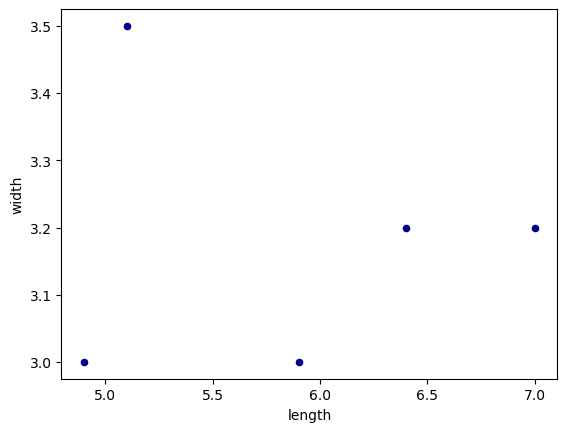

In [23]:
# lo scatterplot applicato ad un dataframe costruito per ELENCAZIONE (qui stiamo imparando)
df_sp = pd.DataFrame([[5.1, 3.5, 0], [4.9, 3.0, 0], [7.0, 3.2, 1],
                   [6.4, 3.2, 1], [5.9, 3.0, 2]],
                  columns=['length', 'width', 'species'])
display(df_sp)
df_sp.plot.scatter(x='length',
                      y='width',
                      c='DarkBlue')

In [24]:
df_bank = pd.read_csv("Credit_ISLR.csv")
df_bank.drop(columns=["Unnamed: 0","ID"],inplace=True)

<Axes: xlabel='Income', ylabel='Balance'>

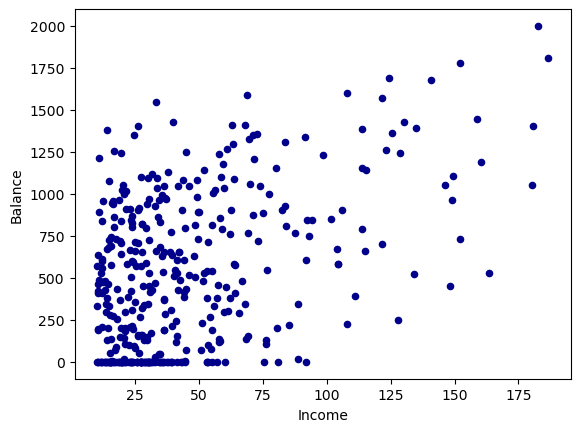

In [25]:
df_bank.plot.scatter(x='Income',
                      y='Balance',
                      c='DarkBlue')

Lo stesso scatterplot applicato ad iris, prima per il sepalo e poi per il petalo. Prima dobbiamo ricaricare *iris* e rinominare le colonne.

<Axes: xlabel='sepal length', ylabel='sepal width'>

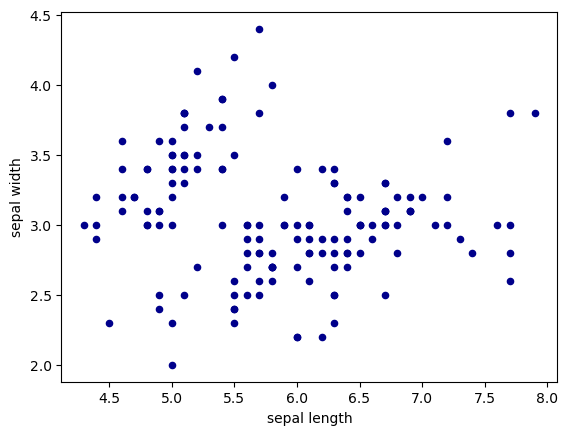

In [26]:
import numpy as np
df = pd.DataFrame(data= np.c_[iris['data'], iris['target']],               # il metodo 'DataFrame' crea il dataframe
                     columns= list(iris['feature_names']) + ['target'])
df.rename(columns={'sepal length (cm)': 'sepal length', 'sepal width (cm)': 'sepal width','petal length (cm)': 'petal length','petal width (cm)': 'petal width'}, inplace=True)

df.plot.scatter(x='sepal length',
                      y='sepal width',
                      c='DarkBlue')

<Axes: xlabel='petal length', ylabel='petal width'>

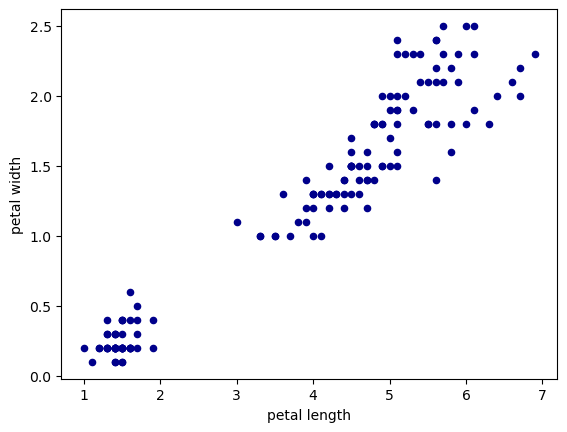

In [27]:
df.plot.scatter(x='petal length',
                      y='petal width',
                      c='DarkBlue')

Come **identificare** i punti di uno scatterplot in modo interattivo? Con [altair](https://altair-viz.github.io/):

In [28]:
# se `altair` non è ancora installato:
# !conda install -y altair  # jupyter notebook
!pip install altair

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
   ---------------------------------------- 0.0/795.4 kB ? eta -:--:--
   ---------------------------------------- 795.4/795.4 kB 8.4 MB/s  0:00:00
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)

   ---- ----------------------------------- 1/9 [narwhals]
   ---- ----------------------------------- 1/9 [narwhals]
   ---- ----------------------------------- 1/9 [narwhals]
   ------------- -------------------------- 3/9 [attrs]
   ---------------------- ----------------- 5/9 [jinja2]
   ------------------------------- -------- 7/9 [jsonschema]
   ----------------------------------- ---- 8/9 [altair]
   ----------------------------------- ---- 8/9 [altair]
   ---------------------------------------- 9/9 [altair]



In [29]:
import altair as alt
df['target'] = df['target'].astype('category')
source = df    # 'source' è un comodo (per non rischiare di alterare 'df')

alt.Chart(source).mark_circle(size=60).encode(
    x='petal length',
    y='petal width',
    color='target',
    tooltip=['sepal length','sepal width', 'petal length', 'petal width','target']
).interactive()


alt.Chart(...)

Il plot a dispersione (*scatter plot*) visualizza solo due variabili (ogni punto è una riga del dataset).<br>
Lo scatterplot è molto utile per individuare in modo visivo ed immediato **trend**, **correlazioni**, **outlier**, **cluster** nel dataset.<br>

Se il nostro dataset ha *n* variabili (colonne) il numero di scatterplot è *n(n-1)*, in questo caso con *n=3* abbiamo 6 scatterplot. Il numero di scatterplot significativo è in realtà *n(n-1)/2*, perchè il plot X vs Y è semanticamente uguale al plot Y vs X.<br>
L'insieme degli scatterplot è detto [scatterplot matrix](scatterplot_matrix.png). L'esame visivo di grandi matrici di scatterplot non è banale, e sopra un certo numero di variabili non è neanche fattibile (di più: il metodo spesso non riesce neanche a creare la matrice!).

array([[<Axes: xlabel='sepal length', ylabel='sepal length'>,
        <Axes: xlabel='sepal width', ylabel='sepal length'>,
        <Axes: xlabel='petal length', ylabel='sepal length'>,
        <Axes: xlabel='petal width', ylabel='sepal length'>],
       [<Axes: xlabel='sepal length', ylabel='sepal width'>,
        <Axes: xlabel='sepal width', ylabel='sepal width'>,
        <Axes: xlabel='petal length', ylabel='sepal width'>,
        <Axes: xlabel='petal width', ylabel='sepal width'>],
       [<Axes: xlabel='sepal length', ylabel='petal length'>,
        <Axes: xlabel='sepal width', ylabel='petal length'>,
        <Axes: xlabel='petal length', ylabel='petal length'>,
        <Axes: xlabel='petal width', ylabel='petal length'>],
       [<Axes: xlabel='sepal length', ylabel='petal width'>,
        <Axes: xlabel='sepal width', ylabel='petal width'>,
        <Axes: xlabel='petal length', ylabel='petal width'>,
        <Axes: xlabel='petal width', ylabel='petal width'>]], dtype=object)

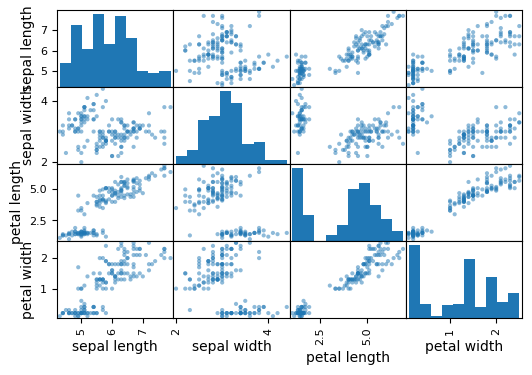

In [30]:
pd.plotting.scatter_matrix(df, figsize=(6,4))

I risultati numerici precedenti trovano conferma nella seguente immagine:


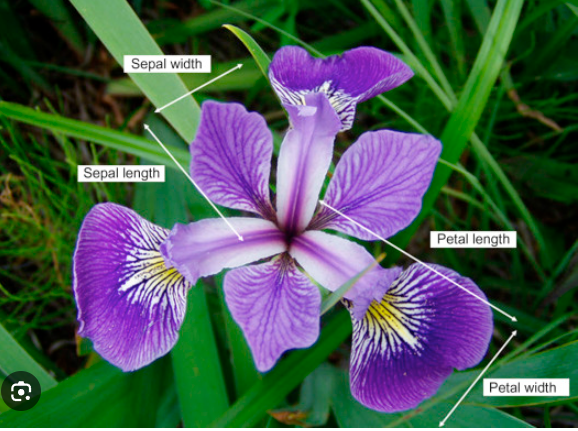

In [8]:
Image('iris_significato_2.png') if IN_COLAB else display(Image(filename='iris_significato_2.png'))

Elaborazione della scatterplot matrix (su iris):

array([[<Axes: xlabel='sepal length', ylabel='sepal length'>,
        <Axes: xlabel='sepal width', ylabel='sepal length'>,
        <Axes: xlabel='petal length', ylabel='sepal length'>,
        <Axes: xlabel='petal width', ylabel='sepal length'>],
       [<Axes: xlabel='sepal length', ylabel='sepal width'>,
        <Axes: xlabel='sepal width', ylabel='sepal width'>,
        <Axes: xlabel='petal length', ylabel='sepal width'>,
        <Axes: xlabel='petal width', ylabel='sepal width'>],
       [<Axes: xlabel='sepal length', ylabel='petal length'>,
        <Axes: xlabel='sepal width', ylabel='petal length'>,
        <Axes: xlabel='petal length', ylabel='petal length'>,
        <Axes: xlabel='petal width', ylabel='petal length'>],
       [<Axes: xlabel='sepal length', ylabel='petal width'>,
        <Axes: xlabel='sepal width', ylabel='petal width'>,
        <Axes: xlabel='petal length', ylabel='petal width'>,
        <Axes: xlabel='petal width', ylabel='petal width'>]], dtype=object)

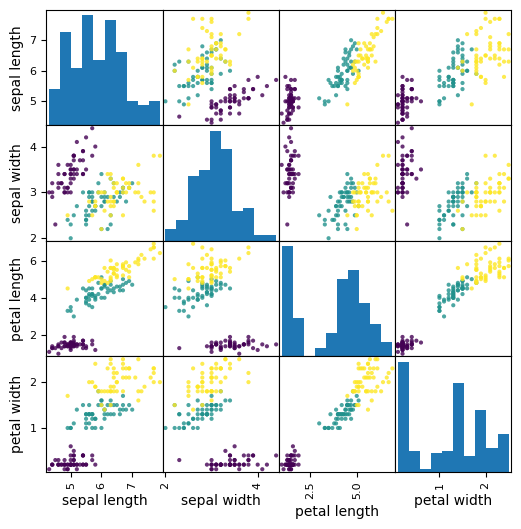

In [34]:
from pandas.plotting import scatter_matrix

columns_to_plot = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
categories = df["target"].unique()  # Get unique categories
colors = {category: i for i, category in enumerate(categories)}
scatter_matrix(df, c=df["target"].apply(lambda x: colors[x]), figsize=(6, 6), alpha=0.8)


Se lo scatterplot è molto denso, cioè pieno di punti **sovrapposti**, in pandas è disponibile il plot `hexbin`; vedi [qui](https://www.educative.io/answers/what-are-hexagonal-bin-plots-in-pandas) con login e [qui](https://stackoverflow.com/questions/66592772/how-to-create-a-hexbin-plot-from-a-pandas-dataframe).<br>
Gli scatterplot *hexbin* suddividono il plot in **regioni esagonali** ed assegnano una **intensità di colore** in base al numero di punti che cadono in quella regione.

Vediamo due esempi, il primo sul dataset bancario, il secondo su iris.

<Axes: xlabel='Income', ylabel='Balance'>

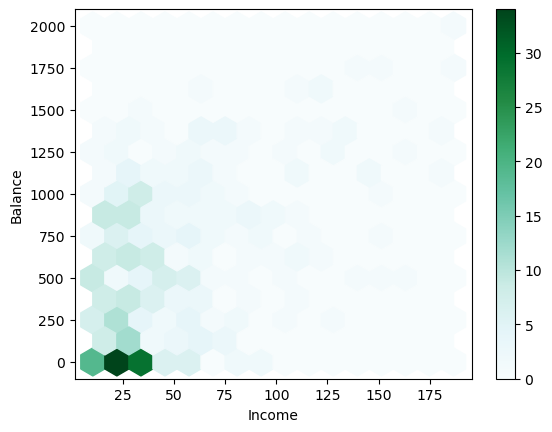

In [38]:
df_bank.plot.hexbin(x='Income',
               y='Balance',
               gridsize=15)

<Axes: xlabel='sepal length', ylabel='sepal width'>

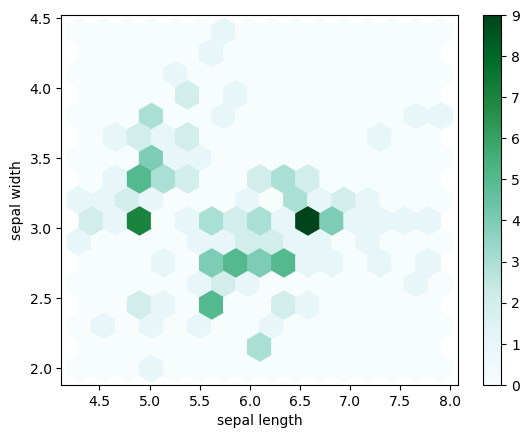

In [39]:
df.plot.hexbin(x='sepal length', y='sepal width', gridsize=15)

Vediamo ora un altro plot molto importante: il [**boxplot**](https://en.wikipedia.org/wiki/Box_plot), molto utile per analizzare la distribuzione dei valori delle singole variabili ed anche confrontare tra di loro le varie distribuzioni (se hanno la stessa unità di misura).

<Axes: >

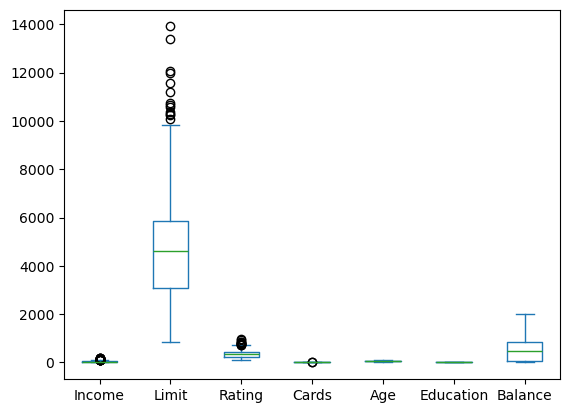

In [40]:
df_bank.plot.box()
# df_sp.boxplot()

La linea verde rappresenta la mediana (il quartile al 50%).<br>
Le due linee orizzontali della scatola (superiore ed inferiore) rappresentano il primo ed il terzo quartile.<br>
Le due linee orizzontali sopra/sotto la scatola (i "due baffi") rappresentano il minimo ed il massimo, oppure (a seconda del metodo e delle sue impostazioni) rappresentano +- IQRx1.5, dove IQR è l'interquartile range (cioè Q3-Q1) [vedi l'help del metodo  *boxplot*].<br><br>
In [questa figura](boxplot.png) la semantica più comune nei boxplot.

Il metodo `plot.box` della classe DataFrame (usato nella cella precedente) si può considerare anche come **alternativa grafica** al metodo `describe`, che produce informazioni simili (in formato tabellare).

In [41]:
df_sp['length'].describe()

count    5.000000
mean     5.860000
std      0.879204
min      4.900000
25%      5.100000
50%      5.900000
75%      6.400000
max      7.000000
Name: length, dtype: float64

A volte è molto utile confrontare fianco a fianco i boxplot delle colonne. Se le **scale** delle colonne sono molto differenti - ad esempio: unità, decine, migliaia, ecc - il box-plot comparato (cioè su tutto il dataframe) non è utile, come si vede per il dataframe `df_bank`:

<Axes: >

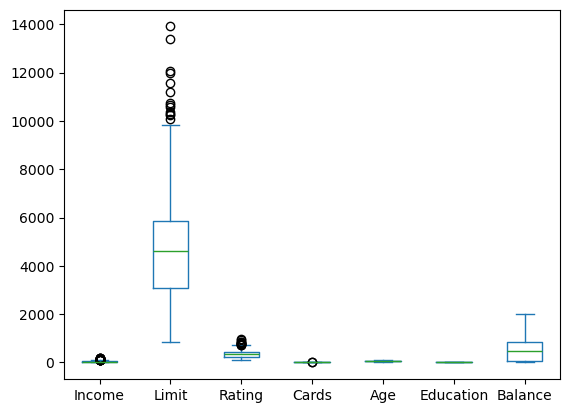

In [42]:
df_bank.plot.box()    # boxplot comparato

In questi casi occorre **standardizzare** i dati, in questo modo (vedi anche sezione apposita sulla standardizzazione, più avanti).

In [43]:
from sklearn import preprocessing                                 # un package specifico per la pre-elaborazione dei dati

std_bank = preprocessing.scale(df_bank.select_dtypes(['number'])) # solo le colonne numeriche possono essere standardizzate

In [44]:
std_bank   # il nostro dataframe standardizzato, non più comprensbile

array([[-0.86158299, -0.48999879, -0.46553881, ..., -1.2576741 ,
        -0.78492991, -0.40727698],
       [ 1.72743711,  0.82826106,  0.82870309, ...,  1.5284506 ,
         0.49658831,  0.83405596],
       [ 1.68675551,  1.01478681,  1.02931059, ...,  0.88996369,
        -0.78492991,  0.13063396],
       ...,
       [ 0.35946155, -0.24491264, -0.21963285, ...,  0.65778663,
        -0.46455035, -0.83194351],
       [-0.21280808, -0.95891584, -1.05441888, ..., -0.67723146,
        -0.1441708 , -1.13247675],
       [-0.75334493,  0.34199278,  0.38866085, ...,  0.48365384,
        -2.06644812,  0.97125591]])

In [45]:
# la verifica manuale della standardizzazione sul valore di Income del primo cliente:
(df_bank['Income'] - df_bank['Income'].mean()) / df_bank['Income'].std()   # funzionamento vettoriale di Python

0     -0.860505
1      1.725276
2      1.684646
3      2.942467
4      0.302549
         ...   
395   -0.939809
396   -0.903832
397    0.359012
398   -0.212542
399   -0.752403
Name: Income, Length: 400, dtype: float64

`std_bank`è una array numpy, non più un dataframe pandas. Ma i metodi di plot sono disponibili in pandas, cioè sono applicabili solo ai dataframe (di pandas). Dobbiamo quindi **convertire all'indietro l'array in un dataframe**.<br>
Come lo facciamo?<br>
Creando un nuovo dataframe con la funzione `pd.DataFrame` applicato all'array `std_bank`, che contiene le sole colonne numeriche (standardizzate).<br>
Problema. La funzione `scale` ha standardizzato i dati ma NON ha messo i nomi delle colonne nella array. A questo scopo utilizziamo l'argomento *columns* della funzione `pd.Dataframe` per dare un nome alle varie colonne. Questi nomi li possiamo elencare in una lista; tuttavia è più veloce e sicuro ricavarli dal dataset originario `df_bank`, prendendo solo le colonne numeriche (quelle standardizzate).<br>
I due argomenti in input alla funzione `pd.DataFrame` sono:
* `std_bank`: l'array standardizzata
* i nomi delle colonne numeriche

In [46]:
df_bank_std = pd.DataFrame(data=std_bank,columns=df_bank.select_dtypes(['number']).columns)

In [47]:
df_bank_std     # il dataframe standardizzato in formato pandas (con anche i nomi colonne e l'indice di riga)

,Income,Limit,Rating,Cards,Age,Education,Balance
0,-0.861583,-0.489999,-0.465539,-0.699130,-1.257674,-0.784930,-0.407277
1,1.727437,0.828261,0.828703,0.031032,1.528451,0.496588,0.834056
2,1.686756,1.014787,1.029311,0.761194,0.889964,-0.784930,0.130634
3,2.946152,2.068440,2.110003,0.031032,-1.141586,-0.784930,0.966900
4,0.302928,0.070012,0.013331,-0.699130,0.715831,0.816968,-0.411633
...,...,...,...,...,...,...,...
395,-0.940986,-0.275711,-0.310230,0.031032,-1.373763,-0.144171,0.087078
396,-0.904963,-0.389362,-0.381413,1.491355,0.541698,1.137347,-0.087144
397,0.359462,-0.244913,-0.219633,1.491355,0.657787,-0.464550,-0.831944
398,-0.212808,-0.958916,-1.054419,-1.429291,-0.677231,-0.144171,-1.132477


A questo punto possiamo applicare il metodo *pandas* `plot.box()` al nuovo dataframe `df_bank_std`:

<Axes: >

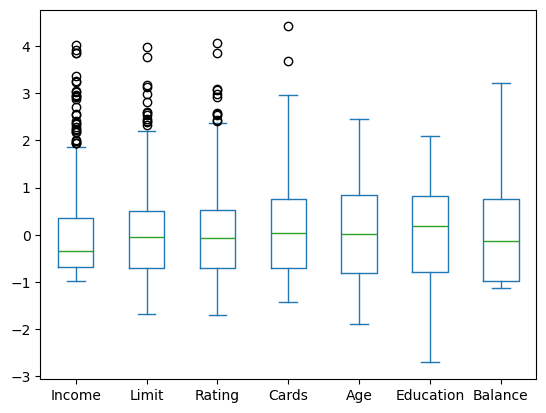

In [48]:
df_bank_std.plot.box()

In [49]:
df_bank.select_dtypes(['number']).columns

Index(['Income', 'Limit', 'Rating', 'Cards', 'Age', 'Education', 'Balance'], dtype='object')

Ecco ora il boxplot applicato ad un altro dataset, creato in modo randomico

In [50]:
# passo 1 - creazione del dataset con il package numpy:
np.random.seed(1234)                                             # seme per garantire la "riproducibilità" dei risultati
df_bp = pd.DataFrame(data=np.random.randn(10, 4),                # una matrice casuale 10x4 (gaussiana standard)
                  columns=['Col1', 'Col2', 'Col3', 'Col4'])      # i nomi delle 4 colonne (le array di numpy sono UNNAMED)
print(df_bp)

       Col1      Col2      Col3      Col4
0  0.471435 -1.190976  1.432707 -0.312652
1 -0.720589  0.887163  0.859588 -0.636524
2  0.015696 -2.242685  1.150036  0.991946
3  0.953324 -2.021255 -0.334077  0.002118
4  0.405453  0.289092  1.321158 -1.546906
5 -0.202646 -0.655969  0.193421  0.553439
6  1.318152 -0.469305  0.675554 -1.817027
7 -0.183109  1.058969 -0.397840  0.337438
8  1.047579  1.045938  0.863717 -0.122092
9  0.124713 -0.322795  0.841675  2.390961


<u>Nota su *numpy*</u>. Una array di numpy si **differenzia** da un dataframe di pandas soprattutto per tre aspetti:
* l'array contiene in genere valori **numerici**, comunque **omogenei**, mentre le colonne di un dataframe possono essere eterogenee tra loro (una colonna numerica, un'altra alfanumerica, un'altra ancora booleana, ecc)
* l'array può avere **molte dimensioni** (>= 3) (fino a 32?!), mentre il dataframe ha solo 2 dimensioni (righe e colonne)
* l'array <u>non</u> ha nomi di colonna - meglio: l'array strutturata li ha (vedi [qui](https://stackoverflow.com/questions/7037938/numpy-named-columns))

**Morale**:
- il dataframe serve a rappresentare il dataset in memoria (in genere eterogenei e bidimensionali, come una tabella SQL oppure un foglio Excel)
- l'array serve ad eseguire velocemente calcoli numerici.

<Axes: >

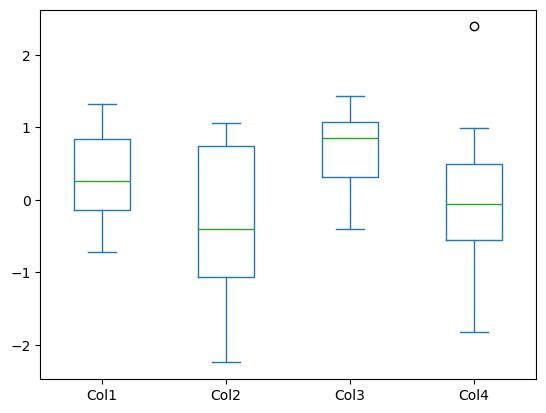

In [51]:
# passo 2: la creazione del boxplot
df_bp.plot.box()  # il boxplot di ogni colonna

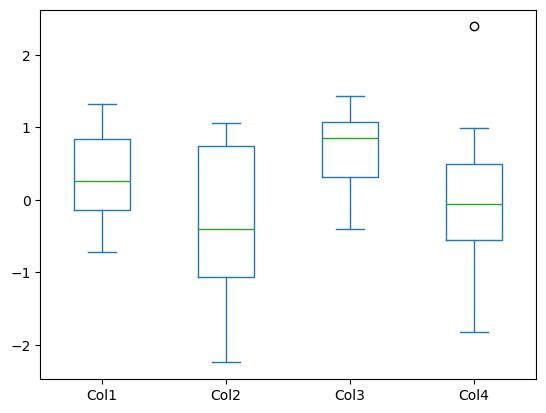

In [52]:
# lo stesso boxplot di prima, salvato e visualizzato
boxplot = df_bp.plot.box()

In [ ]:
boxplot   # --> la visualizzazione così dà errore, è un oggetto 'matplotlib' --> occorre visualizzarlo in una cella matplotlib

**NB: i boxplot in alcuni casi possono essere fuorvianti**
![](boxplot_misleading.png)<br>
Per gli istogrammi ed i plot a violino vedi più avanti.

Un altro plot interessante è il [barplot](https://en.wikipedia.org/wiki/Bar_chart) (aka, *barchart* o *bargraph*), in italiano *grafico a barre*.

In [ ]:
df_bap = pd.DataFrame({'lab':['A', 'B', 'C'], 'val':[10, 30, 20]})
df_bap.head()

In [ ]:
df_bap.plot.bar(x='lab', y='val')

In [ ]:
df_bap.plot.barh(x='lab', y='val')

Ora sul df `df_bank` (solo per colonne NUMERICHE):

In [ ]:
df_bank['Income'].plot.bar()

Ora il [line plot](https://en.wikipedia.org/wiki/Line_chart), aka *line chart* oppure *line graph*, oppure *diagramma a linea* (in italiano). E' spesso usato per analizzare l'andamento temporale di una [serie storica](https://it.wikipedia.org/wiki/Serie_storica) (aka, *time series*).

In [ ]:
df_bank['Income'].iloc[0:50].plot.line()   # applicazione in cascata di metodi
                                           # 1. subsetting di colonna Income
                                           # 2. subsetting di riga (le prime 50)

Il precedente diagramma è stato ristretto ai primi 50 clienti per mostrare meglio la presenza, nei diagrammi *plot_line*, di una linea che collega i punti. E' la semantica tipica di questi diagrammi.

**In questo caso non ha senso**. Il lineplot si usa per dati temporali.

In [ ]:
s = pd.Series([1, 3, 2, 5, 7])   # convertiamo la lista python creata, non banale da elaborare (in Python) in una serie
                                 # pandas, molto più facile da elaborare
                                 # spesso una serie è chiamata 's' (come un dataframe 'df')
s.plot.line()

 Ovviamente il diagramma a linea può essere applicato anche ad una colonna del dataframe, nel seguente modo:

In [ ]:
df['sepal length'].plot.line()     # il metodo 'plot.line' applicato ad una singola colonna di iris
                                   # (una serie, come si evince dal subsetting fatto con [])

I line-plot si possono applicare a qualsiasi colonna numerica; tuttavia, essi hanno senso su colonne cronologiche, nelle quali il **campo data-ora è l'indice primario**: gli ordini degli ultimi 3 mesi, l'andamento azionario dell'ultimo anno (dette *serie storiche*). Nei dataset sinora visti (*iris* e *Credit*) NON ci sono colonne di questo tipo.

In [ ]:
df_bank['Age'].plot.line()   # --> NON ha significato applicativo

In [ ]:
df.plot.line() # il metodo 'plot.line' è disponibile anche per i dataframe

Ora il plot [a torta](https://it.wikipedia.org/wiki/Diagramma_a_torta), che si fa su **colonne categoriche** (cioè partizionabili in "fette").

In [ ]:
df_bank_2 = df_bank.copy()
df_bank_2['Ethnicity'] = df_bank_2['Ethnicity'].astype("category")
df_bank_2['Ethnicity'].value_counts().plot.pie(autopct='%1.1f%%')

Vogliamo ora creare un pie-chart su una colonna del dataframe `df_bank`, con ilpackage *matplotlib*. Utilizziamo un codice generato da chatGPT che utilizza il package `matplotlib` (non sembra possibile in pandas).

In [ ]:
import matplotlib.pyplot as plt

# Count the number of occurrences for each unique value in the "Cards" column
cards_counts = df_bank['Cards'].value_counts()

# Create a pie chart for the "Cards" column
plt.figure(figsize=(15, 12))     # le dimensioni del plot
plt.pie(cards_counts, labels=cards_counts.index, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title('Distribuzione della colonna Cards')
plt.axis('equal')  # Equal aspect ratio ensures the pie chart is circular.
plt.show()


E per finire [l'istogramma](https://it.wikipedia.org/wiki/Istogramma), che rappresenta la distribuzione della variabile.

In [ ]:
np.random.seed(0)                   # imposta il seme (seed) del generatore di numeri pseudo-casuali di numpy
s = np.random.normal(size=1000)     # genera 1000 osservazioni estratte casualmente da una distribuzuzione gaussiana standard
pd.Series(s).hist(bins=11)         # converte l'array 1D di numpy in una serie di pandas e poi la plotta con un istogramma

                                    # al crescere del 'size' la forma dell'istogramma è sempre più simile a quella di una
                                    # distribuzione gaussiana standard.

In [ ]:
df_bank['Income'].hist(bins=10)

L'istogramma fornisce molte informazioni sulla distribuzione della variabile, ad esempio la centratura, la variabilità, la simmetria, eventuali outlier.

<u>Quanti bins</u> dobbiamo chiedere? Due regole:
* da **5 a 20** (MAI BIN VUOTI): prof. Brandimarte (PoliTO)
* **1 + (10/3*log10(n))** (con n=num. osservazioni): prof.ssa Vicario (PoliTO) --> con n= 400 --> 1 + (10/3 * 3) = 10.

In [ ]:
n = df_bank.shape[0]
1 + ((10/3) * np.log10(n))

**Limiti degli istogrammi** --> KDE oppure plot a violino

In [ ]:
from IPython.display import IFrame
IFrame("Use Histograms with Caution.pdf", width=1000, height=600)

In [ ]:
# la kernel density estimate (pandas ha il metodo)
df_bank['Income'].plot.kde()

**Istogramma vs boxplot**<br>
Entrambi i plot forniscono informazioni sulla **distribuzione** della variabile. Un boxplot consente di identificare i [**quantili**](https://it.wikipedia.org/wiki/Quantile) meglio degli istogrammi, mentre un istogramma permette di visualizzare la forma complessiva dei dati meglio del boxplot.

Come alternativa (migliorativa?) all'istogramma, si può fare il *violin plot*, che cumula il boxplot con la kernel density:

In [ ]:
# il plot a violino --> serve seaborn
import seaborn as sn
sn.violinplot(df)

L'[elenco](https://sparkbyexamples.com/pandas/how-to-generate-line-plot-in-a-dataframe/) dei plot principali in pandas (in grassetto quelli visti prima):
* **line** - line plot (default)
* **bar** - vertical bar plot
* barh - horizontal bar plot
* **hist** - histogram
* **box** - boxplot
* kde - Kernel Density Estimation plot
* density - same as ‘kde’
* area - area plot
* **pie** - pie plot
* **scatter** - scatter plot (DataFrame only)
* **hexbin** - hexbin plot (DataFrame only)

**Quale plot scegliere**? Dipende dal messaggio che vogliamo veicolare. Due buone guide sono [questa](choosing-a-good-chart.pdf) e [questa](chart-chooser.jpg).<br>
Vedi anche questa guida:
![](guide_to_visuals.png)

Il plotting in pandas è limitato ai plot base. Per fare grafica avanzata occorre usare i packake `matplotlib` e `seaborn`

Interessanti **variazioni** di questi plot pandas sono mostrati nel notebook **matplotlib**.

2 utili link:
- [Un'introduzione al plotting con pandas](https://neptune.ai/blog/pandas-plot-deep-dive-into-plotting-directly-with-pandas).

- [Lollipop chart con python](https://www.analyticsvidhya.com/blog/2021/06/lollipop-charts-advanced-data-visualization-in-python/).

## Sparklines con pandas
Vedi [qui](https://towardsdatascience.com/6-things-that-you-probably-didnt-know-you-could-do-with-pandas-d365b3362a55) e [qui]().

In [ ]:
# 1. import dei package
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from base64 import b64encode
from io import BytesIO
from IPython.display import HTML
%matplotlib inline

# 2. creazione di un dataset dummy:
n = 100
data = [
    ('Bitcoin',   40000*np.random.rand(n).round(2)),
    ('Ethereum',   2000*np.random.rand(n).round(2)),
    ('BNB',     500*np.random.rand(n).round(2)),
    ('Litecoin',   150*np.random.rand(n).round(2)),
]
df2 = pd.DataFrame(data, columns=['Name', 'Price History'])
df2.head()

# 3. definzione della funzione che crea la sparkline
def create_line(data, **kwags):

    # Convert data to a list
    data = list(data)

    # Create a figure and axis object with given size and keyword arguments
    fig, ax = plt.subplots(1, 1, figsize=(3, 0.25), **kwags)

    # Plot the data
    ax.plot(data)

    # Remove the spines from the plot
    for k,v in ax.spines.items():
        v.set_visible(False)

    # Remove the tick marks from the x and y axes
    ax.set_xticks([])
    ax.set_yticks([])

    # Plot a red dot at the last point of the data
    plt.plot(len(data) - 1, data[len(data) - 1], 'r.')

    # Fill the area under the plot with alpha=0.1
    ax.fill_between(range(len(data)), data, len(data)*[min(data)], alpha=0.1)

    # Close the plot to prevent displaying it
    plt.close(fig)

    # Save the plot image as png and get its binary data
    img = BytesIO()
    fig.savefig(img, format='png')
    encoded = b64encode(img.getvalue()).decode('utf-8')

    # Return the encoded image data as an HTML image tag
    return '<img src="data:image/png;base64,{}"/>'.format(encoded)

# 4. creazione della sparkline
df2['Price History Line']  = df2['Price History'].apply(create_line)
HTML(df2.drop(columns = ["Price History"]).to_html(escape=False))

## Il subsetting di pandas
**accesso**: *slicing*, *subsetting*, *indexing*: termini sostanzialmente equivalenti per indicare un **sottoinsieme di righe e/o colonne di un dataframe**.<br>
Finora abbiamo visto esempi di subsetting di colonna, non ancora di riga.<br>
![](slicing.png)
Ci sono diversi metodi in Pandas per fare subsetting di **riga**:
* il [metodo di BASE](https://stackoverflow.com/questions/16096627/selecting-a-row-of-pandas-series-dataframe-by-integer-index)
* **loc**
* iloc

Secondo DMBA: il metodo *loc* è più generale e permette di accedere alle righe usando le label; il metodo *iloc*, d'altra parte, permette di usare solo numeri interi.<b>

Ci sono alcune inconsistenze; ad esempio: *iloc* esclude l'estremo superiore del range 0:9 (secondo la convenzione generale di Python); al contrario, il metodo *loc* lo include.

NB. Altri pacchetti Python (ad esempio `numpy`) utilizzano (purtroppo) altri metodi di subsetting.
La libreria `scikit-learn` (di Machine Learning), ma anche altre librerie, spesso traducono il formato dei dati in ingresso da pandas a numpy (es. array di numpy). Perciò è necessario conoscere anche il subsetting di *numpy*.

In [ ]:
df3 = pd.DataFrame([['Roy', 25, 50000],
                   ['Bob', 30, 60000],
                   ['Joe', 35, 70000]],
                   columns = ["Names", "Age", "Salary"])
caption = 'This is a caption'

df3.style.set_caption(caption)

### Il metodo base

Vediamo rapidamente il **metodo base**: prima il subsetting di <u>riga</u> (con indici posizionali) e poi di <u>colonna</u> (con le label di colonna).

In [ ]:
df3 # per tenerlo in vista

#### Subsetting con metodo base - di riga (varie righe, non una singola)

In [ ]:
df3[1:] # i casi dal quinto fino alla fine del dataset.
# --> Ci sono delle righe con ... (non visualizzate) perchè è un subset troppo grande.

In [ ]:
df4 = df3[4:]     # ovviamente nelle copie dati, sono copiati TUTTE le righe.
df4

In [ ]:
df3[1:3] # da 1 a lenght-1 (so 16096627)

In [ ]:
df3[::2] # i casi uno sì ed uno no

In [ ]:
# --> non è possibile selezionare una sola riga! è una inconsistenza del metodo di base, occorre usare il metodo .iloc, vedi
#     più avanti (so 16096627)

#### Subsetting con metodo base - di colonna

In [ ]:
# con [label] selezioniamo una colonna come SERIE (un'altra struttura di pandas). Notare l'uso di [] anzichè di [[]].
df3['Age'] # label colonna

In [ ]:
type(df3['Age']) # è una Series (la serie è "simile" al vettore di R, creabile ad esempio con c(...))

> <u>Attenzione</u>:<br>
> *When you use a list containing a single column name, ['column_name'], pandas returns a **DataFrame**. This is because you are explicitly passing a list to select columns. Even if the list contains only one column name, the result is **still a DataFrame**, as pandas assumes that you might want to select multiple columns. The result is consistent with pandas' design philosophy of handling column selection in a uniform way.* (da [questa chat](https://chatgpt.com/share/e435d30f-1412-4455-927f-c09d8ecc5d04) di chatGPT).<br>
> Vedi infatti questi differenti codici; il caso 4. è quello che può **confondere**:

In [ ]:
# 1. subset diretto per nome-colonna:
print(type(df3['Age']), df3['Age'].shape)              # --> una series pandas 1D - OK!

# 2. subset per variabile definita SENZA le []:
var_name = 'Age'    # <-- OK!
print(type(df3[var_name]), df3[var_name].shape)        # --> una series pandas 1D - OK!

# 3. subset diretto o per variabile con le DOPPIE []:
var_name = 'Age'    # <-- OK!
print(type(df3[[var_name]]), df3[[var_name]].shape)    # --> un dataframe pandas 2D - OK!
                                                       # è coerente con il subsetting multi-colonnna:
                                                       # df[['Age','Salary']] - vedi più aventi

# 4. subset per variabile definita CON le []:
var_name = ['Age']  # <-- ??
print(type(df3[var_name]), df3[var_name].shape)        # --> un dataframe pandas 2D - perchè la variabile 'var_name' è
                                                       #     stata definita con le [] ed il subsetting di 'df3' è fatto
                                                       #     anch'esso con le [] --> si ricade nel caso 3! delle doppie [[]]

Torniamo al dataframe iris:

In [ ]:
print(df['sepal length'])              # la serie (indice e valori)
print('\n',df['sepal length'].values)  # i valori della serie (in formato array di numpy)
print('\n',df['sepal length'].index)   # il range dell'indice della serie

In [ ]:
help(pd.Series())

In [ ]:
len(df['sepal length'])    # lunghezza della serie

In [ ]:
df['sepal length'].shape   # la stessa cosa

In [ ]:
df[:2].shape               # si agisce sul dataframe che ha comunque due dimensioni (è solo un subset)

In [ ]:
df[['sepal length']] # estrazione colonna per nome (con la modalità dataframe: [[]]);
                     # riporta solo le prime ed ultime osservazioni;
                     # sia l'indice che i valori della colonna del df

In [ ]:
type(df[['sepal length']]) # oggetti differenti (dataframe o series, in questo caso) hanno metodi differenti associati

In [ ]:
type(df['sepal length'])

In [ ]:
print(df[['sepal length']].values) # estrazione colonna per nome (con la modalità dataframe: [[]]);
                                   # riporta TUTTE le osservazioni (senza interruzioni ...)

In [ ]:
df.target                   # comoda alternativa se il nome colonna NON contiene spazi o caratteri particlari

In [ ]:
df.sepal_length            # comoda alternativa se il nome colonna NON contiene spazi o caratteri particolari.
                           # così non funziona --> ERRORE!

In [ ]:
print(df['sepal length'].index)  # il range dell'indice della serie

In [ ]:
df[['sepal length']].head(2) # solo le prime due righe (di quella colonna)

In [ ]:
df[['sepal length', 'sepal width']] # 2 colonne (in modalità dataframe, necessariamente)

In [ ]:
df['sepal length', 'sepal width']  # --> dà ERRORE!

#### Combinazione di subsetting di colonna con subsetting di riga (con metodo base)

In [ ]:
df['sepal length'][2] # selezioniamo un caso (2) di una variabile (sepal length)

In [ ]:
df['sepal length'][0:10] # le prime 10 righe di una determinata colonna

Il subsetting multi-colonna sideve fare con le [[]]

In [ ]:
df[['sepal length', 'sepal width']]   # --> OK!

In [ ]:
df['sepal length', 'sepal width']     # --> NON funziona!

In [ ]:
df[['sepal length', 'sepal width']][0:2] # le prime 2 colonne delle prime 2 righe

In [ ]:
df[['sepal length', 'sepal width']][0] # NON funziona! (come detto prima: col metodo base di subsetting di Pandas NON è
                                       # possibile estrarre una sola riga)

Il subsetting di **una singola riga** con il metodo base PUO' essere fatto in questo modo:

In [ ]:
df[1:2]

### I metodi loc ed iloc

Il subsetting della **singola** riga è fattibile con il metodo `loc`oppure `iloc`:

In [ ]:
df.loc[2]

**Breve confronto `loc` vs `iloc`**:
* il metodo loc è più generale e permette di accedere alle righe tramite le label; loc include l'ultimo elemento del range specificato, a differenza di numpy e del metodo iloc;
* il metodo iloc permette di accedere alle righe solo tramite gli interi

In [ ]:
print(df.loc[0:3])    # le prime 4 righe (da 0 a 3)
print(df.iloc[0:3])   # le prime 3 righe (da 0 a 2) - comportamento standard di python

# NB. loc ed iloc, se la selezione è resa persistente, fanno perdere i nomi delle variabili.

In [ ]:
# selezione di un solo caso (riga) - non era possibile col metodo base di pandas
df.iloc[0,:] # tutte le colonne del caso 0

In [ ]:
# .iloc (usa l'indice intero riga colonna) - sintassi COERENTE con quella di numpy per il subsetting delle array

In [ ]:
df.iloc[:,2] # tutti i valori della colonna 3 (l'opposto di prima)

In [ ]:
df.iloc[0,2] # un SINGOLO elemento: df.iloc[row_indexer,column_indexer]df1.iloc[0,2] # un SINGOLO elemento: df.iloc[row_indexer,column_indexer]

In [ ]:
df.iloc[0,20] # IndexError --> out of bounds (errore voluto)

In [ ]:
df.iloc[0:2,2] # un insieme di righe (consecutive) da 0 a length-1 (solo colonna 2, cioè petal length, la terza!)

In [ ]:
df.iloc[:2,2]  # stessa cosa

In [ ]:
df.iloc[0,0:3] # un insieme di colonne (consecutive) del caso 0

In [ ]:
df.iloc[[4,3,0],2] # un insieme di righe non consecutive (solo colonna 2)

In [ ]:
df.iloc[1] # un solo indice è interpretato come indice di riga (a differenza di altri linguaggi di ML, ad es. R)

### Subsetting tramite operatori di confronto e booleani

In [ ]:
vet = df['sepal length'] > 5  # vettore di booleani (a seconda che la condizione sia soddisfatta oppure no per quella riga)

In [ ]:
df[vet] # tutti i casi con sepal length > 5 - subsetting di base
# molto interessante! è un subsetting di riga tramite check su colonna!

In [ ]:
# alternativa molto usata (ad esempio da Hwang) con subsetting di tipo .loc
df.loc[df['sepal length'] > 7] # tutti i casi con height > 7

In Python e pandas si può spesso fare *piping*, la concatenazione degli operatori:

In [ ]:
df[df['sepal length'] > 5]   # --> lo STESSO risultato di prima

In [ ]:
# come sopra ma con =:
df.loc[df['sepal length'] == 7.1] # tutti i casi con height = 7.1

In [ ]:
# concatenazione di colonne non-consecutive in un nuovo df (DMforBA, p. 24)
pd.concat([df.iloc[4:6,0],df.iloc[4:6,3]],axis=1) # combina la colonna 1 dei casi 5 e 6 con la colonna 4 dei medesimi casi.
                                                  # 'axis' specifica la dimensione lungo la quale la concatenazione avviene.
                                                  # 0 righe - 1 colonne.

In [ ]:
# Subsetting BOOLEANO
sample_arr = [True, False]
bool_arr = np.random.choice(sample_arr, size=df.shape[0])
print(bool_arr)
df[bool_arr]

In [ ]:
# drop
df.drop(columns=['sepal length'])

Vedi anche [questo post](https://www.kdnuggets.com/2019/06/select-rows-columns-pandas.html?__s=o7u740my87lkp9nksy5d&utm_source=drip&utm_medium=email&utm_campaign=Building+an+image+classifier&utm_content=Building+an+image+classifier) (*How to Select Rows and Columns in Pandas Using [ ], .loc, iloc, .at and .iat*).

## Varie su pandas
* **Pandas vs SQL**: Most common Pandas operations and their SQL translations in one frame.
Vedi [qui](pandas_vs_sql.png)<br><br>
* [**From SQL to pandas**](https://www.linkedin.com/feed/update/urn:li:activity:7128726669384716288?utm_source=share&utm_medium=member_desktop)<br><br>
* [**Streamline Data Manipulation with pandas in Python**](https://www.linkedin.com/feed/update/urn:li:activity:7080531426844008449?utm_source=share&utm_medium=member_desktop)**<br><br>
* [**Removing duplicates in pandas**](https://www.linkedin.com/feed/update/urn:li:activity:7129022933024260096?utm_source=share&utm_medium=member_desktop)<br><br>
* [**Le 10 funzioni più importanti di pandas**](https://www.kdnuggets.com/10-essential-pandas-functions-every-data-scientist-should-know)<br><br>
* [**Python Pandas - from  basics to advanced**](https://www.linkedin.com/feed/update/urn:li:activity:7133049514407419904?utm_source=share&utm_medium=member_desktop)<br><br>
* [**Guida informale in italiano su Pandas**](https://www.linkedin.com/posts/vittorio-gambino_pandas-se-si-vuole-lavorare-con-i-activity-7144257983642861570-k3NA?utm_source=share&utm_medium=member_desktop). Anche direttamente [qui](https://colab.research.google.com/drive/17WvsYIIWx2plpP4DqrLdS6l15BB5jig6?usp=sharing)<br><br>
* [**pandas - crash course tramite infografica**](pandas_crash_course.pdf)<br><br>

## Nvidia per pandas

[**pandas 150 volte più veloce con NVIDIA?**](https://www.linkedin.com/posts/ultanorourke_ai-analytics-datascience-activity-7150474050660659200-Bvc_?utm_source=share&utm_medium=member_desktop); vedi anche direttamente [qui](https://colab.research.google.com/drive/12tCzP94zFG2BRduACucn5Q_OcX1TUKY3)

In [ ]:
!nvidia-smi

## Aggiungere *caption* ad un dataframe pandas
Anzichè nuove celle Jupyter - da [qui](https://towardsdatascience.com/6-things-that-you-probably-didnt-know-you-could-do-with-pandas-d365b3362a55).

In [ ]:
df5 = pd.DataFrame([['Roy', 25, 50000],
                   ['Bob', 30, 60000],
                   ['Joe', 35, 70000]],
                   columns = ["Names", "Age", "Salary"])

caption = 'This is a caption'

df5.style.set_caption(caption)

## Leggere file CSV
Ancorchè Jupyter Notebook possa caricare in memoria **qualsiasi tipo di file** (xml, json, PDF, txt, ecc) ed accedere a **qualsiasi tipo di database** (Oracle, SQLServer, MySQL, ecc), il formato più semplice ed efficiente da caricare (in un df pandas) è il [**CSV**](https://it.wikipedia.org/wiki/Comma-separated_values).<br>

Nel ML/AI raramente siamo interessati alla fotografia dei dati in tempo reale. In genere sia le analisi (EDA) che i modelli (predittivi) - i due obiettivi tipici del ML/AI - sono fatti su dati **passati (congelati)**, sia perchè manca l'interesse sui dati recentissimi sia perchè i dati in input ai modelli devono essere preprocessati (controllo qualità, gestione outlier, gestione MV, gestione duplicati, standardizzazione, ecc). Quindi, sebbene Python/pandas siano in gradi di accedere **direttamente** a tabelle SQL remote (tramite i metodi `pd.read_sql_query` per le query e `pd.read_sql_table` per il download dell'intera tabella), tuttavia è molto più veloce caricare i dati da un file esterno locale, che può essere di vari formati (csv, json, parquest, ecc).

**4 note tecniche sul formato CSV**:
* i due argomenti principali del metodo pandas `read_csv` sono  `sep`, che indica il carattere usato nel file per "separare" le colonne (in genere è "," oppure il ";") e `header`, che indica la presenza (e l'eventuale numero) di righe di heading (intestazione).
* ci sono diversi formati csv disponibili da excel; occorre scegliere quello indicato in figura sottostante con la freccia rossa
  ![](tipi_CSV.png)
* [pro e contro](https://towardsdatascience.com/why-i-stopped-dumping-dataframes-to-a-csv-and-why-you-should-too-c0954c410f8f) del formato csv
* un ottimo notebook di [illustrazione dei vari argomenti](https://github.com/nikitaprasad21/ML-Cheat-Codes/blob/main/Data-Gathering/CSV-(Comma-Separated-Values)-Files/csv_file_cheatcodes.ipynb) per `pd.read_csv`

In [ ]:
df_credit = pd.read_csv("Credit_ISLR.csv",header=0)
df_credit

In [ ]:
help(pd.read_csv)

Al contrario, per aprire un file CSV in Excel fare così:
* scheda `Dati`
* bottone in alto a sx `Recupera dati`
* nella preview fare le eventuali modifiche (al caricamento) e poi premere il bottone "Carica" in basso a dx

La funzione `pd.read_csv` fa un **mapping** automatico dei dati CSV in pandas, come qui descritto:
![](how_pandas_infers_CSV_datatypes.png)

Per quanto riguarda le **prestazioni dei vari formati** (come occupazione in memoria, salvtaggio su disco e apertura /lettura) vedi il seguente utile studio.

Il messaggio chiave dello studio è che:
- il formato CSV è molto meglio di excel (neanche preso in considerazione nella comparazione), è disponibile in tutti gli ambienti di *data management*
- per big data (come vedremo) il formato migliore è il parquet, soprattutto nella occupazione di memoria.

In [ ]:
from IPython.display import IFrame
IFrame("I_O Optimization in Data Projects - by Avi Chawla.pdf", width=1000, height=600)

## Calcoli numerici in *pandas*
*pandas* è ottimo per la gestione dei dataframe, *numpy* per i calcoli numerici.<br>
Diversi metodi di *pandas* che richiedono **calcoli numerici** (ad es. standardizzazione, calcolo correlazione, ecc) ricevono in ingresso un *dataframe* e restituiscono *un'array* di *numpy* (non necessariamente da riconvertire in *pandas*).<br>
Occorre perciò <u>conoscere i data-type di entrambi i package</u> (*pandas* e *numpy*) e sapere come <u>convertirli</u> da uno all'altro.

Conversione da **array** numpy a **dataframe** pandas:

In [ ]:
n = 5
np_arr = np.identity(n)        # la matrice identità con 1 sulla diagonale
display(type(np_arr))
pd_df = pd.DataFrame(np_arr)   # la conversione da numpy a dataframe pandas
type(pd_df)

Conversione da **dataframe** pandas ad **array** numpy (vedi anche [qui](https://stackoverflow.com/questions/13187778/convert-pandas-dataframe-to-numpy-array)):

In [ ]:
# prima possibilità, frequente ma sconsigliata perchè non è il modo migliore:
display(type(pd_df.values))

# seconda possibilità (la migliore)
display(type(pd_df.to_numpy()))

## Gestione delle classi rare
Un problema frequente nel ML: per alcune classi rare non ci sono abbastanza righe perchè l'algoritmo le impari.<br>
Una delle possibili soluzioni è la seguente:
![](rare_classes.png)

In [ ]:
data = {'color': ["red","blue","red","green","yellow","yellow","red","black","violet","green","green"]}
df = pd.DataFrame(data)

In [ ]:
!conda install -y feature_engine

In [ ]:
from feature_engine.encoding import RareLabelEncoder
rare_encoder = RareLabelEncoder(tol=0.1,n_categories=5,variables='color')
df_encoded = rare_encoder.fit_transform(df)
df_encoded

## Limiti di pandas

Vedi [qui](https://www.linkedin.com/feed/update/urn:li:activity:7128997415050772480?utm_source=share&utm_medium=member_desktop).<br>

E qui:<br>
![](pandas_costly_iteration.png)

accelerare alcune operazioni di pandas con [**Modin**](https://towardsdatascience.com/how-to-speed-up-pandas-with-modin-84aa6a87bcdb)<br>![](modin_rather_than_pandas.png)

> `pandas` è comunque un eccellente ed usatissimo package (la prima scelta per gestire dataset tabellari).<br>


## Python vs R

## Profiling
Esistono diversi pacchetti per profilare i dati (cioè analizzarli in vari modi) in modo veloce e completo.

### ydata-profiling
Il seguente codice NON funziona su *Google Colab*, vedi [qui](https://colab.research.google.com/github/Data-Centric-AI-Community/awesome-data-centric-ai/blob/master/medium/data-profiling-tools/notebooks/ydata_profiling_demo.ipynb) per importare / eseguire *ydata-profiling* in Google Colab. <br>

Il package `ydata_profiling` è installabile sull'ambiente virtuale `base` ma non su `myenv`(a causa di alcuni conflitti). Occorre perciò utilizzare il kernel associato all'ambiente virtuale `base`, e cioè `Python 3 (ipykernel)`.

In [ ]:
!pip install ydata_profiling

In [ ]:
import ydata_profiling
print(ydata_profiling.__version__)

In [ ]:
# installazione di un package spesso necessario
!conda install -c conda-forge ipywidgets -y

In [ ]:
from ydata_profiling import ProfileReport

In [ ]:
import pandas as pd
df = pd.read_csv("Credit_ISLR.csv")
df.drop(columns=['Unnamed: 0','ID'],inplace=True)

In [ ]:
df.head()

In [ ]:
profile = ProfileReport(df)
profile

### Great Tables

Il **post di Nardini** sulle *great tables*:<br>
![](great_tables_nardini.png)

Vedi [qui](https://posit-dev.github.io/great-tables/articles/intro.html).

In [ ]:
!pip install great_tables   # conda NON trova questo package!!

In [ ]:
from great_tables import GT
from great_tables.data import sp500

In [ ]:
start_date = "2010-06-07"
end_date = "2010-06-14"

In [ ]:
# tempo di esecuzione sul mio PC (RAM 16GB, CPU 4GHz): 1.5 minuti.
# la funzione GT sopra importata è applicata al dataframe specificato in parentesi (qui, sp500), seguono poi
# istruzioni di formattazione.
(
    GT(sp500)
    .tab_header(title="S&P 500", subtitle=f"{start_date} to {end_date}")
    .fmt_currency(columns=["open","high","low","close"])
    .fmt_date(columns="date", date_style="wd_m_day_year")
    .fmt_number(columns="volume", compact=True)
    .cols_hide(columns="adj_close")
)

### *skimpy*
E' una funzione <u>basata su Jupyter</u> che fornisce una **sintesi** del dataframe standard e completa. Include le dimensioni, i data type di colonna, le statistiche di colonna, le distribuzioni di colonna, le statistiche sui valori mancanti. Ad esempio:<br>
![](skimpy.png)
Come si vede, inoltre, la sintesi è <u>raggruppata per data-type</u> per un'analisi più veloce.
<br>
La pagina github è [questa](https://github.com/aeturrell/skimpy).

In [ ]:
!pip install skimpy --user

In [ ]:
!conda install -c conda-forge skimpy -y  # NON funziona

In [ ]:
from skimpy import skim   # NON funziona

In [ ]:
skim(df_bank)

### SummaryTools
Genera una sintesi del dataframe in formato standard:
![](SummaryTools.png)
Definito [qui](https://github.com/aeturrell/skimpy).

In [ ]:
!pip install summarytools --user

In [ ]:
from summarytools import dfSummary

In [ ]:
dfSummary(df_bank)

Può anche creare sinossi di vari dataframe, ognuno sotto un *tab* differente:

In [ ]:
df2 = pd.read_csv('german_credit_data.csv')
from summarytools import tabset
tabset({
    'df: ': dfSummary(df).to_html(),          # ho sostituito il metodo 'render' del post di Avi Chawla con
                                              # il metodo 'to_html' (so 76375016)
    'df2: ': dfSummary(df2).to_html()})       #  "    "

### profilazione di un dataframe nello stile di *tableau*
Vedi [questo post](https://www.linkedin.com/feed/update/urn:li:activity:7194362340446785538?utm_source=share&utm_medium=member_desktop) di Linkedin su *PyGWalker*.

## Save di un dataframe

## What Happens When You Append Rows to a Pandas DataFrame

In [ ]:
from IPython.display import IFrame
IFrame("What Happens When You Append Rows to a Pandas DataFrame.pdf", width=1000, height=600)

# *numpy*
Il pacchetto per il calcolo scientifico di base, estendibile con il pacchetto gemello ***scipy*** che si appoggia su numpy stesso.<br><br>Il principale oggetto di numpy sono le **ndarray** (n-dimensional array), più semplicemente chiamate <u>array</u>. Sono usate per rappresentare <u>vettori</u> (1D), <u>matrici</u> (2D) e <u>tensori</u> (3D+). Gli 0D-array sono <u>scalari</u> (cioè numeri).<br><br>
numpy è indispensabile da conoscere, è utilizzato per la gestione delle strutture numeriche, molti algoritmi di scikit-learn (e non solo) restituiscono un'array numpy a fronte di un dataframe pandas in input.<br><br>
*dataframe di pandas vs array di numpy*:
* il dataframe è sempre 2-dim, mentre l'array è n-dim, dove n=0,1,2,3,ecc
* il dataframe è eterogeneo (le colonne possono avere data type differenti), l'array ha sempre valori omogenei (in genere numeri ma anche booleani, oggetti, ecc - sebbene più raramente)
* anche l'array numpy PUO' avere le etichette di riga e/o colonna

**Metodi numpy più usati**<br>
![](numpy_methods_most_used.png)

In [ ]:
import numpy as np            # np è l'abbreviazione convenzionale per numpy
import scipy as sp            # sp è l'abbreviazione convenzionale per scipy

## Creazione di array numpy

In [ ]:
print(np.array(2))                   # --> si ottiene uno scalare (0D-array)
print(np.array(2,ndmin=1))           # --> si ottiene un vettore (1D-array)
print(np.array(2,ndmin=2))           # --> si ottiene una matrice (2D-array)
                                     # in tutti e tre i casi l'array è costituita da un SOLO numero.

In [ ]:
v1 = np.array(2,ndmin=2)
print(np.shape(v1))           # 2 dimensioni
print(v1.size)                # 1 sola cella!

In [ ]:
print(np.array([1,2,3],ndmin=0))     # un vettore con tre componenti
print(np.array([1,2,3]))             # idem
                                     # cioè, indipendentemente da 'ndmin', ora, per crare un vettore si elencano dentro le
                                     # parentesi quadre tutti gli elementi.

In [ ]:
a = np.array([1,2,3],ndmin=2)        # una matrice 1x3; è necessario per moltiplicare il vettore (colonna) con una matrice
np.shape(a)

In [ ]:
print(np.array([[1,2,3],
          [4,5,6]],
          ndmin=1))             # una matrice 2x3

print(np.array([[1,2,3],
          [4,5,6]]))            # una matrice 2x3
                                # cioè, indipendentemente da 'ndmin', per crare una matrice si elencano dentro le parentesi
                                # quadre tutti i vettori [..].

In [ ]:
a = np.array([[1,2,3],
            [4,5,6]],
            ndmin=3)
np.shape(a)

## Funzioni di creazione utili

In [ ]:
n = 5
np.identity(n)   # la matrice identità con 1 sulla diagonale

In [ ]:
n = 3
m = 5
np.eye(n,m,k=0)

In [ ]:
np.random.rand(n,m)       # una matrice di numeri pseudo-casuali (ognuno estratto da una distribuzione uniforme standard)

## Metodi ed attributi di un'array numpy

In [ ]:
a = np.array([[1,2,3],
          [4,5,6]])
a

In [ ]:
a.shape         # le dimensioni dell'array

In [ ]:
a.ndim          # il numero di dimensioni dell'array
len(a.shape)    # la stessa cosa

In [ ]:
a.size          # il numero totale di elementi dell'array

In [ ]:
a.T             # l'array trasposta (righe e colonne invertite); non ha effetto se a è 0D oppure 1D.

In [ ]:
a.T.shape

In [ ]:
b = a.copy()    # crea una NUOVA array che è la copia di a.
                # [b = a --> si continua a lavorare sulla STESSA array]

In [ ]:
b = a           # b è un mero puntatore ad a, e non una nuova array

In [ ]:
a.nonzero()     # restituisce un'array di indici (coordinate) che corrispondono agli elementi non-zero di a.
                # tutti gli elementi di a sono non-zero

In [ ]:
a.sum(axis=0)   # somma lungo l'asse indicato (qui le colonne)

In [ ]:
a.sum(axis=1)   # somma lungo l'asse indicato (qui le righe)

In [ ]:
a.min(axis=1)   # gli elementi minimi delle due righe

In [ ]:
a.max(axis=0)   # gli elementi massimi delle tre colonne

In [ ]:
np.arange(10)   # la sequenza - importante

## Subsetting di un'array numpy 1D (differente da quello di pandas)
A scopo didattico vediamo diversi modi per farlo:
* con **indici interi**: si specificano gli indici degli elementi da selezionare
* con lo **slicing**: lo slicing permette di selezionare un range di elementi
* con lo **slicing a step**: si aggiunge uno step allo slice
* con **indici booleani**: utile quando si abbia un'array booleana della stessa lunghezza della array da subsettare
* con una **condizione di filtro**: si crea una maschera booleana applicando direttamente una condizione alla array da subsettare
* con la **funzione `np.where`**: si indicano gli indici in base alla condizione; la funzione `np.where` restituisce gli indici degli elementi che soddisfano la condizione, utilizzabili per il subsetting dell'array

In [ ]:
arr = np.array([10, 20, 30, 40, 50])   # l'array 1D

# con indici interi:
subset = arr[[0, 2, 4]]               # Selecting elements at index 0, 2, and 4
print(subset)                         # Output: [10 30 50]
                                      # attenzione alle doppie [[]]: le prime per il subsetting, le seconde per la lista
                                      # degli elementi da estrarre

# con lo slicing:
subset = arr[1:4]                     # Selecting elements from index 1 to 3
print(subset)                         # Output: [20 30 40]

# con lo slicing a step:
subset = arr[::2]                     # Selecting every other element
print(subset)                         # Output: [10 30 50]

# con indici booleani:
bool_mask = np.array([True, False, True, False, True])
subset = arr[bool_mask]               # Selecting elements where bool_mask is True
print(subset)                         # Output: [10 30 50]

# con una condizione di filtro:
subset = arr[arr > 25]                # Selecting elements greater than 25
print(subset)                         # Output: [30 40 50]

# con la funzione 'np.where':
indices = np.where(arr % 20 == 0)     # Finding indices where elements are multiples of 20
subset = arr[indices]                 # Selecting those elements
print(subset)                         # Output: [20 40]

## Subsetting di un'array numpy 2D
Da [questo](https://stackoverflow.com/questions/30917753/subsetting-a-2d-numpy-array) post stackoverflow

In [ ]:
# i dati
voti = np.array([[87,96,70], [100,87,90],
                 [94,77,90],[100,81,82]])
voti

In [ ]:
print(voti.shape)
print(voti.size)

In [ ]:
# selezione di un elemento:
voti[0,1]       # prima riga, seconda colonna

In [ ]:
voti[1]         # la seconda riga (per default, numpy considera l'unico indice come indice di riga, come fa anche il
                # metodo iloc di pandas - vedasi sopra)

In [ ]:
voti[0:2]       # le prime due righe (sequenziali)

In [ ]:
voti[[1,3]]     # righe NON sequenziali

In [ ]:
voti[:,0]       # la prima colonna (':' indica tutte le righe)

In [ ]:
voti[:,1:3]     # due colonne in sequenza (la seconda e la terza), la colonna '3' (la quarta) è la prima esclusa

In [ ]:
voti[0:,[0,2]]  # due colonne NON in sequenza (la prima e la terza)
                # [0,2] è una lista

In [ ]:
# le parentesi quadre sono usate in Python anche per creare le LISTE; ad esempio:
esempio_lista = ['pippo','pluto','paperino']
print(esempio_lista)
print(type(esempio_lista))

Ora un altro esempio da [questo](https://stackoverflow.com/questions/30917753/subsetting-a-2d-numpy-array) post stackoverflow:

In [ ]:
# creazione dei dati (l'array numpy 2D 'a')

import numpy as np

a = np.arange(100)
print(a)                     # una serie di valori (un range, appunto), una array vettoriale
print(a.shape)

In [ ]:
a.shape = (10,10)
print(a)
print(a.shape)

In [ ]:
# scritto meglio:
a = np.arange(100).reshape(10,10)

a

In [ ]:
a[0] # la prima riga dell'array (già visto prima)

In [ ]:
# OBIETTIVO più generale: subsetting di righe e colonne di a, specificate dai vettori n1 ed n2:

n1 = range(5)
n2 = range(5)

# scritto meglio:
n1, n2 = np.arange(5), np.arange(5)

In [ ]:
a[n1,n2] # i primi 5 elementi della diagonale principale;
         # NON è il risultato attteso (che è invece una subarray n1*n2)

In [ ]:
# il risultato attteso (l'estrazione della subarray 5*5 in alto a sx), tramite creazione di una nuova array 'b'
b = a[n1,:]
b = b[:,n2]
b

In [ ]:
# Vorremmo una 'VISTA' dell'array 'a', senza la creazione di una nuova array 2D.

# RISPOSTA più votata:
# There's a big difference between "fancy" indexing (i.e. using a list/sequence) and "normal" indexing (using a slice).
# The underlying reason has to do with whether or not the array can be "regularly strided" (percorsa), and therefore
# whether or not a copy needs to be made. Arbitrary sequences therefore have to be treated differently, if we want to
# be able to create "views" without making copies.

In [ ]:
# Not what you want
b = a[n1, n2]  # array([ 0, 11, 22, 33, 44])

# What you want, but only for simple sequences
# Note that no copy of *a* is made!! This is a view.
b = a[:5, :5]
print(b)

# What you want, but probably confusing at first. (Also, makes a copy.)
# np.meshgrid and np.ix_ are basically equivalent to this.
b = a[n1[:,None], n2[None,:]]
print('\n',b)

In [ ]:
# un'altra soluzione, con la funzione 'np.ix'
a[np.ix_(n1, n2)]

In [ ]:
# un'altra soluzione ancora
a = np.arange(100).reshape(10,10)
subsetA = [1,3,5,7]
a[subsetA].T[subsetA]

In [ ]:
# fancy indexing con sequenze 1D è sostanzialmente equivalente al loro zipping ed indexing
print ("Fancy Indexing:")
print (a[n1, n2])

print ('\n',"Manual indexing:")
for i, j in zip(n1, n2):
    print (a[i, j])

In [ ]:
# However, if the sequences you're indexing with (will?, ndt) match the dimensionality of the array you're indexing
# (2D, in this case), the indexing is treated differently. Instead of "zipping the two together", numpy uses the
# indices like a mask.
# In other words, a[[[1, 2, 3]], [[1],[2],[3]]] is treated completely differently than a[[1, 2, 3], [1, 2, 3]],
# because the sequences/arrays that you're passing in are two-dimensional.
print(a[[[1, 2, 3]], [[1],[2],[3]]])
print('\n',a[[1, 2, 3], [1, 2, 3]])

In [ ]:
# To be a bit more precise:
a[[[1, 2, 3]], [[1],[2],[3]]]
# is treated exactly like:
i = [[1, 1, 1],
     [2, 2, 2],
     [3, 3, 3]]
j = [[1, 2, 3],
     [1, 2, 3],
     [1, 2, 3]]
a[i, j]
# In other words, whether the input is a row/column vector is a shorthand for how the indices should repeat in the
# indexing.

## Convertire array numpy da/verso liste

In [ ]:
# da lista ad array numpy
lista = [1,2,3]
print(type(lista))
a = np.array(lista)
type(a)

In [ ]:
# da array numpy a lista
lista = a.tolist()
type(lista)

Da array numpy ND ad array numpy 1D: vedi [questo post so](https://stackoverflow.com/questions/13730468/from-nd-to-1d-arrays).<br>
Ad esempio: *np.reshape(X,-1)*.

## Convertire un df *pandas* in un'array *numpy* e viceversa
Vedi [questo post](https://stackoverflow.com/questions/13187778/convert-pandas-dataframe-to-numpy-array) di *stack overflow*.

In [ ]:
d = {'col1': [1, 2], 'col2': [3, 4]}   # 'd' è la sequenza dei valori
import pandas as pd
df_conv = pd.DataFrame(data=d)         # creazione del dataframe pandas
display(df_conv)
print(type(df_conv))
df_conv.shape

In [ ]:
ar_conv = df_conv.to_numpy()
print(type(ar_conv))
print(ar_conv.shape)
ar_conv

La conversione da dataframe a array ci ha fatto perdere i nomi delle colonne e l'indice numerico.

In [ ]:
df_conv.values   # equivalente ma sconsigliato (meglio: .to_numpy)
                 # vedi qui: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.values.html

E con un dataframe **eterogeneo**, cioè con colonne di data type elementare differente (come avviene quasi sempre)?

Il metodo `to_numpy` applicato ad un dataframe eterogeneo FUNZIONA, ma:
- ❌ Prestazioni peggiori rispetto a un array float64 o int32.
- ❌ Operazioni NumPy vettoriali (es. np.mean, np.sum, ecc.) potrebbero non funzionare come ti aspetti.
- ❌ Non puoi fare slicing efficiente o operazioni su interi blocchi numerici.

Non possiamo convertire un dataframe eterogeneo in una array, che per definizione è omogenea.

Vediamo l'esempio con il dataset `df_bank`:

In [ ]:
# opzione 1 (eliminiamo a monte le colonne non numeriche, quelle che in questo caso ci interessano di meno)
df_bank.select_dtypes('number').to_numpy()

In [ ]:
# opzione 2: accettare un'array eterogenea (con tutti i limiti visti prima)
df_bank.to_numpy()

Conversione da array numpy a dataframe pandas (con mantenimento dei nomi delle colonne e delle righe).

A questo scopo creiamo prima una array di nome data con i nomi colonne e righe.

In [ ]:
data = np.array([['','Col1','Col2'],['Row1',1,2],['Row2',3,4]])
print(data)
print(type(data))
print(data.shape)
data.dtype

> I nomi delle colonne o delle righe in numpy sono artificiosi: 1. costituiscono in sè una colonna ed una riga, che impattano sulle dimensioni dell'array stessa. 2. come conseguenza del punto 1. e del fatto che gli elementi di un'array sono necessariamente dello stesso data type elementare, la funzione `np.array` ha creato, in questo caso, un'array 2D di tipo stringa, anche se i VERI elementi della array sono NUMERICI.<br>
Nella pratica le array numpy si usano quindi SENZA nomi colonne e righe. ED infatti, le classi e metodi che utilizziamo in questo caso restituiscono in output array numpy SENZA nomi colonne e righe.

In [ ]:
df_prova = pd.DataFrame(data=data[1:,1:],    # values
             index=data[1:,0],    # 1st column as index
             columns=data[0,1:])  # 1st row as the column names
display(df_prova)
df_prova.shape

Morale: non mettere i nomi delle colonne ed eventualmente delle righe nelle array di numpy.

## Il metodo *reshape* di *numpy*
Vedi [qui](https://numpy.org/doc/stable/reference/generated/numpy.reshape.html).

Prova su un vettore casuale:

In [ ]:
a = np.random.rand(2, 3, 5)
print("a: ",a)
print("first reshape: ",np.reshape(a, (-1,  2,  5)))
print("second reshape: ",np.reshape(a, ( 3, -1,  5)))
print("third reshape: ",np.reshape(a, ( 3,  2, -1)))

Prova su un dataframe:

In [ ]:
d = {'col1': [1, 2], 'col2': [3, 4]}
df = pd.DataFrame(data=d)
df

In [ ]:
df.to_numpy()

In [ ]:
df.to_numpy().reshape(1,-1)

In [ ]:
df.to_numpy().reshape(-1,1).shape

## Cheatsheet su *numpy*

![](numpy_cheatsheet.png)

In [ ]:
from IPython.display import IFrame
IFrame("numpy_cheatsheet.pdf", width=1000, height=600)

## Crash course su *numpy*

In [ ]:
from IPython.display import IFrame
IFrame("numpy_crash_course.pdf", width=600, height=600)

In [ ]:
IFrame("NumPy Fundamentals.pdf", width=600, height=600)

# I dati di input al Machine Learning (*how to get started with ML*)
* sono **strutturati** (cioè tabellari: file, tabelle relazionali, fogli excel, ecc) nel Machine Learning, **non strutturati** (cioè immagini, video, testo ed audio) nel Deep Learning (Reti Neurali profonde)
* **1 solo file** in input all'algoritmo predittivo, non un database (cioè un insieme di tabelle collegate)
* il file in input può essere in molti **formati**; in *pandas*: csv, excel, tabella relazionale, xml, json, pickle, parquet, ecc; si usano le funzioni *pandas* relative: `read_csv`, `read_excel`, `read_json`, ecc
* il file in input è in genere caricato in un **dataframe** pandas; per semplicità, il nome del dataframe è il più semplice ed intuitivo possibile, ad esempio `df` oppure `df_credit` o `df_return`, ecc; uno dei vantaggi del nome `df` è la sua riusabilità in tutti i contesti applicativi, senza dover modificare il codice
* per convenzione, i file in input sono *tidy* (in inglese letter. "pulito, ordinato") - vedi [questo link](https://www.wikidata.org/wiki/Q28456014) - cioè:
i) le righe contengono gli **oggetti** (clienti, prodotti finanziari, rendimenti, affidamenti, polizze, ecc), le colonne sono gli **attributi** dell'oggetto (ad es. le caratteristiche del cliente o del prodotto, ecc); ii) ogni singola cella è mono-valore (single-valued)
* se il file in input non è tidy (nel senso prima definito) è possibile renderlo tale in *pandas*; per i) tramite il metodo
`transpose`, per ii) tramite alcuni funzioni di elaborazione particolari.
* per convenzione, il numero di righe del dataframe in input è detto *n* ed il numero di predittori/feature è detto *p*; si ha: `n = df.shape[0]` e `p = df.shape[1]`
* le colonne del dataframe sono di due tipi: *predittori/feature* e *risposta* (anche detta outcome o target): i primi possono essere di qualsiasi formato (numeri interi, numeri reali, variabili categorighe, variabili booleane, date/ore, ecc); la riposta invece può essere solo un numero od una variabile  categorica, nel primo caso il modello predittivo è di **regressione** nel secondo caso è di **classificazione**
* la risposta deve essere presente (**valorizzata e verificata**) per tutte le righe dal dataset in input, non devono esservi valori mancanti; diversamente, il modello predittivo che costruiremo su questi dati non potrà "imparare" le relazioni (eventuali) tra predittori e risposta
* il formato del file **più efficiente** da caricare è *csv*; la funzione pandas relativa (`read_csv)` ha 3 argomenti principali:
    * `filepath`: comprende il *path* - auspicabilmente assente perchè il file csv si trova nella directory corrente - ed il nome del file (quest'ultimo deve includere il suffisso del file, ad es. `.csv`)
    * `sep`: il carattere separatore, che normalmente è la virgola (*comma* in inglese) ma in molti file csv è il punto e virgola (*semicolon*); in questo secondo caso, occorrerà indicare `sep = ';'`
    * `header`: una variabile booleana che indica la presenza od assenza nel file csv della riga iniziale con i nomi delle colonne
* in caso di **problemi** nell'importazione di file csv, possiamo consultare vari articoli presenti in rete, la chiave di ricerca internet è `"csv import troubleshooting"`. Il modo in assoluto più efficace per risolvere questo tipo di problemi è comunque chiedere a chatGPT (anche la versione gratuita) fornendogli nel prompt il comando `read_csv` con tutti gli argomenti forniti, il messaggio di errore ottenuto e, se usate la versione di chatGPT a pagamento, anche il file csv
* prima di fare il fit dell'algoritmo sui dati del dataframe (già *tidy*) occorre in genere fare alcune operazioni di **pre-processing**: dummizzazione delle variabili categoriche, standardizzazione dei dati (se si usano le distanze, come ad esempio nel knn)
* prima di fare il fit, dobbiamo rilevare e gestire gli **outlier** (cioè i valori fuori range) e i **valori mancanti** (missing values) --> vedi notebook appositi su questo tema del corso introduttivo
* i dati in input devono avere un numero *n* di righe **"sufficiente"**; una regola pratica, che rappresenta invero il minimo, è di 10 righe per ogni colonna; ad esempio, con p=50 predittori dobbiamo avere almeno n=500. Questo limite inferiore NON vale per i metodi non-parametrici come il knn, che richiedono una maggiore quantità di dati in input --> vedi notebook specifico per il KNN
* legato al punto precedente (il valore di *n*) c'è la questione della **profondità storica** del dataset di training; cioè, al di là del valore di *n* (grande o piccolo), occorre verificare che la profondità storica del dataset in input sia adeguata; ad esempio, affidamenti o rendimenti azionari di 10 o 20 anni fa sono significativi per fare previsioni oggi?
* infine, il dataset in input deve essere **"non distorto"** (*unbiased*), cioè **rappresentativo della popolazione** e inclusivo delle variabili driver**. Ricordiamoci il vecchio detto dell'informatica "GIGO: Garbage In Garbage Out".
* qual è il **valore massimo di *n*** (il numero di righe del dataframe) in pandas? un ordine di grandezza di 10^5 (centinaia di migliaia di righe) - 10^6 (milioni di righe). Per valori di *n* superiori occorre utlizzare altri package e strumenti (non pandas).
* se avete bisogno di **dataset di prova** semplici ed in formato csv, li potete trovare in 4 modi:
    * i toy dataset di scikit-learn (ad es. iris, breast-cancer, boston, ecc)
    * sul sito [kaggle](https://www.kaggle.com/datasets?fileType=csv)
    * sul sito della [UCI](https://archive.ics.uci.edu/)
    * il google dataset search - vedi [qui](https://datasetsearch.research.google.com/)


# scikit-learn

E' **installato** sul nostro PC? Vedi [qui](https://chatgpt.com/share/6729524c-bb1c-8012-9590-e0204247bae7). In sintesi:
* la distribuzione di Anaconda include *scikit-learn*
* da prompt anaconda è possibile verificarne la presenza con `conda list scikit-learn` oppure con `pip show scikit-learn`; in questo modo si verifica anche la versione installata
* a volte *scikit-learn* può non comparire negli *Environments* di Anaconda - cercarlo anche come *sklearn* o come dipendenza di un altro package (tramite `conda list --explicit` da prompt anaconda).

Un semplice modo di verificarne la presenza è anche il seguente:

In [ ]:
import sklearn
print(sklearn.__version__)

Se NON presente lo si deve installare nel seguente modo:

In [ ]:
!pip install scikit-learn

La **struttura logica** di scikit-learn --> vedi [questa chat](https://chatgpt.com/share/a4272c5a-6b95-46f7-a0cd-580d286e8843) di chatGPT.<br>
La struttura [**visualizzata**](https://www.mermaidchart.com/app/projects/e8daeede-6cd8-4bf7-bb72-ea5a9c2215e1/diagrams/60abdf29-9a78-4f03-af3c-f748a18b212a/version/v0.1/edit) con Mermaid. (per vederla bene impostare la modalità di panning con la manina in alto a destra).<br>
Il termine `scikit-learn` deriva da `scikit`, che sono delle librerie scientifiche in Python (*kit scientifico*) dedicate a vari argomenti. `scikit-learn` - a volte abbreviato in *sklearn* - è appunto il kit dedicato al Machine Learning.

## La API di scikit-learn
Uno dei maggiori benefici di scikit-learn.<br>
Un'interfaccia molto ben [documentata on-line](https://scikit-learn.org/stable/).<br>
Un'interfaccia semplice e consistente per tutti gli algoritmi
di scikit-learn, detti 'estimators', ad esempio .<br>
6 metodi in genere chiamati in sequenza, disponibili per stimatore di scikit-learn: **costruttore**, **fit**, **get_params**, **predict**, **predict_proba** (Pr[0], Pr[1]), **transform** (per metodi non-supervisionati). Ogni stimatore ha in genere ulteriori metodi suoi specifici.<br>
input/output sono array numpy o sparse matrix (scikit-learn è costruito sopra numpy e scipy, infatti).<br>
probability classification con 'predict_proba'.<br><br>

![API di scikit-learn](sklearn_elements.png)

[API Reference](https://scikit-learn.org/stable/modules/classes.html)<br><br>

![API di scikit-learn](skln_API_transformation.png)

![API di scikit-learn](skln_API_classification.png)

**Link utili su *scikit-learn***:<br>
[cosa sono gli **scikits**](https://svn.scipy.org/scikits.html)<br>
[scikit-learn FAQ](https://scikit-learn.org/stable/faq.html)<br>
[introduzione a scikit-learn: guiding principles and basics](https://jakevdp.github.io/PythonDataScienceHandbook/05.02-introducing-scikit-learn.html)<br>
[sviluppare stimatori con l'API di scikit-learn](https://scikit-learn.org/stable/developers/develop.html)<br>
[tutorial su statistical learning con scikit-learn](https://scikit-learn.org/stable/tutorial/statistical_inference/index.html)<br>
[supervised learning con scikit-learn](https://scikit-learn.org/stable/tutorial/statistical_inference/supervised_learning.html)

## L'input dei metodi *fit* e *predict*

**Nota 1**: le *array-like* (2D ed 1D)

Gli argomenti dei metodi di *scikit-learn* sono spesso del tipo **array-like of shape (n_samples, n_features)**.

Significa che l'argomento X può essere **a variety of data structures that behave like 2D arrays**. Tipici esempi sono:
* NumPy arrays (np.array)
* Pandas DataFrames (pd.DataFrame)
* Lists of lists (cioè, liste annidate)

Gli argomenti dei metodi di *scikit-learn* sono spesso del tipo **array-like of shape (n_samples,)**.

Significa che l'argomento y può essere **a one-dimensional array with one value per sample**.

**Nota 2**: la suddivisione delle colonne del dataframe

Una buona prassi, prima dell'uso dei metodi di scikit-learn, è di **dividere le colonne del dataframe `df` in predittori e risposta**, in questo modo (**generale**):

In [ ]:
# non eseguire questa cella, è solo dimostrativa:
predictors = ['xxx','yyy','zzz']
outcome = 'kkk'
X = df[predictors]
y = df[outcome]

> Attenzione. Se la precedente definizione di `outcome`fosse:`outcome = ['kkk']` (anzichè `outcome = 'kkk'`), la successiva assegnazione `y = df[outcome]` produrrebbe **un dataframe e non una serie**. Vedi in proposito il warning alla sezione *Subsetting con metodo base - di colonna* di questo notebook.<br>
> Se inavvertitamente definissimo `outcome` in questo modo, il **dataframe `y`** così ottenuto - anche nelle sue eventuali derivazioni `y_train` ed `y_test` dopo la chiamata della funzione `train_test_split` - avrebbe dovuto essere passato ai metodi *fit* e *predict* degli estimator con la funzione `ravel` (vedi la nota successiva).

**Nota 3**: l'argomento `y_train` del fit e `y_test` del fit

Il metodi `fit` e `predict` delle classi *estimator* di *scikit-learn* (come `KNeighborsClassifier`, `LinearRegression`, ecc) richiedono in input, per le <u>risposte y</u>, una **array 1D** (vedi l'help).<br>
Il metodo `to_numpy` di `pandas` trasforma appunto la serie pandas in una array 1D di `numpy` - vedi in proposito la sezione di questo notebook sulla conversione tra dataframe pandas ed array numpy (e viceversa).<br>
Il metodo `ravel` di `numpy` servirebbe a trasformare l'**eventuale dataframe 2D**, modificato da `to_numpy()` in una array 2D di `numpy`, in una array 1D di `numpy` (vedi [qui](https://numpy.org/doc/stable/reference/generated/numpy.ravel.html)), come richiesto appunto dal metodo `fit` delle classi *estimator* di *scikit-learn*.<br>
Pertanto, il codice di invocazione sarà di questo tipo (ad esempio, per la *fit* della classe `KNeighborsClassifier`:

In [ ]:
knn_classifier = KNeighborsClassifier(n_neighbors=10)

knn_classifier.fit(X_train,y_train.to_numpy())          # se: outcome = 'kkk'
knn_classifier.fit(X_train,y_train.to_numpy().ravel())  # se: outcome = ['kkk']

*The method `ravel` is used to change a 2-dimensional array or a multi-dimensional array into a **contiguous flattened array**. The returned array has the same data type as the source array or input array*. (dall'help)<br>
*In *numpy* `flatten` does the same thing, except it always makes a copy. `ravel` is more like `reshape(-1)`, returning a view where possible.* [vedi [questo post stackoverflow](https://stackoverflow.com/questions/74410736/what-does-the-function-name-ravel-stand-for-in-numpy)].<br>
In inglese, *to ravel* significa **srotolare**.

## Problemi e soluzioni
[Common pitfalls and recommended practices (in particolare: data leakage)](https://scikit-learn.org/stable/common_pitfalls.html)<br><br>

## FAQ
**<u>Dalle FAQ di scikit-learn:</u>**<br><br>
**How can I load my own datasets into a format usable by scikit-learn?**
Generally, scikit-learn works on any numeric data stored as numpy arrays or scipy sparse matrices. Other types that are convertible to numeric arrays such as pandas DataFrame are also acceptable. *[nota MIA: pandas è costruito sopra numpy! - PML, p. 16].* For more information on loading your data files into these usable data structures, please refer to 'loading external datasets'.

**Why does Scikit-learn not directly work with, for example, pandas.DataFrame?**
The homogeneous NumPy and SciPy data objects currently expected are most efficient to process for most operations. Extensive work would also be needed to support Pandas categorical types. Restricting input to homogeneous types therefore reduces maintenance cost and encourages usage of efficient data structures.

**Why do categorical variables need preprocessing in scikit-learn, compared to other tools?**
Most of scikit-learn assumes data is in NumPy arrays or SciPy sparse matrices of a single numeric dtype. These do not explicitly represent categorical variables at present. Thus, unlike R’s data.frames or pandas.DataFrame, we require explicit conversion of categorical features to numeric values, as discussed in Encoding categorical features. See also Column Transformer with Mixed Types for an example of working with heterogeneous (e.g. categorical and numeric) data.

**How do I deal with string data (or trees, graphs…)?**
scikit-learn estimators assume you’ll feed them real-valued feature vectors. This assumption is hard-coded in pretty much all of the library. However, you can feed non-numerical inputs to estimators in several ways.

Gli argomenti degli stimatori (*estimator*) che terminano per '-' <u>per convenzione</u> sono stati creati dai metodi successivi al creatore dell'istanza (Raschka, p. 26).

## Persistenza dei modelli
[Persistenza dei modelli](https://scikit-learn.org/stable/modules/model_persistence.html)

## scikit-learn vs statsmodels
Vedi [qui](https://www.statology.org/understanding-the-difference-between-statsmodels-and-scikit-learn-when-to-use-each/#:~:text=scikit%2Dlearn,-%23%20scikit%2Dlearn%20from&text=It's%20more%20concise%20and%20integrates,models%20give%20the%20same%20coefficients.).

## Cheetsheet
![](scikit_learn_cheetsheet.png)

# Preprocessing dei dati
In genere un dataset non è pronto per gli algoritmi di scikit-learn (Machine Learning) e deve quindi essere pre-elaborato.<br>
Vedremo:
* alcune funzioni statistiche (mean, std, var)
* la matrice delle covarianze
* la matrice delle correlazioni
* la standardizzazione (centratura + rescaling)
* la normalizzazione (ad un dato intervallo)
* la binarizzazione (con un certo threshold)
* la deduplicazione dei nomi
* la normalizzazione degli indirizzi

Oltre a questi aspetti occorre gestire: **gli outlier, i MV/NA e i duplicati** (--> vedi altri notebook)

In [ ]:
import numpy as np
from sklearn import preprocessing  # un package specifico per la pre-elaborazione
input_data = np.array(
[[2.1, -1.9, 5.5],
 [-1.5, 2.4, 3.5],
 [0.5, -7.9, 5.6],
 [5.9, 2.3, -5.8]]
)
print(input_data)

In [ ]:
input_data.shape

In [ ]:
type(input_data)

In [ ]:
# il seguente comando apre un'ampia finestra informativa sull'oggetto il cui nome è prima del ? E' cioè un help sull'oggetto
input_data?

In [ ]:
# array alternativo (di test): NON USARLO nel seguito del notebook come esempio!
import numpy as np
from sklearn import preprocessing
input_data = np.array(
[[1,2,3],
 [4,5,6],
 [7,8,9],
 [10,11,12]]
)
print(input_data)

In [ ]:
type(input_data)

In [ ]:
input_data.shape # in questo consistenza con pandas nel nome del metodo 'shape'

## Metriche descrittive

In [ ]:
input_data.mean() # la media totale su tutti i valori. E' un metodo associato ad un oggetto nd-array di numpy.
                  # la documentazione in linea (shift+tab dentro le parentesi) riporta, per questa ed altre funzioni numeriche:
                  # 'Refer to `numpy.mean` for full documentation.'. Cioè rimanda alla funzione.

In [ ]:
# consistenza tra pandas e numpy sul nome di questo metodo
# [prima dobbiamo ri-creare il dataframe iris]
df6 = pd.DataFrame(data= np.c_[iris['data'], iris['target']],
                     columns= list(iris['feature_names']) + ['target'])
df6.rename(columns={'sepal length (cm)': 'sepal length', 'sepal width (cm)': 'sepal width','petal length (cm)': 'petal length','petal width (cm)': 'petal width'},inplace=True)
df6['sepal length'].mean()

In [ ]:
df.rename(columns={'sepal length': 'pippo'})
df20

In [ ]:
df.head()

In [ ]:
# nota bene: senza parentesi.
input_data.mean # specifica il metodo, implementato con una funzione (vedi anche help), come detto prima.

In [ ]:
round(input_data.mean(),2) # con arrotondamento a due cifre decimali

In [ ]:
input_data.mean(axis=0) # le medie sull'asse X (cioè delle colonne)

In [ ]:
print(input_data.mean(axis=0)) # una migliore formattazione?

In [ ]:
input_data.mean(axis=1) # le medie sull'asse Y (cioè delle righe)

In [ ]:
input_data.std() # la deviazione standard totale su tutti i valori

In [ ]:
input_data.std(axis=0) # le dev std delle colonne
                       # attenzione: le dev.std fornite da questa funzione sono biased, cioè i SS sono
                       # divisi per n, e non per (n-1) come in R. [Con pochi dati ciò è discutibile]

In [ ]:
help(np.std) # la funzione 'np.std' (non il metodo!!) ha l'argomento 'ddof' per impostare il valore del divisore
             # 'ddof' means Delta Degrees of Freedom.  The divisor used in calculations is ``N - ddof``, where ``N``
             # represents the number of elements. By default `ddof` is zero.

In [ ]:
np.std(input_data,axis=0,ddof=1) # le dev std delle colonne.
                                 # ognuna è calcolata rispetto alla media della colonna

In [ ]:
np.var(input_data,axis=0,ddof=1) # le varianze delle colonne

In [ ]:
np.std(input_data,axis=1)  # la dev std delle righe

In [ ]:
print(np.var(input_data,axis=0))  # le varianze delle colonne
print(np.std(input_data,axis=0))  # le deviazione standard delle colonne

In [ ]:
np.square(2.71431)

## Le matrici di covarianza e correlazione

Le deviazioni standard e le varianze sono indici di variabilità delle colonne e delle righe prese singolarmente.<br>
La covarianza esprime la variabilità tra due variabili (ad esempio tra due colonne).<br>
La **matrice varianza e covarianza** (anche detta semplicemente matrice delle covarianze) riporta tutte queste informazioni e costituisce quindi una sintesi della variabilità interna al dataset numerico.

In [ ]:
print(np.cov(input_data,rowvar=False)) # matrice delle varianze / covarianze (considerando le colonne come variabili)
                                       # ha sulla diagonale principale le varianze e nelle altre celle le covarianze.
                          # è una funzione; il metodo .cov non è disponibile.
                          # attenzione: il default è 'rowvar' = True ("Each row represents a variable, and each column a single
                          # observation of all those variables.

In genere non si lavora con la matrice delle covarianze perchè non sono standardizzate, ma si preferisce usare **la matrice delle correlazioni**, che ha la stessa struttura ma sulla diagonale principale ci sono tutti 1 e nelle altre celle ci sono le correlazioni di coppia (le covarianze standardizzate, cioè divise per sigma1*sigma2). Le correlazioni positive vanno da 0 ad 1, quelle negative da 0 a -1.

In [ ]:
print(np.corrcoef(input_data,rowvar=False)) # matrice delle correlazioni

## La standardizzazione

Vediamo adesso la **standardizzazione** dei dati (dei <u>predittori</u>), un aspetto fondamentale nella gestione dei dati. Infatti diversi algoritmi di Machine Learning richiedono dati standardizzati.<br>
Attenzione: le matrici di varianza e covarianze e delle correlazioni esprimono la VARIABITA' dei dati. La standardizzaione MODIFICA i dati.

In [ ]:
std_data = preprocessing.scale(input_data) # la funzione 'scale' fa SIA centering CHE rescaling;
                                           # notare i 3 booleani a True per default.
                                           # usa uno stimatore BIASED della dev.std. Dall'help in linea, infatti:
                                           # "We use a biased estimator for the standard deviation, equivalent to
                                           # 'numpy.std(x, ddof=0). Note that the choice of 'ddof' is unlikely to
                                           # affect model performance."
                                           # la funzione 'scale' NON ha l'argomento 'ddof'!

print(std_data)                            # --> standardizzare significa prendere le SD come unità di misura.
print(input_data)                          # per confronto

**standardizzazione**: 2 passi (od anche solo uno di essi):
* centratura, aka centering oppure column mean removal (mu)
* (re)scaling, aka dividing by column std (sigma) --> cioè std tutte a 1

**(Xi - mu) / sigma**. <br>
Se 'with_mean' = False --> mu = 0;<br>
Se 'with_std' = False --> sigma = 1.<br>
dove mu e sigma sono di colonna (cioè calcolate su tutte le righe, per ogni colonna - se ho scelto axis=0)

Vantaggi ed applicazioni.<br>
Considerazioni numeriche (Brandimarte I, p. 217).<br><br>
--> I modelli lineari (ad es.Regressione Lineare, Regressione Logistica) sono molto sensibili alla trasformazione lineare,
    <u>non al rescaling</u> (ISLR, p. 217). Cioè possiamo anche NON standardizzare i dati (perchè la standardizzazione NON è una trasformazione non-lineare. Altri metodi di ML (KNN, Clustering, PCA, ecc), invece, sono molto sensibili al rescaling (da fare obbligatoriamente in questi casi, in modo preliminare).<br>
    
La standardizzazione dei dati, inoltre, facilita la convergenza dell'algoritmo di discesa del gradiente (*gradient descent*),
spesso usato con funzioni di costo convesse (PML).<br>
La standardizzazione non è una gausianizzazione.<br>
Vedi anche DMforBA, p. 33.<br>
Vedi anche [questa presentazione Linkedin](https://www.linkedin.com/feed/update/urn:li:activity:7124143565227634688?utm_source=share&utm_medium=member_desktop).<br>
Attenzione: in genere NON si conoscono mu e sigma della popolazione (ad es. mu e sigma del reddito dei clienti o della loro età); noi abbiamo un campione (ad esempio i dati di un insieme di clienti) ed in base ad esso stimiamo mu e sigma.

Non confondere i DATI standardizzati con la matrice delle covarianze o delle correlazioni (che sono le covarianze standardizzate). I primi sono i DATI (standardizzati), le seconde esprimono la VARIABILITA' di questi dati (eventualmente standardizzate).

Esaminiamo adesso i nostri dati standardizzati.

In [ ]:
print(std_data.mean(axis=0)) # le medie delle colonne (standardizzate)
                             # sono tutte e tre 0.
                             # nei computer a doppia precisione (tutti, in pratica) e-16 è l'approssimazione digitale di 0
print(input_data.mean(axis=0))

In [ ]:
1.11022302*10**-16

In [ ]:
print(std_data.std(axis=0))  # le deviazioni standard delle colonne (standardizzate)
                             # sono tutte e tre 0.
print(input_data.std(axis=0))

Inoltre, la standardizzazione dei dati rende più comprensibili alcune analisi grafiche, ad esempio il boxplot comparato (cioè di TUTTE le colonne del dataframe). Vediamo il caso del dataframe `df_bank` le cui colonne hanno unità di misura molto differente (unità, decine, migliaia, ecc).

In [ ]:
df_bank.plot.box()           # prima della standardizzazione (cioè i dati ORIGINARI)

In [ ]:
std_bank = preprocessing.scale(df_bank.select_dtypes(['number']))
pd.DataFrame(std_bank).plot.box()

## Nota sulla rappresentazione interna dei numeri reali

I numeri reali nei computer sono memorizzati separatamente, come mantissa ed esponente (in base 10).<br>
Con la notazione scientifica, i numeri reali sono visualizzati in questo modo.<br>
In una macchina a "doppia precisione" (la più comune), <u>l'esponente -16 associato ad una mantissa unitaria significa 0</u>.<br>
Ovviamente, se, a seguito dei calcol
i, un numero ha mantissa 0.01 ed esponente -16, è rappresentato più correttamente dal<br>
computer come mantissa 1 ed esponente -18.  

In [ ]:
import numpy as np

In [ ]:
np.set_printoptions(precision=3) # imposta la precisione dell'output della mantissa (se tutte le cifre decimali danno fastidio)
print(std_data.mean(axis=0))

In [ ]:
np.set_printoptions(suppress=True) # sopprime l'uso della notazione scientifica per piccoli numeri:
print(std_data.mean(axis=0))

In [ ]:
print(std_data.std(axis=0)) # le dev std delle colonne (standardizzate)

## Ancora sulla standardizzazione

In [ ]:
# standardizzazione fattibile anche così:
(input_data - input_data.mean(axis=0)) / input_data.std(axis=0) # ricordarsi di 'axis'=0
# --> illustra il funzionamento VETTORIALE di numpy e pandas (le colonne sono eleborate in parallelo). Python, R e Matlab
# funzionano così,
# i linguaggi 3GL, no (serve un ciclo for che elabori una colonna per volta).

In [ ]:
centered_data = preprocessing.scale(input_data,with_std=False) # per centrare solo
centered_data

In [ ]:
print(centered_data.mean(axis=0)) # le medie di colonne sono giustamente a zero (circa).

In [ ]:
print(centered_data.std(axis=0)) # le dev std originali
                                 # la centratura dati NON modifica la loro dispersione!
print(input_data.std(axis=0))    # per confronto

In [ ]:
scaled_data = preprocessing.scale(input_data,with_mean=False) # per riscalare solo (no centratura)
scaled_data

In [ ]:
print(scaled_data.mean(axis=0)) # le medie delle colonne non sono 0 perchè non ho richiesto la centratura
                                # (ma non sono quelle originali, ovviamente, perchè i dati sono stati riscalati)

In [ ]:
print(scaled_data.std(axis=0)) # le dev std delle colonne sono tutte a 1

![](scaling_required.png)

## La normalizzazione dei dati

Spesso è utile **normalizzare** i dati in un determinato intervallo, ad es. 0-1 (oppure min-max di una colonna). [Non si confonda la normalizzazione con la standardizzazione, che è una cosa matematicamente differente ma che a volte è chiamata "normalizzazione"].

Python è un **linguaggio ad oggetti**, cioè con classi, oggetti (cioè le istanze della classe) e metodi (cioè le operazioni applicabili alle istanze).<br><br>
Pandas ed altri package sono anch'essi ad oggetti (ad esempio la classe pandas *DataFrame* ha diversi metodi: *describe*, *shape*, ecc - vedi sezione ad hoc su pandas).<br><br>
scikit-learn - la libreria di Machine Learning più diffusa - è anch'essa ad oggetti. In scikit-learn l'oggetto deve essere creato con un metodo ad hoc, che si chiama **costruttore** (aka, *initiator*), il cui unico compito è appunto quello di istanziare l'oggetto di quella classe (cioè crearlo). In Python, in pandas, ed in numpy - al contrario - la creazione dell'oggetto era semplicemente fatta per assegnazione, cioè non si deve usare il metodo costruttore (per semplicità).<br><br>
I vari argomenti delle classi di scikit-learn sono definiti a livello del metodo costruttore.<br><br>
Il termine che scikit-learn usa per "normalizzatore" è "MinMaxScaler".

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
data_normalizer = MinMaxScaler(feature_range=(0,10))              # costruzione del normalizzatore, cioè creazione
                                                                  # di un oggetto specifico della classe 'MinMaxScaler'

                                                                  # 'feature_range': Desired range of transformed data.

data_normalizer                                                   # il nome dell'oggetto

In [ ]:
# Lo stesso risultato in scikit-learn si ottiene con:
del MinMaxScaler      # unload dalla memoria
data_normalizer = preprocessing.MinMaxScaler(feature_range=(0,10))
data_normalizer

Il metodo costruttore ha creato l'oggetto, ma non ha ancora trasformato i dati. Per farlo occorre chiamare un altro metodo della classe MinMaxScaler.

In [ ]:
normalized_data = data_normalizer.fit_transform(input_data) # applicazione del metodo del normalizzatore ai dati di input

normalized_data    # i dati NORMALIZZATI

In [ ]:
print(input_data)  # i dati ORIGINARI

Vediamo altri esempi di normalizzazione su altri dati di input

In [ ]:
input_data_2 = np.array([[4,5,6]]); print(input_data_2)
data_normalizer = preprocessing.MinMaxScaler(feature_range=(0,1)) # costruzione del normalizzatore
normalized_data = data_normalizer.fit_transform(input_data_2) # applicazione del metodo del normalizzatore ai dati di input
normalized_data

In [ ]:
# la normalizzazione implementata da 'MinMaxScaler' è questa (che NON è la standardizzazione):
(input_data_2 - input_data_2.min(axis=1)) / (input_data_2.max(axis=1) - input_data_2.min(axis=1))

## La binarizzazione

Un ultimo concetto è quello della **binarizzazione** (aka, step function):

In [ ]:
# binarizzazione dei dati: usata in alcuni algoritmi, ad esempio nei motori di raccomandazione (ma non solo)
data_binarized = preprocessing.Binarizer(threshold=3).transform(input_data) # costruttore + metodo in cascata
data_binarized # tutti i valori SOPRA il threshold sono convertiti ad 1, tutti quelli SOTTO sono convertiti a 0.

In [ ]:
input_data

## Data Pipeline

**TensorFlow 2** permette di costruire *data pipeline* (per la trasformazione dei dati) molto efficienti per:
* centrare i dati
* scalare i dati
* aggiungere rumore per aumentare il training dataset e prevenire l'overfitting (*data augmentation*, molto usata per costruire le reti neurali di classificazione immagini). <br>

Vedasi Python ML, p. 436.

[Un utile post su LinkedIn](https://www.linkedin.com/feed/update/urn:li:activity:7150462003369656320?utm_source=share&utm_medium=member_desktop) sulla **Data Normalization** con *scikit_learn* (gennaio 2024).

Il package *dataprep* è ad hoc per la *data preparation*.

In [ ]:
from IPython.display import IFrame
IFrame("data_prep.pdf", width=600, height=600)

## Log-trasformazioni

In [ ]:
from IPython.display import IFrame
IFrame("A Misconception About Log Transform - by Avi Chawla.pdf", width=600, height=600)

Here's a cool way to visualize skewed geographical data.

Skewness can potentially distort everything you do with data:
- data analysis,
- data visualization, and
- modeling.

Log transform is commonly used to eliminate skewness in data (under the right conditions).

The same idea can be used for visualizations.

This is depicted in the image below.

Here, we want to visualize the population density in Africa.

- With raw data, we hardly get to notice any insights here. The reason is pretty obvious — the data is heavily skewed, as also visible in the color scale in the above plot.
- However, visualizing log-transformed data leads to a much better plot. For instance, notice the Nile River in Egpyt, around which there’s a heavily dense region.

I came across this technique in a blog by DataBrewer (https://lnkd.in/gt2FNR9W).
![](log_transformed_data.png)

## La deduplicazione di milioni di nomi

In [ ]:
from IPython.display import IFrame
IFrame("Identify Fuzzy Duplicates in a Dataset with Million Records.pdf", width=1000, height=1000)

## Schemi di *encoding* per variabili qualitative

![](encoding_schemes.png)
1) **One-hot encoding**:
- Each category is represented by a binary vector of 0s and 1s.
- Each category gets its own binary feature, and only one of them is "hot" (set to 1) at a time, indicating the presence of that category.
- No. of features = No. of unique categorical labels.

2) **Dummy encoding**:
- Same as one-hot encoding but with one additional step.
- After one-hot encoding, we drop a feature randomly.
- This is done to avoid the dummy variable trap. We discussed it here: https://lnkd.in/dprxF3he
- No. of features = No. of unique categories - 1.

3) **Effect encoding**:
- Similar to dummy encoding but with one additional step.
- Alter the row with all zeros to -1.
- This ensures that the resulting binary features represent not only the presence or absence of specific categories but also the contrast between the reference category and the absence of any category.
- No. of features = No. of unique categories - 1.

4) **Label encoding**:
- Assign each category a unique label.
- A small problem with label encoding is that it introduces an inherent ordering between categories. But this may not be the case always.
- No. of features = 1.

5) **Ordinal encoding**:
- Like label encoding — assign a unique integer value to each category.
- The assigned values have an inherent order, meaning that one category is considered greater or smaller than another.
- No. of features = 1.

6) **Count encoding**:
- Encodes categorical features based on the frequency of each category.
- Thus, instead of replacing the categories with numerical values or binary representations, count encoding directly assigns each category with its corresponding count.
- No. of features = 1.

7) **Binary encoding**:
- Combination of one-hot and ordinal encoding.
- It represents categories as binary code.
- Each category is first assigned an ordinal value, and then that value is converted to binary features.
- Useful when dealing with high-cardinality categorical features as it immensely reduces the dimensionality compared to one-hot encoding.
- No. of features = log(n) (base 2).

Vedi anche questo schema riassuntivo, sempre di Avi Chawla:<br>
![](data_encoding.png)

## Feature Engineering
### 10 one-Liners di Python che semplificano la Feature Engineering
Vedi [MachineLearningMastery](https://machinelearningmastery.com/10-python-one-liners-that-will-simplify-feature-engineering/).

Per **accelerare e ottimizzare i flussi di lavoro di feature engineering** e preparazione dei dati, questa sezione presenta <u>10 one-liner</u>, ovvero **singole righe di codice** che <u>svolgono attività significative in modo efficiente e conciso</u>, introducendo in particolare **10 one-liner pratici** da tenere a portata di mano per eseguire processi di feature engineering in diverse situazioni e tipologie di dati, il tutto **in modo semplificato**.

Prima di iniziare, è necessario importare alcune librerie e moduli chiave di Python che utilizzeremo. Inoltre, importeremo due dataset disponibili nel modulo dataset di Scikit-learn: il dataset del vino ([*wine*](https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data) dataset) e il dataset del settore immobiliare di Boston ([*boston housing*](https://scikit-learn.org/0.15/modules/generated/sklearn.datasets.load_boston.html)).

In [ ]:
from sklearn.datasets import load_wine, fetch_openml
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, KBinsDiscretizer, PolynomialFeatures
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
 
# Dataset loading into Pandas dataframes
wine = load_wine(as_frame=True)
df_wine = wine.frame
 
boston = fetch_openml(name="boston", version=1, as_frame=True)
df_boston = boston.frame

#### Standardizzazione delle feature numeriche (*Z-score scaling*)

La standardizzazione è un approccio comune per scalare le caratteristiche **numeriche** in un dataset quando i loro valori coprono **intervalli o grandezze variabili** e potrebbero esserci alcuni **valori anomali moderati**. Questo metodo di scala trasforma i valori numerici di un attributo per seguire **una distribuzione normale standardizzata**, con m<u>edia pari a 0</u> e <u>deviazione standard pari a 1</u>. 

La classe `StandardScaler` di scikit-learn fornisce un'implementazione perfetta di questo metodo: è sufficiente chiamare il suo metodo `fit_transform`, passandogli le caratteristiche del dataframe che devono essere standardizzate:

In [ ]:
df_wine_std = pd.DataFrame(StandardScaler().fit_transform(df_wine.drop('target', axis=1)), columns=df_wine.columns[:-1])
df_wine_std

Gli attributi standardizzati risultanti avranno ora **valori bassi, intorno a 0, alcuni positivi, altri negativi**. Questo è del tutto normale, anche se i valori originali delle caratteristiche erano tutti positivi, perché la standardizzazione non solo scala i dati, ma centra anche i valori attorno alla media dell'attributo originale.

Si noti che il metodo `fit_transform` restituisce una array numpy (ancorchè il suo input fosse un dataframe), che poi **il one-liner ha ri-trasformato in un dataframe pandas con la classe `pd.DataFrame`**, valorizzando anche il parametro `columns` perchè l'array non aveva più i nomi delle colonne.

#### Min-Max Scaling

Quando i valori di una feature **variano in modo piuttosto uniforme tra le istanze** – ad esempio, il numero di studenti per classe in una scuola superiore – la scalatura min-max può essere un metodo appropriato per scalare i dati: consiste nel **normalizzare i valori della feature per spostarli nell'intervallo unitario [0,1]**, applicando la <u>seguente formula per ogni valore x</u>: $$x' = (x – min)/(max – min)$$ in base al valore massimo (rispettivamente minimo) della feature a cui appartiene $x$. scikit-learn fornisce una classe simile a quella per la standardizzazione.

In [ ]:
df_boston_scaled = pd.DataFrame(MinMaxScaler().fit_transform(df_boston.drop('MEDV', axis=1)), columns=df_boston.columns[:-1])
df_boston_scaled

Nella cella precedente, abbiamo utilizzato il dataset del settore immobiliare di Boston per scalare tutte le feature tranne `MEDV` (valore mediano delle case del quartiere), che è la variabile target per attività di Machine Learning come la regressione; pertanto la feature `MEDV` è stata eliminata prima della normalizzazione.<br>
Come si vede, anche la classe `MinMaxScaler` ha il metodo `fit_transform`. Anche qui abbiamo ri-convertito l'array numpy in dataframe.

Attenzione: la classe `MinMaxScaler` ha diversi metodi; in particolare:
- il metodo `fit` calcola il minimo e massimo da usare per uno scaling **successivo**
- il metodo `transform` applica la trasformazione **appresa durante il *fit()***
- il metodo `fit_transform` **fitta i dati su $X$ e $y$** e restituisce la versione di $X$ **trasformata**.

*fit* e *transform* sono **due passi distinti**, eseguibili in momenti differenti, anche su differenti dataset (purchè "compatibili", cioè con la stessa struttura). Ad esempio:
- `fit(X_train)` --> fit sul training set, per "imparare" i parametri (es. media, std, min, max, ecc.)
- `transform(X_train)`	--> per applicare la trasformazione ai dati di training
- `transform(X_test)`--> per trasformare dati mai visti (ma "compatibili"), usando i parametri appresi

---
**Tipi di scaler in sklearn e il loro statement di import**


**MinMaxScaler**<br>
`from sklearn.preprocessing import MinMaxScaler`<br>
`MinMaxScaler` riscala i dati in modo che i valori di tutte le feature siano nel **range [0, 1]**.

**MaxAbsScaler**<br>
`from sklearn.preprocessing import MaxAbsScaler`<br>
`MaxAbsScaler` differisce dallo scaler precedente perchè mappa nel range [0, 1] i valori **assoluti**.

**StandardScaler**<br>
`from sklearn.preprocessing import StandardScaler`<br>
`StandardScaler` **sottrae la media** e scala i dati a **deviazione standard unitaria**.

**RobustScaler**<br>
`from sklearn.preprocessing import RobustScaler`<br>
A differenza degli scaler precedenti, la centratura e lo scaling del `RobustScaler` sono basati sui **percentili**.

**Normalizer**
`from sklearn.preprocessing import Normalizer`<br>
Lo scaler `Normalizer` riscala il vettore dei valori per avere **norma pari a 1**, indipendentemente dalla distribuzione dei valori del vettore. 

**QuantileTransformer**<br>
`from sklearn.preprocessing import QuantileTransformer`<br>
`QuantileTransformer` ha il parametro aggiuntivo `output_distribution` che permette il **match con la distribuzione gaussiana** anzichè uniforme.

**PowerTransformer**<br>
`from sklearn.preprocessing import PowerTransformer`<br>
`PowerTransformer` applica una **trasformazione di potenza** ad ogni feature in modo da rendere i dati **più "gaussiani"**.

---

#### Aggiunta di feature polinomiali 

L'aggiunta di feature polinomiali può essere estremamente utile quando **i dati non sono strettamente lineari ma presentano relazioni non lineari**.

Vediamo questo esempio dal dataset `wine`, le due colonne `alcohol` e `malic_acid`:

In [ ]:
df_wine.plot.scatter(x='alcohol',
                      y='malic_acid',
                      c='DarkBlue')

<u>Analisi preliminare di chatGPT</u>:

📈 R² dei modelli:<br>
**Regressione Lineare: 0.009** → spiega meno dell'1% della varianza

**Regressione Polinomiale (grado 2): 0.035** → migliora leggermente, ma spiega solo il 3.5%

🧠 Interpretazione:<br>
Il legame tra alcohol e malic_acid è debole e **non lineare**.<br>
Il modello polinomiale migliora un po', ma **non c'è una relazione forte o utile a fini predittivi**.

Comunque supponiamo di procedere con il modello polinomiale di grado 2:

Il processo consiste nell'aggiunta di **nuove feature** derivanti dall'**elevazione a potenza** delle feature originali, nonché nell'aggiunta di **interazioni tra di esse**. 

Il seguente esempio utilizza la classe `PolynomialFeatures` per creare, sulla base di due feature che che descrivono le proprietà alcoliche e acide dei vini, nuove feature che sono il **quadrato (grado = 2) delle due originali**, più un'altra feature che mostra l'**interazione** tra le due feature applicando l'operatore prodotto:

In [ ]:
df_interactions = pd.DataFrame(PolynomialFeatures(degree=2, include_bias=False).
                               fit_transform(df_wine[['alcohol', 'malic_acid']]),
                               columns=['alcohol', 'malic_acid','alcohol^2','malic_acid^2','alcohol - malic_acid'])
df_interactions

Il risultato è la creazione di tre nuove feature oltre le due originali: "alcohol^2", "malic_acid^2" e "alcohol malic_acid".

#### One hot encoding delle feature categoriche

La codifica one-hot consiste nel prendere una feature categorica che accetta "m" possibili valori o categorie e **creare "m" feature numeriche, o più precisamente binarie**, ciascuna delle quali descrive l'occorrenza o la non occorrenza di una categoria nell'istanza di dati, utilizzando rispettivamente i valori 1 e 0. Grazie alla funzione `get_dummies` di Pandas, il processo è molto semplice. Nell'esempio seguente, ipotizziamo che l'attributo `CHAS` del dataset *bosting housing* debba essere considerato categorico e applichiamo la suddetta funzione per la codifica one-hot della feature.

In [ ]:
df_boston_ohe = pd.get_dummies(df_boston.astype({'CHAS': 'category'}), columns=['CHAS'])
df_boston_ohe

Poiché questa feature originariamente accettava **due possibili valori**, su di essa vengono create **due nuove feature binarie**. La codifica one-hot è un **passo molto importante** in molti processi di analisi dei dati e di apprendimento automatico in cui le caratteristiche puramente categoriche non possono essere gestite come tali, richiedendo la codifica binaria.

NB. L'argomento `drop_first` ha default a `False`. Se `True`, la funzione `get_dummies` produce **m-1** feature binarie.

#### Discretizzazione delle variabili continue

La discretizzazione di variabili numeriche continue in **diversi sottointervalli o intervalli di uguale ampiezza** è un <u>passo frequente</u> in processi di analisi come le visualizzazioni, che aiuta a ottenere grafici quali istogrammi o grafici lineari meno complessi ma che comunque catturano il "quadro generale". Questo esempio di one-liner mostra come discretizzare l'attributo "alcohol" nel dataset *wine* in quattro intervalli, etichettati da 0 a 3:

In [ ]:
df_wine['alcohol_bin'] = pd.qcut(df_wine['alcohol'], q=4, labels=False)
df_wine

Si veda la nuova colonna in fondo.

## Rimozione delle righe duplicate (con tutti i valori identici)

In [ ]:
# creazione del dataframe con righe duplicate (la seconda e la terza)
d = {'col1': [1, 2, 2], 'col2': [3, 4, 4]}
import pandas as pd
df = pd.DataFrame(data=d)
df

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df

# Generare dati sintetici in Python

**5 Useful Python Scripts for Synthetic Data Generation**<br>
Before you trust a library to generate your data, learn how to do it yourself and see where bias and errors actually begin.<br>
By Kanwal Mehreen, KDnuggets Technical Editor & Content Specialist on March 19, 2026 in Python

Vedi [qui](https://www.kdnuggets.com/5-useful-python-scripts-for-synthetic-data-generation).

# Riproducibilità dei risultati su PC differenti.
Nel ML (e non solo) serve un generatore di numeri casuali. <br>
E' utile quando c'è un campionamento di dati oppure c'è un *tie* (legame) nei dati da risolvere (ad es. in kNN - vedi cap. B). <br>
Utile anche nelle simulazioni di Monte Carlo. <br>

Non è facile da realizzare. Si parla quindi di "pseudo"-generazione. <br>
Si parte da un "seme". <br>

Metodo standard: Linear Congruential Generator (LCG), che genera delle variabili uniformi standard, <br>
cioè variabili equiprobabili in (0,1). <br>

Metodo della trasformata inversa.<br>

Brandimarte 1 (pp. 451) e Brandimarte 2.


In [ ]:
# in scikit-learn spesso realizzata con l'argomento 'random-state=k'.

# 'random_state' can be 0 or 1 or any other integer. It should be the same value if you want to validate your processing
# over multiple runs of the code;
# the 'random_state' parameter is used for initializing the internal random number generator.
# If random_state is an integer, then it is used to seed a new RandomState object.
# if random_state is None or np.random, then a randomly-initialized RandomState object is returned.

# in numpy l'inizializzazione del generatore di (pseudo) numeri casuali è tramite la funzione 'random.seed'.

In [ ]:
np.random.rand(5,4) # matrice casuale di numeri tra 0 e 1 - ogni volta diversa

In [ ]:
np.random.seed(0)
np.random.rand(5,4) # matrice casuale di numeri tra 0 e 1 - sempre la stessa

[Importanti funzioni ulteriori](https://docs.python.org/3/library/random.html)

# Exploratory Data Analysis (EDA)
![](EDA.png)

Il tool **dtale** per la EDA (post 29.2.2024)
![](dtale.png)
![](dtale2.png)

# Errori Python
In genere il notebook riporta due sezioni:
* quella **finale**, al fondo del messaggio di errore, che riporta il tipo di errore. Per comprenderlo - ove non fosse chiaro - ci sono tre possibilità:
    - ricerca in **Google** del messaggio di errore (in genere si ottengono molte ottime risposte)
    - chiedere ad un **sito di Q&A**, in particolare [stack overflow](https://stackoverflow.com/) se è un errore di codice, altrimenti [cross validated](https://stats.stackexchange.com/) per domande sulla teoria e concetti del Machine Learning
    - chiedere a **chatGPT**, sulla falsariga di questo esempio: *in jupyter notebook python ho ricevuto il seguente messaggio, cosa significa e quali possono essere la cause? "ValueError: Index has duplicate keys"*. chatGPT è stato allenato su milioni di errori python. A differenza degli altri modi, con chatGPT possiamo interagire e spesso ci fornisce un esempio di codice per risolvere il problema. Inoltre, possiamo anche fornire a chatGPT il codice Python che ha generato l'errore: a volte chatGPT riesce ad individuare la causa e correggere automaticamente l'errore.
* il **traceback**, che riporta la sequenza di istruzioni Python (anche annidata su più livelli: il codice della cella --> funzione di primo livello --> funzione di secondo livello, librerie Python, ecc) che ha generato l'errore. La freccia è posizionata sulla istruzione Python che ha causato l'errore.

Se non riuscite a trovare la causa di un errore, esso **può** a volte (una ogni tanto) essere dovuto a Jupyter Notebook:
- primo caso: nella cella di tipo codice si è erroneamente inserito un carattere nascosto, in genere dovuto alla pressione contemporanea di una serie di tasti da tastiera, di cui non siamo consapevoli. In questi casi, l'unica soluzione è aggiungere una nuova cella e ri-digitare il codice (NON fare copia & incolla)
- secondo caso: l'errore può essere dovuto alla sequenza anomala di esecuzione delle celle. In questo caso, occorre fare: kernel --> restart & clear output e poi rieseguire il codice

Per altri dettagli sugli errori vedi libro "Introduzione a Python", pp. 313-315.

# Data Visualization

![](data_Viz.png)

# Python for Excel

Slide **con link a video** dal PPT "Introduzione al Copilot 365".

In [ ]:
from IPython.display import IFrame
IFrame("Python for Excel.pdf", width=1000, height=800)

# No code tool di Data Science

In [ ]:
from IPython.display import IFrame
IFrame("No-code Data Science Tool Stack - by Avi Chawla.pdf", width=600, height=600)

# Web application

## *Taipy*

In [ ]:
from IPython.display import IFrame
IFrame("Taipy.pdf", width=600, height=600)

## *reflex*

![](web_app_reflex.png)

# Utilità di Python<br>
Molte utilità sono disponibili nel package *dmba*, che è presente nel *PPI (Python Package Index)* all'indirizzo: <u>https:// pypi.org/ project/ dmba</u>. Installare il package con: *pip install dmba* (da un prompt anaconda) e poi fare: *import dmba* da una cella Jupyter. Il codice sorgente è mantenuto su GitHub a: *https:// github.com/gedeck/dmba*.

# Shortcut utili

Vedi [qui](https://www.linkedin.com/feed/update/urn:li:activity:7108903805320077312?utm_source=share&utm_medium=member_desktop) per una utile lista di shortcut di programmazione per rendere il **codice più compatto**.<br>
Per una lista di shortcut da tastiera per Windows vedi [qui](https://noteable.io/blog/jupyter-notebook-shortcuts-boost-productivity/)<br>
**Nota sul cambiamento del tipo di cella**:
* per passare da code a markdown --> esc+m
* per passare da markdown a code --> esc+y

# Cheatsheet & Roadmap & Tutorial
in Python

[Cheatsheets di numpy di Python](https://www.linkedin.com/feed/update/urn:li:activity:7112798071951962112?utm_source=share&utm_medium=member_desktop)<br>
[Altro cheatsheet di Python](https://www.linkedin.com/feed/update/urn:li:activity:7114192532401475584?utm_source=share&utm_medium=member_desktop)<br>
Una [sintesi di Python](https://www.linkedin.com/feed/update/urn:li:activity:7114189725917151232?utm_source=share&utm_medium=member_desktop) per preparare un esame / intervista<br>
[Roadmap di Python](https://www.linkedin.com/feed/update/urn:li:activity:7115250260611866625?utm_source=share&utm_medium=member_desktop)<br>
[Roadmap di Python](https://www.linkedin.com/feed/update/urn:li:activity:7128307245326438400?utm_source=share&utm_medium=member_desktop)<br>
[Un'altra roadmap di Python](Python_roadmap.png)<br>
[Python Quick Guide](https://www.linkedin.com/feed/update/urn:li:activity:7123278082324500482?utm_source=share&utm_medium=member_desktop)<br>
[Tutorial su *Matplotlib*](https://www.linkedin.com/feed/update/urn:li:activity:7115421769842184192?utm_source=share&utm_medium=member_desktop)<br>
[Categorical data](https://www.linkedin.com/feed/update/urn:li:activity:7123905008168833024?utm_source=share&utm_medium=member_desktop)<br>
[Mastering Strings](https://www.linkedin.com/feed/update/urn:li:activity:7125000973093081089?utm_source=share&utm_medium=member_desktop)<br>
[ETL con pandas](https://www.linkedin.com/posts/pedro-a-d-s_beginners-guide-to-etl-with-python-extract-activity-7082390852471336961-iv8u?utm_source=share&utm_medium=member_desktop<br>)<br>
[ETL con pandas](https://www.linkedin.com/posts/laijth_python-pandas-unifyconsulting-activity-6852967028928720896-ig8H?utm_source=share&utm_medium=member_desktop)<br>

[Altra roadmap di Python](Python_roadmap.png)

[Imparare Python in 12 ore](https://www.linkedin.com/feed/update/urn:li:activity:7121961397311213568?utm_source=share&utm_medium=member_desktop).

# AI for Jupyter
Vedi [questo post](https://www.linkedin.com/posts/ultanorourke_analytics-datascience-education-activity-7151711817671581696-A_sw?utm_source=share&utm_medium=member_desktop) di linkedin (del 13 gennaio 2024). Il comando magic è documentato [qui](https://jupyter-ai.readthedocs.io/en/latest/users/index.html#installation).

![](AI4Jupyter.png)

# Clean code
![](clean_code.png)

# Cython per velocizzare
di Avi Chawla.

![](cython.png)

If you write native Python code, here's how to speed it up over 50x in 4 simple steps ⚡️

Python’s default interpreter (CPython) is slow primarily because of its dynamicity.
↳ After defining a variable of a specific type, it can be changed to some other type.

But these dynamic manipulations come at the cost of run time and many memory overheads.

Instead, use the Cython module. It converts Python code into C, which is fast and efficient.

Steps to use the Cython module:
1) Load the Cython module: %load_ext Cython
2) Add the Cython magic command
3) When using functions, specify the parameter data type
4) Define every variable using the “cdef” keyword and specify its data type.

Done!

Once done, the code will run at native machine code speed.

The speedup is evident from the image below:
- Python code is slow.
- But Cython provides over a 100x speedup.

𝘕𝘰𝘵𝘦: 𝘛𝘩𝘦 𝘴𝘢𝘮𝘱𝘭𝘦 𝘤𝘰𝘥𝘦 𝘪𝘴 𝘫𝘶𝘴𝘵 𝘧𝘰𝘳 𝘥𝘦𝘮𝘰𝘯𝘴𝘵𝘳𝘢𝘵𝘪𝘰𝘯 𝘱𝘶𝘳𝘱𝘰𝘴𝘦𝘴. 𝘐 𝘬𝘯𝘰𝘸 𝘪𝘵 𝘤𝘢𝘯 𝘣𝘦 𝘪𝘮𝘱𝘭𝘦𝘮𝘦𝘯𝘵𝘦𝘥 𝘸𝘪𝘵𝘩 𝘕𝘶𝘮𝘗𝘺 𝘢𝘯𝘥 𝘢 𝘧𝘰𝘳-𝘭𝘰𝘰𝘱 𝘤𝘢𝘯 𝘣𝘦 𝘦𝘯𝘵𝘪𝘳𝘦𝘭𝘺 𝘦𝘭𝘪𝘮𝘪𝘯𝘢𝘵𝘦𝘥.

Cython restricts Python's dynamicity we discussed above. This means the program has to never worry about dynamic allocations.

I have provided the code and other details here: https://blog.dailydoseofds.com/p/an-under-appreciated-technique-to.

# CPython vs. Cython: How to Speed-up Native Python Programs
Di Avi Chawla.

In [ ]:
from IPython.display import IFrame
IFrame("CPython vs. Cython_ How to Speed-up Native Python Programs.pdf", width=1000, height=1000)

# Dashboard
Con [panel](panel_for_dashboards.png) in python. Vedi [questo post](https://www.linkedin.com/posts/davide-nardini_datascience-python-datavisualization-activity-7262013097924567040-lFjL?utm_source=share&utm_medium=member_desktop) di Davide Nardini.

# No code tools per la Data Science
Here are 8 powerful no-code tools for data scientists


The below visual depicts 8 powerful (and my favorite) no-code tools for data science tasks.

1) Gigasheet:
- Browser-based no-code tool to analyze data at scale.
- Use AI to conduct data analysis
- It's like a combination of Excel + Pandas with no scale limitations.
- Analyze up to 1B rows.

2) Mito:
- Create a spreadsheet interface in Jupyter notebook.
- Yse Mito AI to conduct data analysis.
- Automatically generates Python code for each analysis

3) PivotTableJS:
- Create Pivot tables, aggregations, and charts using drag-and-drop.
- Add heatmaps to tables.
- Works within Jupyter notebook.

4) Drawdata:
- Draw any 2D scatter dataset by dragging the mouse.
- Export the data as DataFrame, CSV, or JSON.
- Create a histogram and line plot by dragging the mouse.

5) PyGWalker:
- Open a tableau-style interface in Jupyter notebook
- Analyze a DataFrame as you would in Tableau.

6) Visual Python:
- A GUI-based Python code generator.
- Import libraries, perform data I/O, create plots, write code for ML models, etc. by clicking buttons.

7) Tensorflow Playground:
- Provides an elegant UI to build, train and visualize neural networks.
- Browser-based tool.
- Change data, model architecture, hyperparameters, etc. by clicking buttons.

8) ydata-profiling:
- Generate a standardized EDA report for your dataset.
- Works in a Jupyter notebook
- Covers info about missing values, data statistics, correlation, data interactions, etc.

![](no-code-tools.png)

Per maggiori dettagli vedi la newsletter DDoDS del 26.11.2024 (nella cartella gmail *Newsletter*).

# Ultime comprensioni in Python, scikit-learn, Jupyter
Maggio 2024.<br>
Mero elenco, per i dettagli vedi altri notebook o altre sezioni di questo.

## Python

Liste enumerate vs liste annidate (*nested*)

In [ ]:
enumerated_list = [1,2,3]       # lista 1D
nested_list = [[1],[2],[3]]     # lista 2D

In [ ]:
np.array(enumerated_list).shape

In [ ]:
np.array(nested_list).shape

[`ravel`](https://numpy.org/doc/stable/reference/generated/numpy.ravel.html): metodo *numpy* per **appiattire** (*flatten*) una array 2D in una array 1D. Utile, ad esempio, se `y_train` è una array 2D di shape (n_train_samples,1). Il metodo *fit* delle varie classi *estimator* di *scikit-learn* vuole in input array 1D. Vedi i notebook sugli algoritmi (KNN, CART, Regressione, ecc).

[`reshape`](https://numpy.org/doc/stable/reference/generated/numpy.reshape.html): metodo *numpy* che riorganizza le dimensioni di una array numpy: vedi la sezione di questo notebook su *numpy*.

Serie pandas e array numpy 1D --> shape: (k,)

dataframe/series di pandas ed array numpy hanno il metodo `shape`; le liste python, non ce l'hanno invece

## scikit-learn

Formato degli argomenti delle classi *estimator* di *scikit-learn*.<br>
***Array-like 2D*** ed ***array-like 1D***.

2 errori tipici:

### Subsetting della colonna risposta

In [ ]:
predictors = ['xxx', 'yyy','zzz']

outcome = 'kkk'
df[outcome] # è una serie pandas

outcome = ['kkk']
df[outcome] # è un dataframe pandas per la doppia [[]]

Nel secondo caso, al metodo `fit` che richiede in input una **array 1D**, occorre dare il vettore delle y trasformato in array numpy 2D con il metodo pandas `to_numpy` e poi appiattito in un'array 1D con il metodo numpy `ravel`.

###  Una singola nuova riga di test

Poichè il metodo `predict` si aspetta in input una array 2D, occorre dargli una lista **annidata** (cioè definita con le doppie []) dei valori dei predittori e non enumerata (cioè definita con le singole []), **anche per una singola riga!**

Eliminazione data-type dalle *predict* di scikit-learn

In [ ]:
model.predict(X_new)[0] # X_new dataframe MV di una sola riga.
                        # L'aggiunta di [0] elimina il data type di output.

## Jupyter Notebook

* esc + m --> code to markdown
* esc + y --> markdown to code

**undo delete erroneamente seguita**:<br>
*Edit* --> *Undo Delete Cells*

Impostare la directory di **default** di Jupyter Notebook.

**importare** ed **eseguire** altri notebook.

**deployment di un modello**